### ANOVA results

Loaded 1353 units from 8 sessions
[20250306, 20250411, 20250417, 20250501, 20250523, 20250602, 20250702, 20250710]

Filtering to 1 selected session(s): [20250411]

SESSION SMALL SHIFTS (Shift amount: ±0.1 mm)
Session 20250411: Original ( 0.00,  1.00) → Shift (  0.00,   0.00) mm (106 units)

Alpha: Responsive = 0.8, Non-responsive = 0.3


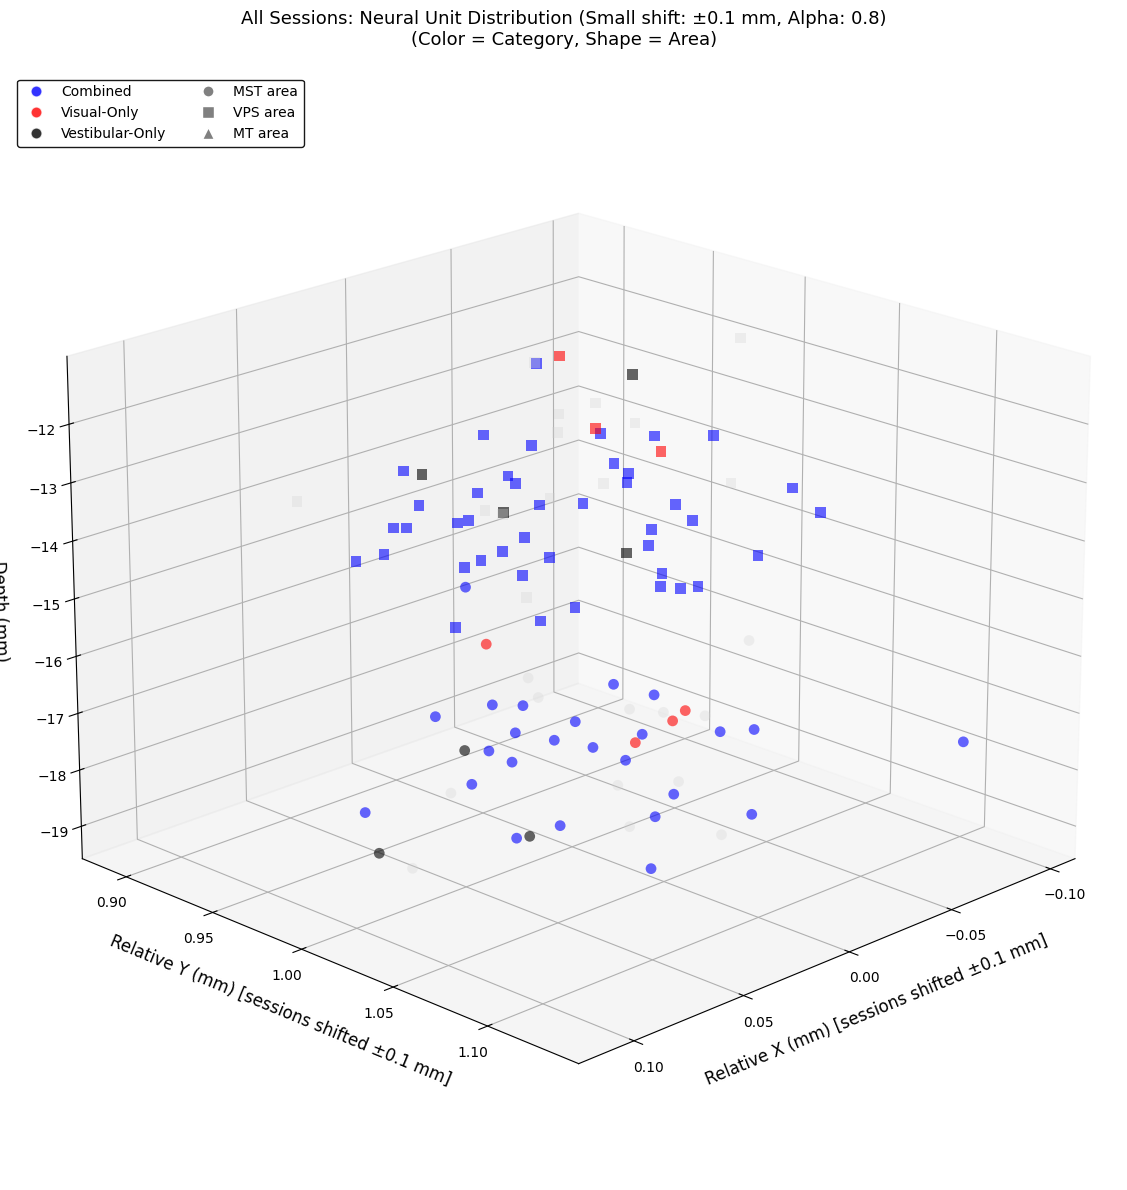

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ast

# Load data
df = pd.read_csv(r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv')

print(f"Loaded {len(df)} units from {len(df['date'].unique())} sessions")

# ===== PARSE ARRAYS =====
def safe_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return x if isinstance(x, list) else []

for modality in ['ves', 'vis', 'comb']:
    df[f'anova_{modality}_p'] = df[f'anova_{modality}_p'].apply(safe_eval)

# ===== DETERMINE SELECTIVITY =====
def is_selective(row, modality, alpha=0.05):
    try:
        p_values = row[f'anova_{modality}_p']
        if not isinstance(p_values, list) or len(p_values) == 0:
            return False
        return any(not np.isnan(p) and p < alpha for p in p_values)
    except:
        return False

df['ves_selective'] = df.apply(lambda row: is_selective(row, 'ves'), axis=1)
df['vis_selective'] = df.apply(lambda row: is_selective(row, 'vis'), axis=1)
df['comb_selective'] = df.apply(lambda row: is_selective(row, 'comb'), axis=1)

def categorize_simple(row):
    if  (row['vis_selective'] and row['ves_selective']) or row['comb_selective']:
        return 'Combined'
    elif row['vis_selective']:
        return 'Visual-Only'
    elif row['ves_selective']:
        return 'Vestibular-Only'
    else:
        return 'Non-responsive'

df['category'] = df.apply(categorize_simple, axis=1)

# ===== MAIN PLOTTING FUNCTION =====
def plot_neural_distribution(df, selected_dates=[]):
    """
    Plot neural unit distribution in 3D space
    
    Parameters:
    -----------
    df : DataFrame
        The neural data
    selected_dates : list
        List of date strings to plot (e.g., ["20250411", "20250306"])
        Leave empty [] to plot all sessions
    """
    
    # ===== SMALL SESSION-SPECIFIC SHIFTS =====
    sessions = sorted(df['date'].unique())
    print(sessions)
    # Filter sessions if specific dates are provided
    if selected_dates:
        sessions = [s for s in sessions if s in selected_dates]
        print(f"\nFiltering to {len(sessions)} selected session(s): {sessions}")
    
    n_sessions = len(sessions)
    
    # CHANGED: Very small shift - just to separate overlapping sessions
    shift_amount = 0.1  # mm (was 1.5)
    
    # Group sessions by their original position and apply small offsets
    session_shifts = {}
    
    for i, session in enumerate(sessions):
        # Get the original position for this session
        session_data = df[df['date'] == session]
        orig_x = session_data['relative_x'].iloc[0]
        orig_y = session_data['relative_y'].iloc[0]
        
        # Apply small alternating shifts: (0.2, 0), (0, 0.2), (-0.2, 0), (0, -0.2), etc.
        shift_patterns = [
            (0, 0),           # No shift
            (shift_amount, 0),     # Right
            (0, shift_amount),     # Up
            (-shift_amount, 0),    # Left
            (0, -shift_amount),    # Down
            (shift_amount, shift_amount),    # Diagonal
            (-shift_amount, shift_amount),   # Diagonal
            (shift_amount, -shift_amount)    # Diagonal
        ]
        
        shift_x, shift_y = shift_patterns[i % len(shift_patterns)]
        session_shifts[session] = (shift_x, shift_y)
    
    print(f"\n{'='*70}")
    print(f"SESSION SMALL SHIFTS (Shift amount: ±{shift_amount} mm)")
    print(f"{'='*70}")
    for session, (shift_x, shift_y) in session_shifts.items():
        n_units = len(df[df['date'] == session])
        session_data = df[df['date'] == session]
        orig_pos = (session_data['relative_x'].iloc[0], session_data['relative_y'].iloc[0])
        print(f"Session {session}: Original ({orig_pos[0]:>5.2f}, {orig_pos[1]:>5.2f}) → Shift ({shift_x:>6.2f}, {shift_y:>6.2f}) mm ({n_units} units)")
    
    # ===== ADD JITTER WITH SMALL SESSION SHIFTS =====
    np.random.seed(42)
    jitter_amount = 0.05
    
    df['jitter_x'] = df['relative_x'] + np.random.normal(0, jitter_amount, len(df))
    df['jitter_y'] = df['relative_y'] + np.random.normal(0, jitter_amount, len(df))
    df['jitter_z'] = -(df['relative_depth'] + np.random.normal(0, jitter_amount, len(df)))
    
    # CHANGED: Apply small session-specific shift
    for session, (shift_x, shift_y) in session_shifts.items():
        mask = df['date'] == session
        df.loc[mask, 'jitter_x'] += shift_x
        df.loc[mask, 'jitter_y'] += shift_y
    
    # ===== TRANSPARENCY =====
    df['alpha'] = 0.6
    df.loc[df['category'] == 'Non-responsive', 'alpha'] = 0.3
    
    print(f"\nAlpha: Responsive = 0.8, Non-responsive = 0.3")
    
    # ===== PLOT =====
    colors = {
        'Combined': 'blue',
        'Visual-Only': 'red',
        'Vestibular-Only': 'black',
        'Non-responsive': 'lightgray'
    }
    
    markers = {
        'MST': 'o',
        'VPS': 's',
        'MT': '^',
        'unknown': 'x'
    }
    
    marker_size = 60
    
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111, projection='3d')
    
    plot_order = ['Non-responsive', 'Vestibular-Only', 'Visual-Only', 'Combined']
    
    for session in sessions:
        session_mask = df['date'] == session
        
        for cat in plot_order:
            for area in df['area'].unique():
                idx = session_mask & (df['category'] == cat) & (df['area'] == area)
                data = df[idx]
                
                if len(data) == 0:
                    continue
                
                alphas = data['alpha'].values
                marker = markers.get(area, 'o')
                
                for i, (x, y, z, alpha_val) in enumerate(zip(data['jitter_x'], data['jitter_y'], 
                                                               data['jitter_z'], alphas)):
                    ax.scatter(x, y, z,
                               c=colors[cat], 
                               marker=marker,
                               s=marker_size,
                               alpha=alpha_val,
                               edgecolors='none', 
                               linewidth=0,
                               label=f'{session}-{cat}-{area}' if i == 0 else '')
    
    # Styling
    ax.set_xlabel(f'Relative X (mm) [sessions shifted ±{shift_amount} mm]', fontsize=12, labelpad=10)
    ax.set_ylabel(f'Relative Y (mm) [sessions shifted ±{shift_amount} mm]', fontsize=12, labelpad=10)
    ax.set_zlabel('Depth (mm)', fontsize=12, labelpad=10)
    ax.set_title(f'All Sessions: Neural Unit Distribution (Small shift: ±{shift_amount} mm, Alpha: 0.8)\n(Color = Category, Shape = Area)', 
                 fontsize=13, pad=20)
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = []
    
    for cat, color in colors.items():
        if cat != 'Non-responsive':
            legend_elements.append(Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=color, markersize=8, 
                                         label=cat, alpha=0.8))
    
    for area, marker in markers.items():
        if area in df['area'].unique():
            legend_elements.append(Line2D([0], [0], marker=marker, color='w', 
                                         markerfacecolor='gray', markersize=8, 
                                         label=f'{area} area'))
    
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10, 
             framealpha=0.9, edgecolor='black', ncol=2)
    
    ax.grid(True, alpha=0.2, linestyle='--')
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    plt.show()



# ============================================================================
# ===== RUN THE PLOT - CHANGE DATES HERE =====
# ============================================================================

# To plot specific dates, add them to the list:
plot_neural_distribution(df, selected_dates=[20250411])

# To plot ALL sessions, use an empty list:
# plot_neural_distribution(df, selected_dates=[])

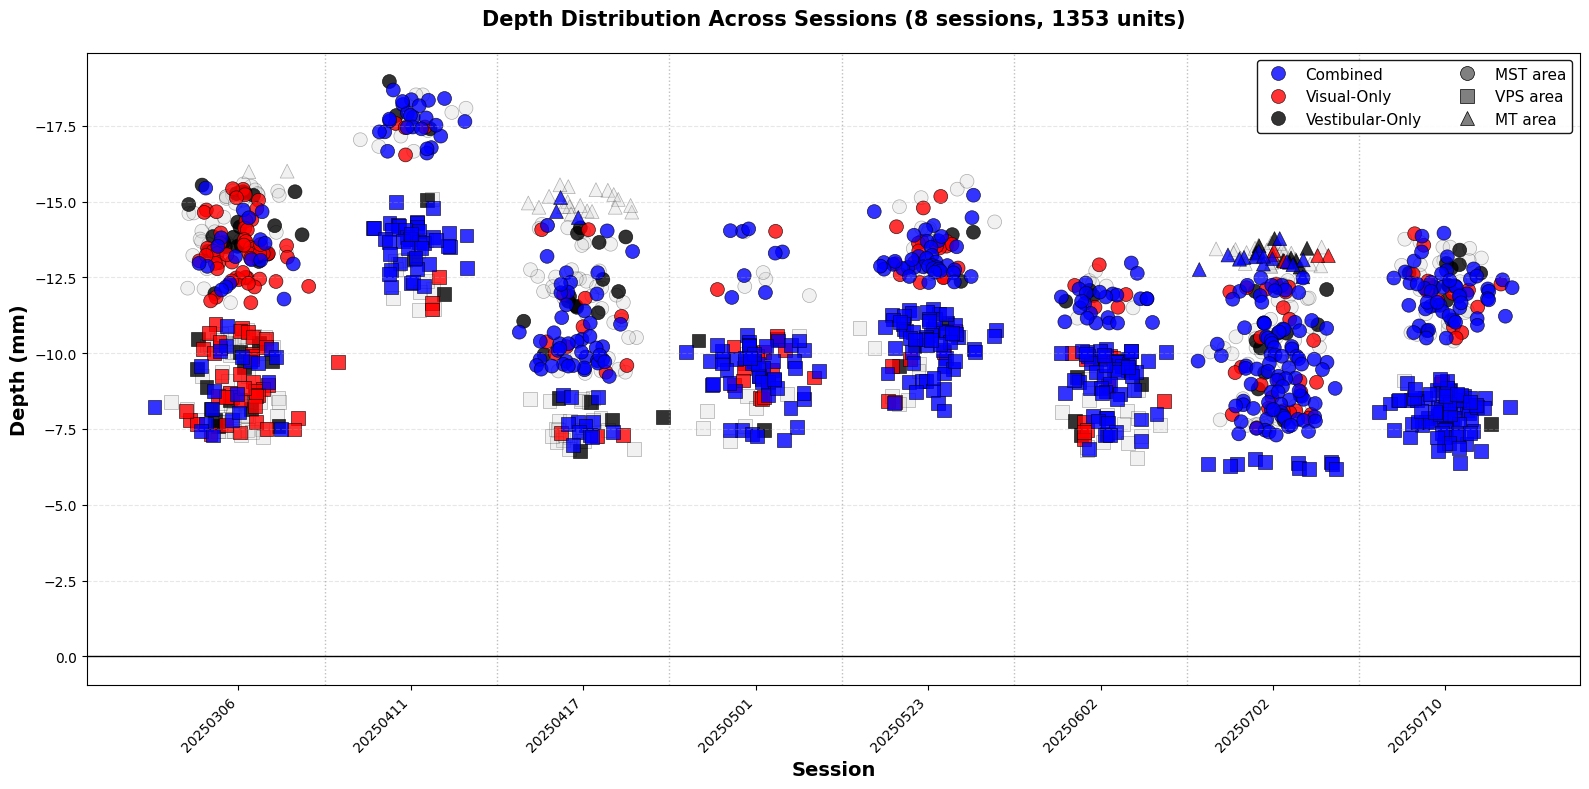


DEPTH STATISTICS BY SESSION

Session 20250306 (Position 1): 275 units
  Depth range: 7.23 to 16.01 mm
  Mean depth: 11.56 ± 2.60 mm
    Combined          :  38 units, depth 11.03 ± 2.44 mm
    Visual-Only       :  94 units, depth 11.53 ± 2.37 mm
    Vestibular-Only   :  36 units, depth 12.22 ± 2.64 mm
    Non-responsive    : 107 units, depth 11.55 ± 2.77 mm

Session 20250411 (Position 2): 106 units
  Depth range: 11.42 to 18.96 mm
  Mean depth: 15.11 ± 2.26 mm
    Combined          :  67 units, depth 15.11 ± 2.06 mm
    Visual-Only       :   7 units, depth 14.95 ± 2.70 mm
    Vestibular-Only   :   7 units, depth 15.44 ± 2.47 mm
    Non-responsive    :  25 units, depth 15.05 ± 2.57 mm

Session 20250417 (Position 3): 176 units
  Depth range: 6.77 to 15.55 mm
  Mean depth: 10.89 ± 2.51 mm
    Combined          :  61 units, depth 10.36 ± 1.94 mm
    Visual-Only       :  14 units, depth 10.39 ± 2.12 mm
    Vestibular-Only   :  18 units, depth 11.02 ± 2.24 mm
    Non-responsive    :  83 uni

In [3]:
# ============================================================================
# ===== 2D DEPTH DISTRIBUTION - SESSIONS SIDE BY SIDE =====
# ============================================================================

def plot_depth_by_session(df, selected_dates=[]):
    """
    Plot depth distribution with each session at a different X position
    
    Parameters:
    -----------
    df : DataFrame
        The neural data
    selected_dates : list
        List of date strings to plot (e.g., ["20250411", "20250306"])
        Leave empty [] to plot all sessions
    """
    
    # Filter sessions if specific dates are provided
    sessions = sorted(df['date'].unique())
    if selected_dates:
        sessions = [s for s in sessions if s in selected_dates]
        print(f"\nPlotting {len(sessions)} selected session(s): {sessions}")
    
    # Filter data to selected sessions
    if selected_dates:
        plot_df = df[df['date'].isin(sessions)].copy()
    else:
        plot_df = df.copy()
    
    # Colors and markers
    colors = {
        'Combined': 'blue',
        'Visual-Only': 'red',
        'Vestibular-Only': 'black',
        'Non-responsive': 'lightgray'
    }
    
    markers = {
        'MST': 'o',
        'VPS': 's',
        'MT': '^',
        'unknown': 'x'
    }
    
    marker_size = 100
    
    # Set transparency
    plot_df['alpha'] = 0.8
    plot_df.loc[plot_df['category'] == 'Non-responsive', 'alpha'] = 0.3
    
    # Create figure
    fig, ax = plt.subplots(figsize=(max(12, len(sessions) * 2), 8))
    
    plot_order = ['Non-responsive', 'Vestibular-Only', 'Visual-Only', 'Combined']
    
    # Assign each session a position on X axis
    session_positions = {session: i + 1 for i, session in enumerate(sessions)}
    
    # Add small jitter to avoid overlapping points
    np.random.seed(42)
    jitter_amount = 0.15
    
    # Plot each session
    for session in sessions:
        x_pos = session_positions[session]
        session_data = plot_df[plot_df['date'] == session]
        
        for cat in plot_order:
            for area in session_data['area'].unique():
                data = session_data[(session_data['category'] == cat) & (session_data['area'] == area)]
                if len(data) == 0:
                    continue
                
                marker = markers.get(area, 'o')
                alphas = data['alpha'].values
                
                # Add small jitter to X position
                x_positions = np.ones(len(data)) * x_pos + np.random.normal(0, jitter_amount, len(data))
                depths = -data['relative_depth'].values  # Negative for plotting (depth increases downward)
                
                ax.scatter(x_positions, depths,
                          c=colors[cat], marker=marker, s=marker_size,
                          alpha=alphas, edgecolors='black', linewidth=0.5,
                          label=f'{cat}-{area}' if session == sessions[0] else '')
    
    # Styling
    ax.set_xlabel('Session', fontsize=14, fontweight='bold')
    ax.set_ylabel('Depth (mm)', fontsize=14, fontweight='bold')
    ax.set_title(f'Depth Distribution Across Sessions ({len(sessions)} sessions, {len(plot_df)} units)', 
                 fontsize=15, fontweight='bold', pad=20)
    
    # Set X ticks to session names
    ax.set_xticks(list(session_positions.values()))
    ax.set_xticklabels(list(session_positions.keys()), rotation=45, ha='right')
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=1)
    
    # Add vertical lines to separate sessions
    for i in range(1, len(sessions)):
        ax.axvline(x=i + 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    
    # Invert Y axis so depth increases downward
    ax.invert_yaxis()
    
    # Create legend
    from matplotlib.lines import Line2D
    legend_elements = []
    
    # Category colors
    for cat, color in colors.items():
        if cat != 'Non-responsive':
            legend_elements.append(Line2D([0], [0], marker='o', color='w', 
                                         markerfacecolor=color, markersize=10, 
                                         label=cat, alpha=0.8, 
                                         markeredgecolor='black', markeredgewidth=0.5))
    
    # Area markers
    for area, marker in markers.items():
        if area in plot_df['area'].unique():
            legend_elements.append(Line2D([0], [0], marker=marker, color='w', 
                                         markerfacecolor='gray', markersize=10, 
                                         label=f'{area} area',
                                         markeredgecolor='black', markeredgewidth=0.5))
    
    ax.legend(handles=legend_elements, loc='best', fontsize=11, 
             framealpha=0.9, edgecolor='black', ncol=2)
    
    plt.tight_layout()
    plt.show()
    
    # Print depth statistics by session
    print(f"\n{'='*70}")
    print("DEPTH STATISTICS BY SESSION")
    print(f"{'='*70}")
    
    for session in sessions:
        session_data = plot_df[plot_df['date'] == session]
        if len(session_data) == 0:
            continue
        
        depths = session_data['relative_depth'].values
        print(f"\nSession {session} (Position {session_positions[session]}): {len(session_data)} units")
        print(f"  Depth range: {depths.min():.2f} to {depths.max():.2f} mm")
        print(f"  Mean depth: {depths.mean():.2f} ± {depths.std():.2f} mm")
        
        for cat in ['Combined', 'Visual-Only', 'Vestibular-Only', 'Non-responsive']:
            cat_data = session_data[session_data['category'] == cat]
            if len(cat_data) > 0:
                cat_depths = cat_data['relative_depth'].values
                print(f"    {cat:<18}: {len(cat_data):>3} units, depth {cat_depths.mean():.2f} ± {cat_depths.std():.2f} mm")


# ============================================================================
# ===== RUN THE DEPTH PLOT - CHANGE DATES HERE =====
# ============================================================================

# Plot specific dates:
# plot_depth_by_session(df, selected_dates=["20250411", "20250306"])

# Or plot all sessions:
plot_depth_by_session(df, selected_dates=[])

### Neurometric quality check


ANALYZING TUNING DATA BY BRAIN AREA - ALL UNITS
File: D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv

Preparing data (extracting best thresholds from lists)...

After preparation:
  Available threshold columns: ['vis_neurometric_threshold', 'ves_neurometric_threshold', 'comb_neurometric_threshold']
  Available R² columns: ['vis_neurometric_r2', 'ves_neurometric_r2', 'comb_neurometric_r2']

Brain areas found: ['MST' 'VPS' 'MT']

Quality Check:
  VIS: 1343/1353 units with valid thresholds (99.3%)
  VES: 1341/1353 units with valid thresholds (99.1%)
  COMB: 1342/1353 units with valid thresholds (99.2%)

----------------------------------------
AREA: MST
----------------------------------------
Total units in MST: 706


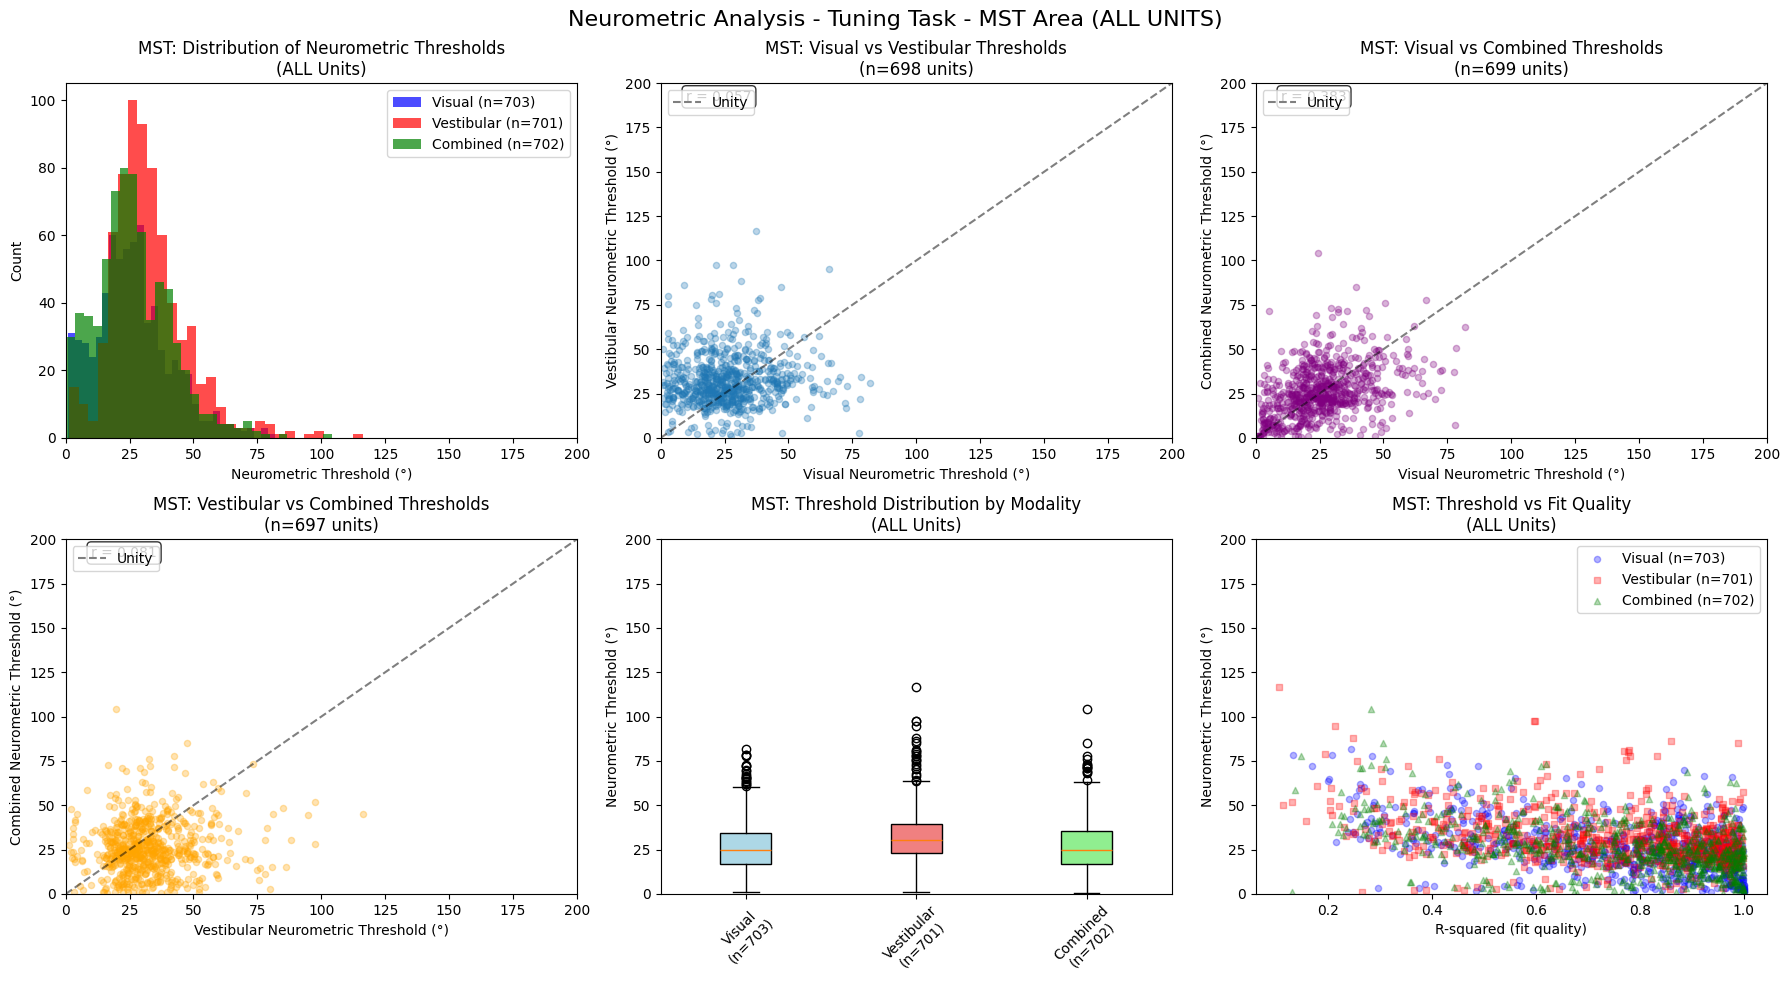


Summary Statistics for MST (Tuning Task - ALL UNITS):

Visual: 703 units with valid thresholds
  Mean: 26.47°
  Median: 25.06°
  Range: 0.89° - 81.93°
  Mean R²: 0.757

Vestibular: 701 units with valid thresholds
  Mean: 32.62°
  Median: 30.25°
  Range: 1.19° - 116.43°
  Mean R²: 0.720

Combined: 702 units with valid thresholds
  Mean: 26.47°
  Median: 24.76°
  Range: 0.35° - 104.07°
  Mean R²: 0.745

----------------------------------------
AREA: VPS
----------------------------------------
Total units in VPS: 568


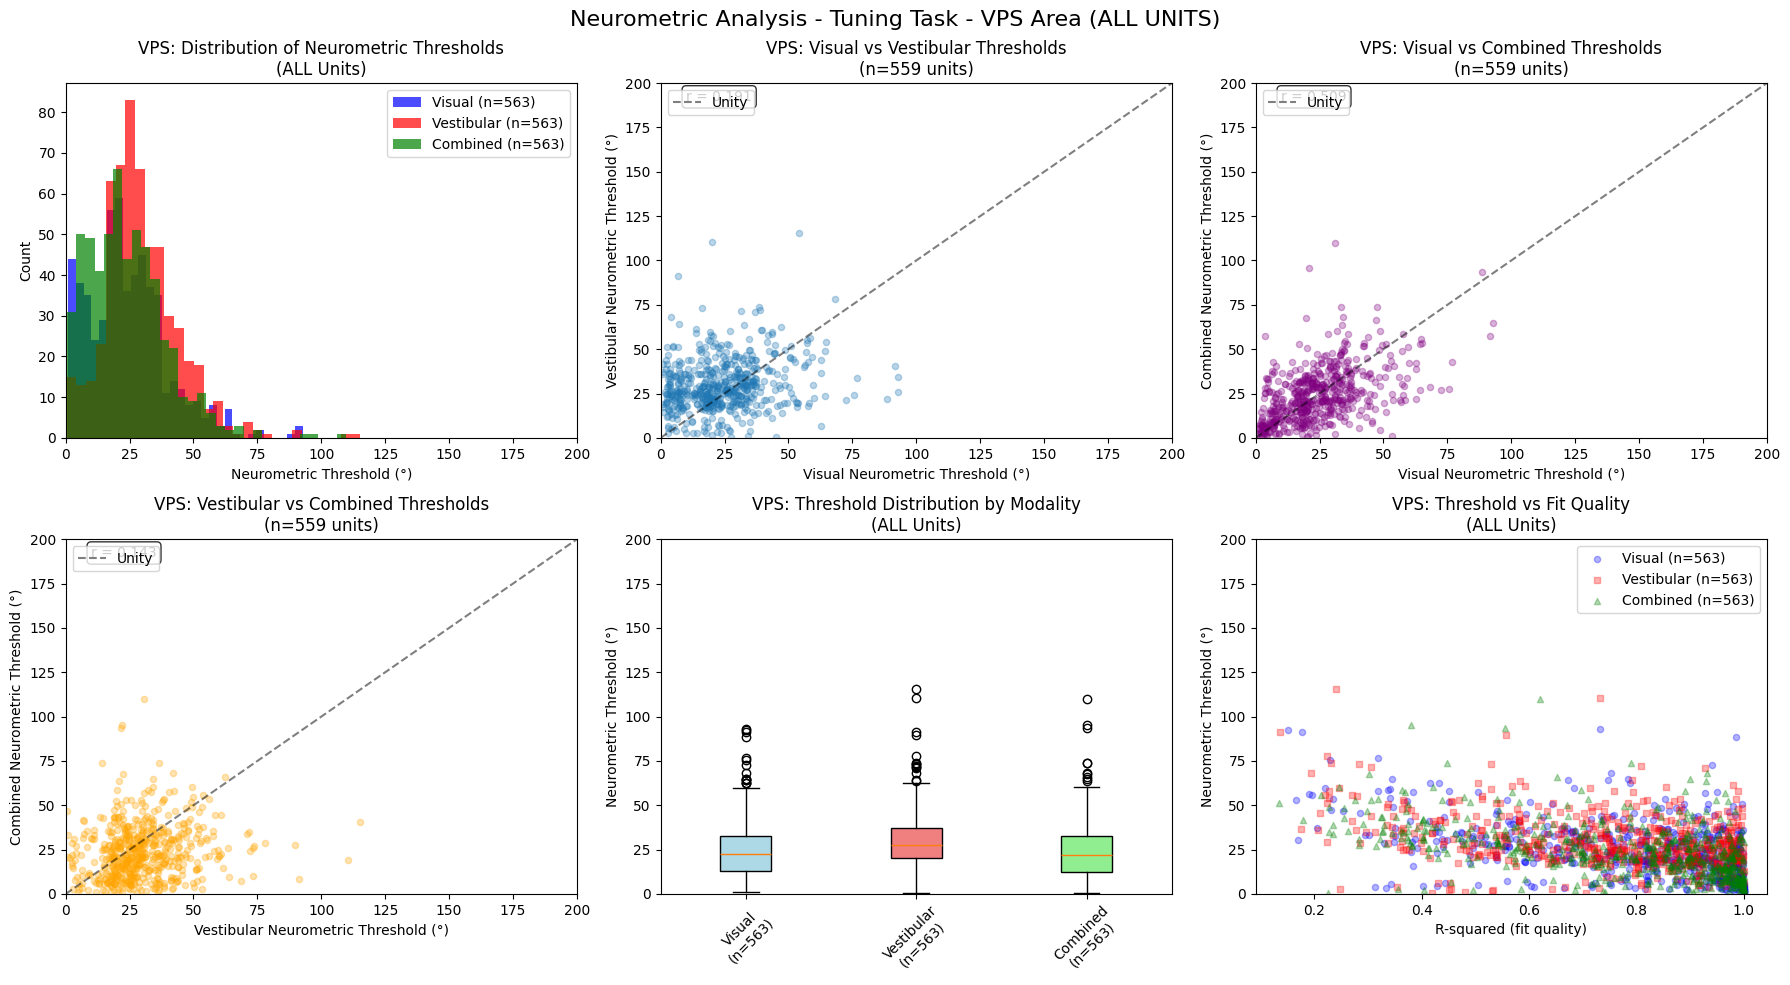


Summary Statistics for VPS (Tuning Task - ALL UNITS):

Visual: 563 units with valid thresholds
  Mean: 24.43°
  Median: 22.29°
  Range: 0.90° - 92.86°
  Mean R²: 0.793

Vestibular: 563 units with valid thresholds
  Mean: 29.93°
  Median: 27.50°
  Range: 0.35° - 115.31°
  Mean R²: 0.738

Combined: 563 units with valid thresholds
  Mean: 24.08°
  Median: 21.78°
  Range: 0.35° - 109.72°
  Mean R²: 0.772

----------------------------------------
AREA: MT
----------------------------------------
Total units in MT: 79


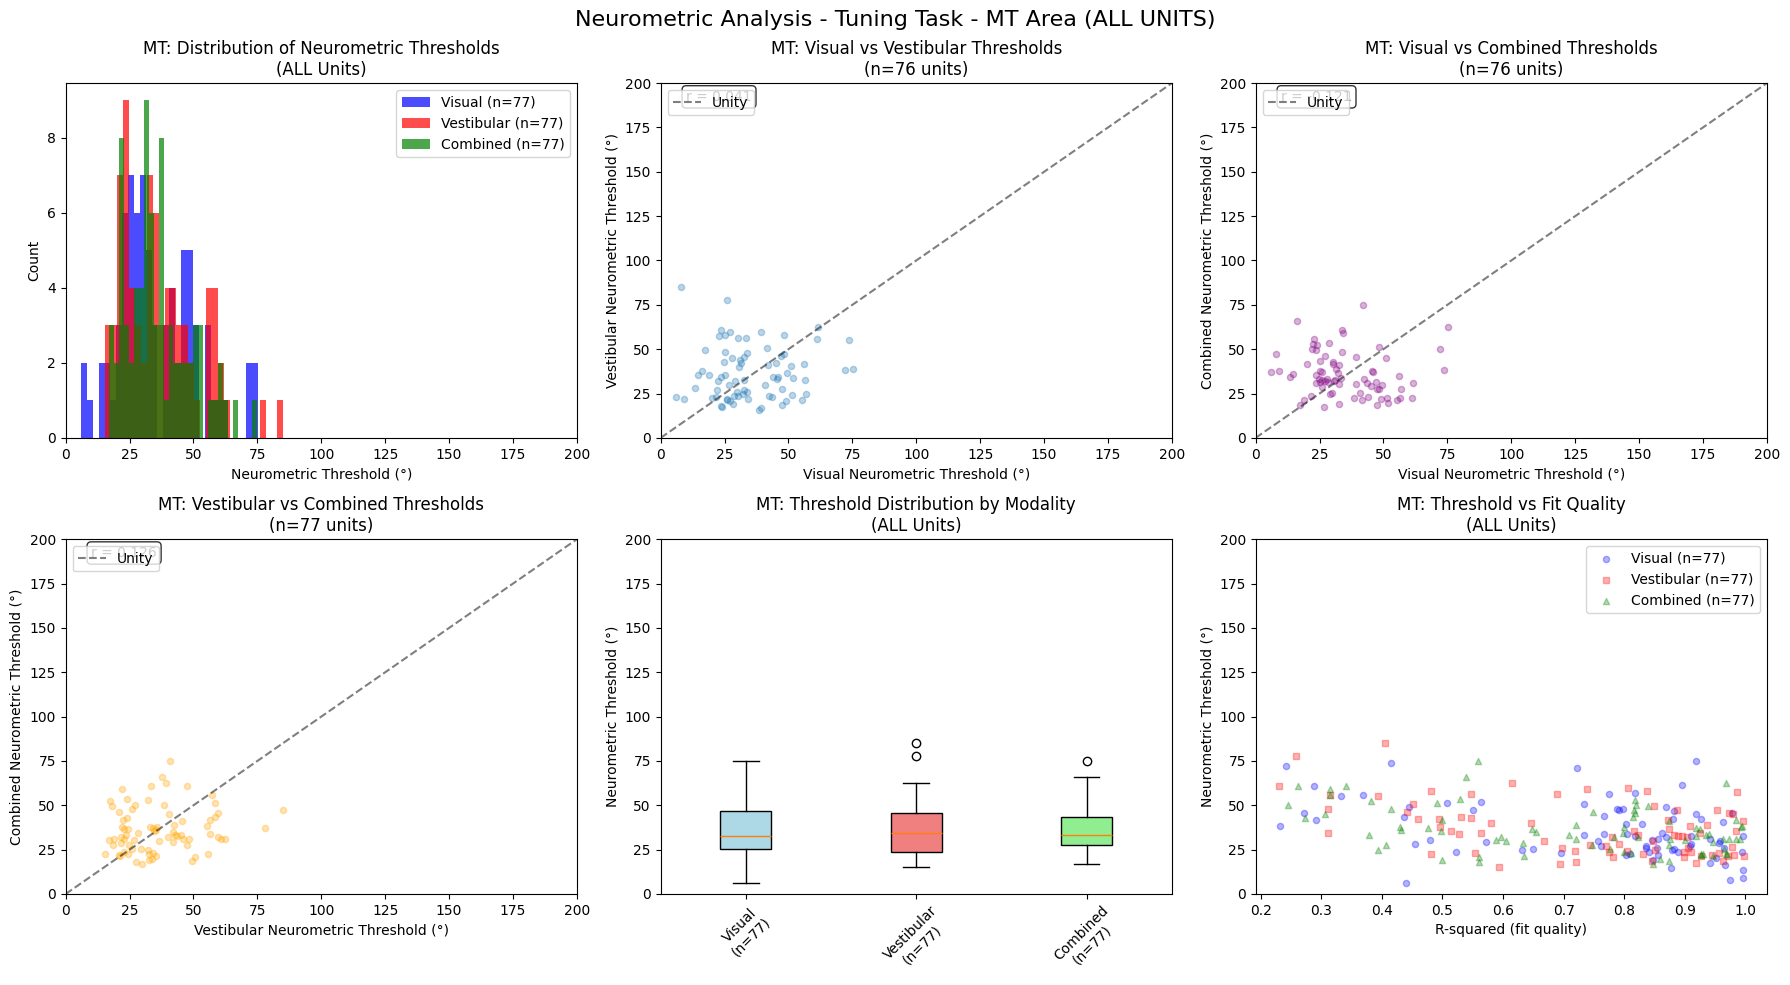


Summary Statistics for MT (Tuning Task - ALL UNITS):

Visual: 77 units with valid thresholds
  Mean: 35.95°
  Median: 32.53°
  Range: 5.94° - 75.11°
  Mean R²: 0.755

Vestibular: 77 units with valid thresholds
  Mean: 36.64°
  Median: 34.13°
  Range: 15.43° - 85.19°
  Mean R²: 0.737

Combined: 77 units with valid thresholds
  Mean: 36.25°
  Median: 33.33°
  Range: 17.13° - 74.95°
  Mean R²: 0.712

ANALYZING REGULAR DATA BY BRAIN AREA - ALL UNITS
File: D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv

Preparing data (extracting best thresholds from lists)...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



After preparation:
  Available threshold columns: ['vis_neurometric_threshold', 'ves_neurometric_threshold', 'comb_neurometric_threshold']
  Available R² columns: ['vis_neurometric_r2', 'ves_neurometric_r2', 'comb_neurometric_r2']

Brain areas found: ['MST' 'VPS' 'MT']

Quality Check:
  VIS: 0/1353 units with valid thresholds (0.0%)
  VES: 0/1353 units with valid thresholds (0.0%)
  COMB: 0/1353 units with valid thresholds (0.0%)

----------------------------------------
AREA: MST
----------------------------------------
Total units in MST: 706


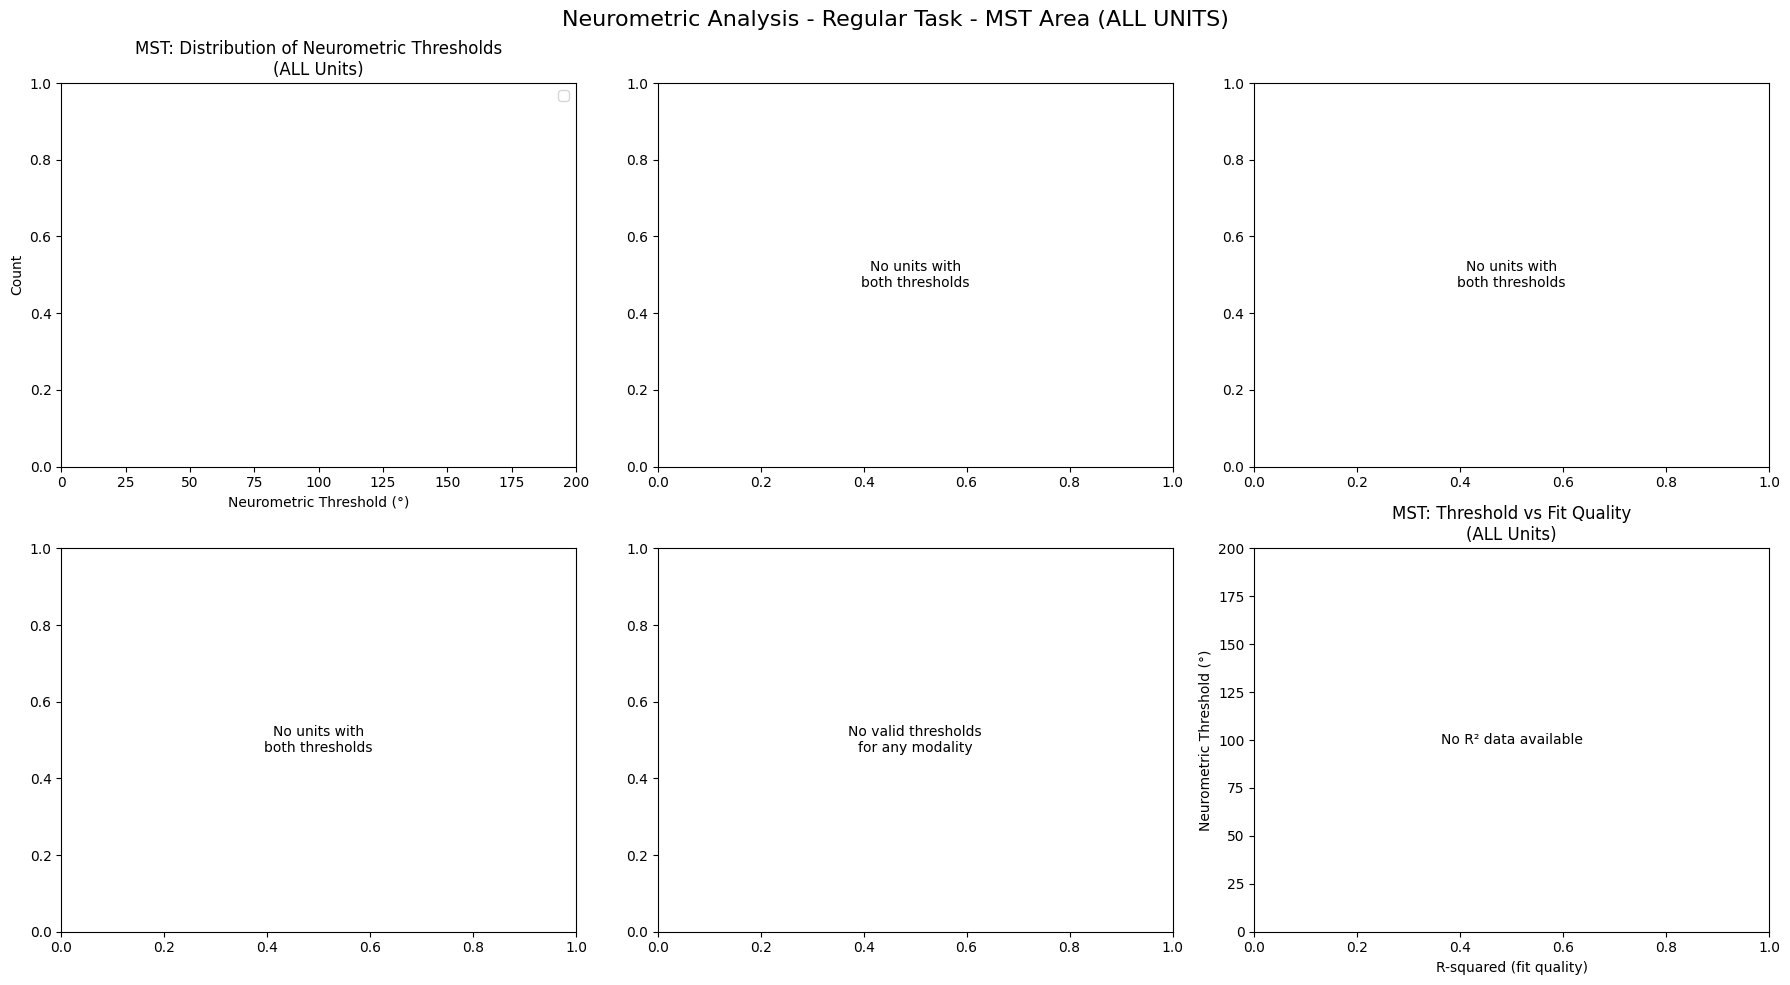

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Summary Statistics for MST (Regular Task - ALL UNITS):

Visual: 0 units with valid thresholds

Vestibular: 0 units with valid thresholds

Combined: 0 units with valid thresholds

----------------------------------------
AREA: VPS
----------------------------------------
Total units in VPS: 568


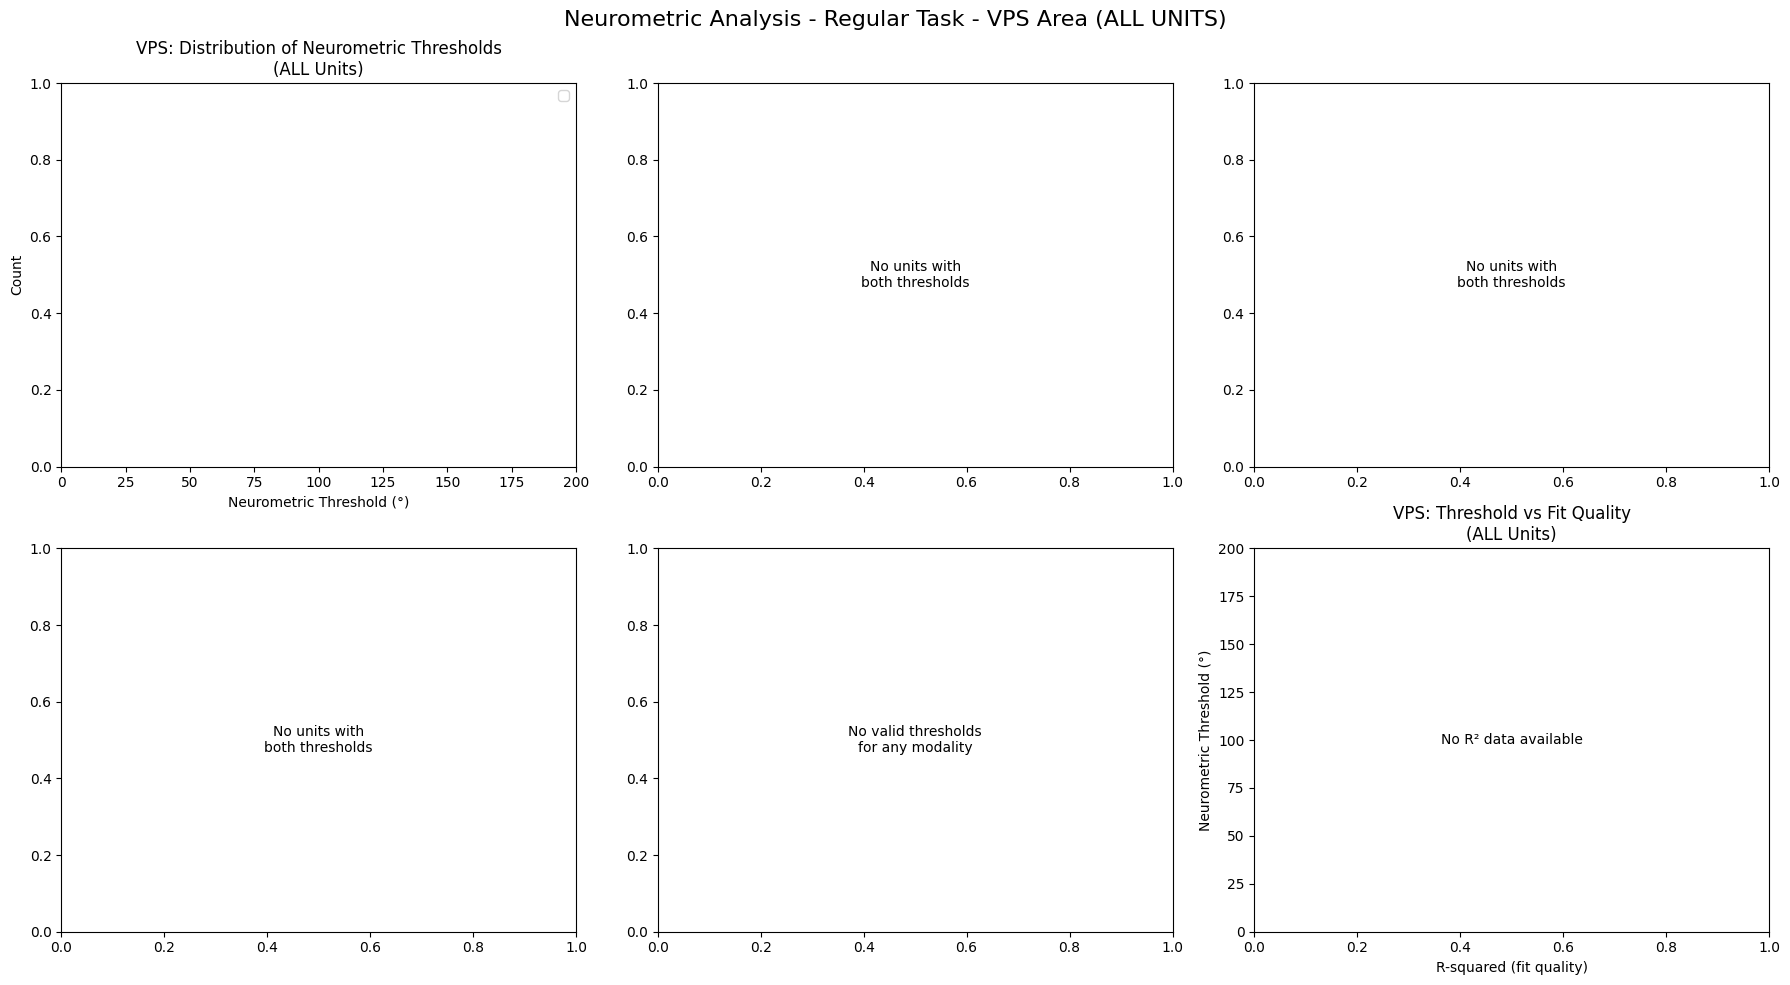

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Summary Statistics for VPS (Regular Task - ALL UNITS):

Visual: 0 units with valid thresholds

Vestibular: 0 units with valid thresholds

Combined: 0 units with valid thresholds

----------------------------------------
AREA: MT
----------------------------------------
Total units in MT: 79


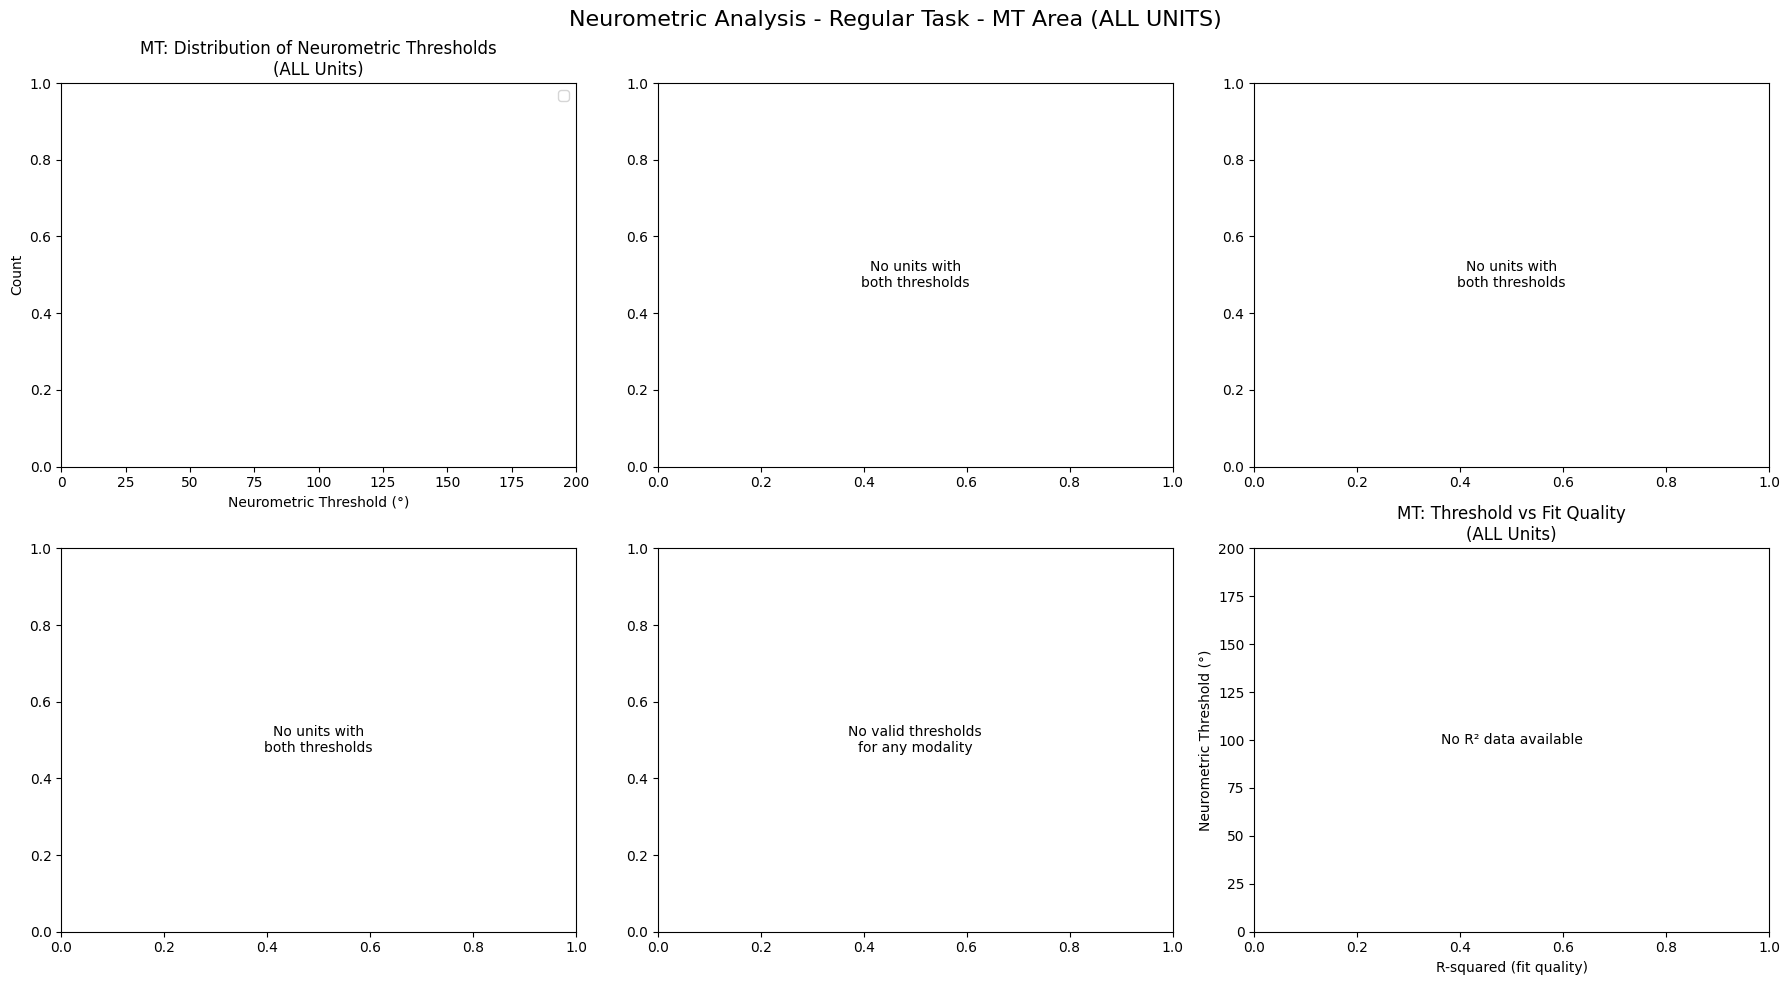


Summary Statistics for MT (Regular Task - ALL UNITS):

Visual: 0 units with valid thresholds

Vestibular: 0 units with valid thresholds

Combined: 0 units with valid thresholds


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast

def parse_list_column(value):
    """
    Parse list-like strings or actual lists into numpy arrays
    Handles both string representations and actual lists
    """
    if pd.isna(value):
        return np.array([])
    
    if isinstance(value, str):
        try:
            # Try to parse as literal list
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return np.array([x for x in parsed if not (isinstance(x, float) and np.isnan(x))])
            else:
                return np.array([parsed]) if not np.isnan(parsed) else np.array([])
        except:
            return np.array([])
    elif isinstance(value, (list, np.ndarray)):
        return np.array([x for x in value if not (isinstance(x, float) and np.isnan(x))])
    elif isinstance(value, (int, float)):
        return np.array([value]) if not np.isnan(value) else np.array([])
    else:
        return np.array([])

def extract_best_threshold(row, modality, threshold_col, r2_col, best_center_col):
    """
    Extract the best threshold for a modality based on best_center_ms
    Works with new format that stores lists
    """
    # Get best center time
    best_center = row.get(best_center_col, None)
    if pd.isna(best_center):
        return np.nan, np.nan
    
    # Get threshold and r2 lists
    thresholds = parse_list_column(row.get(threshold_col, []))
    r2s = parse_list_column(row.get(r2_col, []))
    centers = parse_list_column(row.get(f'neurometric_{modality}_centers', []))
    
    if len(thresholds) == 0 or len(centers) == 0:
        return np.nan, np.nan
    
    # Find index of best center
    try:
        best_idx = np.where(np.abs(centers - best_center) < 1)[0]
        if len(best_idx) > 0:
            best_idx = best_idx[0]
            threshold = thresholds[best_idx] if best_idx < len(thresholds) else np.nan
            r2 = r2s[best_idx] if best_idx < len(r2s) else np.nan
            return threshold, r2
    except:
        pass
    
    # Fallback: use first valid value
    threshold = thresholds[0] if len(thresholds) > 0 else np.nan
    r2 = r2s[0] if len(r2s) > 0 else np.nan
    return threshold, r2

def prepare_dataframe_for_analysis(df, task_type="tuning"):
    """
    Prepare dataframe by extracting best thresholds from list format
    Creates columns compatible with the old format
    """
    df_prepared = df.copy()
    
    # Define modalities to process
    modalities = ['ves', 'vis', 'comb']
    
    for modality in modalities:
        threshold_col = f'neurometric_{modality}_thresholds'
        r2_col = f'neurometric_{modality}_r2'
        best_center_col = f'neurometric_{modality}_best_center_ms'
        
        # Check if columns exist
        if threshold_col not in df.columns:
            continue
        
        # Extract best thresholds and r2 values
        best_thresholds = []
        best_r2s = []
        
        for idx, row in df.iterrows():
            threshold, r2 = extract_best_threshold(row, modality, threshold_col, r2_col, best_center_col)
            best_thresholds.append(threshold)
            best_r2s.append(r2)
        
        # Add as new columns (compatible with old format)
        df_prepared[f'{modality}_neurometric_threshold'] = best_thresholds
        df_prepared[f'{modality}_neurometric_r2'] = best_r2s
    
    # Handle selective columns (these might be in different formats)
    for modality in modalities:
        # Check for ANOVA p-values
        pval_col = f'anova_{modality}_p'
        if pval_col in df.columns:
            # Parse if it's a list
            pvals = []
            for val in df[pval_col]:
                parsed = parse_list_column(val)
                pval = parsed[0] if len(parsed) > 0 else np.nan
                pvals.append(pval)
            df_prepared[f'{modality}_pval'] = pvals
            df_prepared[f'{modality}_selective'] = (np.array(pvals) < 0.05).astype(int)
        elif f'{modality}_pval' in df.columns:
            # Already in correct format
            df_prepared[f'{modality}_selective'] = (df[f'{modality}_pval'] < 0.05).astype(int)
    
    return df_prepared

def analyze_neurometric_data_by_area_all_units(file_path, task_type="tuning"):
    """
    Analyze neurometric data for ALL units (not just selective ones)
    
    Parameters:
    -----------
    file_path : str
        Path to the CSV file
    task_type : str
        "tuning" or "regular" to adjust analysis accordingly
    """
    
    # Load the data
    df_raw = pd.read_csv(file_path)
    
    print(f"\n{'='*60}")
    print(f"ANALYZING {task_type.upper()} DATA BY BRAIN AREA - ALL UNITS")
    print(f"{'='*60}")
    print(f"File: {file_path}")
    
    # Prepare dataframe (extract best values from lists)
    print("\nPreparing data (extracting best thresholds from lists)...")
    df = prepare_dataframe_for_analysis(df_raw, task_type)
    
    # Define expected column names
    threshold_cols = {
        'vis': 'vis_neurometric_threshold',
        'ves': 'ves_neurometric_threshold', 
        'comb': 'comb_neurometric_threshold'
    }
    
    r2_cols = {
        'vis': 'vis_neurometric_r2',
        'ves': 'ves_neurometric_r2',
        'comb': 'comb_neurometric_r2'
    }
    
    # Check which columns actually exist after preparation
    available_threshold_cols = {k: v for k, v in threshold_cols.items() if v in df.columns}
    available_r2_cols = {k: v for k, v in r2_cols.items() if v in df.columns}
    
    print(f"\nAfter preparation:")
    print(f"  Available threshold columns: {list(available_threshold_cols.values())}")
    print(f"  Available R² columns: {list(available_r2_cols.values())}")
    
    # Get unique areas
    areas = df['area'].unique()
    print(f"\nBrain areas found: {areas}")
    
    # Quality check: count valid thresholds
    print(f"\nQuality Check:")
    for modality in ['vis', 'ves', 'comb']:
        if modality in available_threshold_cols:
            valid_count = df[available_threshold_cols[modality]].notna().sum()
            total_count = len(df)
            print(f"  {modality.upper()}: {valid_count}/{total_count} units with valid thresholds ({valid_count/total_count*100:.1f}%)")
    
    # Create separate analysis for each area
    for area in areas:
        print(f"\n{'-'*40}")
        print(f"AREA: {area}")
        print(f"{'-'*40}")
        
        # Filter data for this area - USE ALL UNITS
        area_df = df[df['area'] == area].copy()

        print(f"Total units in {area}: {len(area_df)}")

        if len(area_df) == 0:
            print(f"No units found in {area}, skipping...")
            continue

        # Create figure with subplots for this area
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f'Neurometric Analysis - {task_type.title()} Task - {area} Area (ALL UNITS)', fontsize=16, y=0.98)

        # 1. Distribution of thresholds (ALL UNITS)
        if 'vis' in available_threshold_cols:
            vis_thresh_data = area_df[available_threshold_cols['vis']].dropna()
            if len(vis_thresh_data) > 0:
                axes[0,0].hist(vis_thresh_data, bins=30, alpha=0.7, 
                               label=f'Visual (n={len(vis_thresh_data)})', color='blue')
        
        if 'ves' in available_threshold_cols:
            ves_thresh_data = area_df[available_threshold_cols['ves']].dropna()
            if len(ves_thresh_data) > 0:
                axes[0,0].hist(ves_thresh_data, bins=30, alpha=0.7, 
                               label=f'Vestibular (n={len(ves_thresh_data)})', color='red')
        
        if 'comb' in available_threshold_cols:
            comb_thresh_data = area_df[available_threshold_cols['comb']].dropna()
            if len(comb_thresh_data) > 0:
                axes[0,0].hist(comb_thresh_data, bins=30, alpha=0.7, 
                               label=f'Combined (n={len(comb_thresh_data)})', color='green')
        
        axes[0,0].set_xlabel('Neurometric Threshold (°)')
        axes[0,0].set_ylabel('Count')
        axes[0,0].set_title(f'{area}: Distribution of Neurometric Thresholds\n(ALL Units)')
        axes[0,0].legend()
        axes[0,0].set_xlim(0, 200)  # Set reasonable x-axis limit

        # 2. Visual vs Vestibular thresholds (ALL UNITS)
        if 'vis' in available_threshold_cols and 'ves' in available_threshold_cols:
            valid_both = area_df.dropna(subset=[available_threshold_cols['vis'], available_threshold_cols['ves']])

            if len(valid_both) > 0:
                axes[0,1].scatter(valid_both[available_threshold_cols['vis']], 
                                 valid_both[available_threshold_cols['ves']], 
                                 alpha=0.3, s=20)
                max_val = 200  # Set reasonable limit
                axes[0,1].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Unity')
                axes[0,1].set_xlabel('Visual Neurometric Threshold (°)')
                axes[0,1].set_ylabel('Vestibular Neurometric Threshold (°)')
                axes[0,1].set_title(f'{area}: Visual vs Vestibular Thresholds\n(n={len(valid_both)} units)')
                axes[0,1].set_xlim(0, max_val)
                axes[0,1].set_ylim(0, max_val)
                axes[0,1].legend()
                
                # Add correlation info
                if len(valid_both) > 2:
                    corr = np.corrcoef(valid_both[available_threshold_cols['vis']], 
                                      valid_both[available_threshold_cols['ves']])[0,1]
                    axes[0,1].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[0,1].transAxes, 
                                  bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            else:
                axes[0,1].text(0.5, 0.5, 'No units with\nboth thresholds', 
                               ha='center', va='center', transform=axes[0,1].transAxes)
        else:
            axes[0,1].text(0.5, 0.5, 'Required columns\nnot available', 
                           ha='center', va='center', transform=axes[0,1].transAxes)

        # 3. Combined vs Visual thresholds (ALL UNITS)
        if 'vis' in available_threshold_cols and 'comb' in available_threshold_cols:
            valid_vis_comb = area_df.dropna(subset=[available_threshold_cols['vis'], available_threshold_cols['comb']])

            if len(valid_vis_comb) > 0:
                axes[0,2].scatter(valid_vis_comb[available_threshold_cols['vis']], 
                                 valid_vis_comb[available_threshold_cols['comb']], 
                                 alpha=0.3, s=20, color='purple')
                max_val = 200
                axes[0,2].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Unity')
                axes[0,2].set_xlabel('Visual Neurometric Threshold (°)')
                axes[0,2].set_ylabel('Combined Neurometric Threshold (°)')
                axes[0,2].set_title(f'{area}: Visual vs Combined Thresholds\n(n={len(valid_vis_comb)} units)')
                axes[0,2].set_xlim(0, max_val)
                axes[0,2].set_ylim(0, max_val)
                axes[0,2].legend()
                
                if len(valid_vis_comb) > 2:
                    corr = np.corrcoef(valid_vis_comb[available_threshold_cols['vis']], 
                                      valid_vis_comb[available_threshold_cols['comb']])[0,1]
                    axes[0,2].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[0,2].transAxes,
                                  bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            else:
                axes[0,2].text(0.5, 0.5, 'No units with\nboth thresholds', 
                               ha='center', va='center', transform=axes[0,2].transAxes)
        else:
            axes[0,2].text(0.5, 0.5, 'Required columns\nnot available', 
                           ha='center', va='center', transform=axes[0,2].transAxes)

        # 4. Combined vs Vestibular thresholds (ALL UNITS)
        if 'ves' in available_threshold_cols and 'comb' in available_threshold_cols:
            valid_ves_comb = area_df.dropna(subset=[available_threshold_cols['ves'], available_threshold_cols['comb']])

            if len(valid_ves_comb) > 0:
                axes[1,0].scatter(valid_ves_comb[available_threshold_cols['ves']], 
                                 valid_ves_comb[available_threshold_cols['comb']], 
                                 alpha=0.3, s=20, color='orange')
                max_val = 200
                axes[1,0].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='Unity')
                axes[1,0].set_xlabel('Vestibular Neurometric Threshold (°)')
                axes[1,0].set_ylabel('Combined Neurometric Threshold (°)')
                axes[1,0].set_title(f'{area}: Vestibular vs Combined Thresholds\n(n={len(valid_ves_comb)} units)')
                axes[1,0].set_xlim(0, max_val)
                axes[1,0].set_ylim(0, max_val)
                axes[1,0].legend()
                
                if len(valid_ves_comb) > 2:
                    corr = np.corrcoef(valid_ves_comb[available_threshold_cols['ves']], 
                                      valid_ves_comb[available_threshold_cols['comb']])[0,1]
                    axes[1,0].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[1,0].transAxes,
                                  bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            else:
                axes[1,0].text(0.5, 0.5, 'No units with\nboth thresholds', 
                               ha='center', va='center', transform=axes[1,0].transAxes)
        else:
            axes[1,0].text(0.5, 0.5, 'Required columns\nnot available', 
                           ha='center', va='center', transform=axes[1,0].transAxes)

        # 5. Box plot comparison of thresholds by modality (ALL UNITS)
        threshold_data = []
        threshold_labels = []
        
        if 'vis' in available_threshold_cols:
            vis_thresh_clean = area_df[available_threshold_cols['vis']].dropna()
            if len(vis_thresh_clean) > 0:
                threshold_data.append(vis_thresh_clean.values)
                threshold_labels.append(f'Visual\n(n={len(vis_thresh_clean)})')
        
        if 'ves' in available_threshold_cols:
            ves_thresh_clean = area_df[available_threshold_cols['ves']].dropna()
            if len(ves_thresh_clean) > 0:
                threshold_data.append(ves_thresh_clean.values)
                threshold_labels.append(f'Vestibular\n(n={len(ves_thresh_clean)})')
        
        if 'comb' in available_threshold_cols:
            comb_thresh_clean = area_df[available_threshold_cols['comb']].dropna()
            if len(comb_thresh_clean) > 0:
                threshold_data.append(comb_thresh_clean.values)
                threshold_labels.append(f'Combined\n(n={len(comb_thresh_clean)})')
        
        if len(threshold_data) > 0:
            bp = axes[1,1].boxplot(threshold_data, labels=threshold_labels, patch_artist=True)
            colors = ['lightblue', 'lightcoral', 'lightgreen']
            for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
                patch.set_facecolor(color)
            axes[1,1].set_ylabel('Neurometric Threshold (°)')
            axes[1,1].set_title(f'{area}: Threshold Distribution by Modality\n(ALL Units)')
            axes[1,1].tick_params(axis='x', rotation=45)
            axes[1,1].set_ylim(0, 200)
        else:
            axes[1,1].text(0.5, 0.5, 'No valid thresholds\nfor any modality', 
                           ha='center', va='center', transform=axes[1,1].transAxes)

        # 6. R-squared values (fit quality) - ALL UNITS
        legend_added = False
        
        if 'vis' in available_r2_cols and 'vis' in available_threshold_cols:
            vis_r2_data = area_df[available_r2_cols['vis']].dropna()
            vis_thresh_data = area_df[available_threshold_cols['vis']].dropna()
            if len(vis_r2_data) > 0 and len(vis_thresh_data) > 0:
                common_idx = vis_r2_data.index.intersection(vis_thresh_data.index)
                if len(common_idx) > 0:
                    axes[1,2].scatter(vis_r2_data[common_idx], vis_thresh_data[common_idx], 
                                     alpha=0.3, label=f'Visual (n={len(common_idx)})', 
                                     color='blue', marker='o', s=20)
                    legend_added = True
        
        if 'ves' in available_r2_cols and 'ves' in available_threshold_cols:
            ves_r2_data = area_df[available_r2_cols['ves']].dropna()
            ves_thresh_data = area_df[available_threshold_cols['ves']].dropna()
            if len(ves_r2_data) > 0 and len(ves_thresh_data) > 0:
                common_idx = ves_r2_data.index.intersection(ves_thresh_data.index)
                if len(common_idx) > 0:
                    axes[1,2].scatter(ves_r2_data[common_idx], ves_thresh_data[common_idx], 
                                     alpha=0.3, label=f'Vestibular (n={len(common_idx)})', 
                                     color='red', marker='s', s=20)
                    legend_added = True
        
        if 'comb' in available_r2_cols and 'comb' in available_threshold_cols:
            comb_r2_data = area_df[available_r2_cols['comb']].dropna()
            comb_thresh_data = area_df[available_threshold_cols['comb']].dropna()
            if len(comb_r2_data) > 0 and len(comb_thresh_data) > 0:
                common_idx = comb_r2_data.index.intersection(comb_thresh_data.index)
                if len(common_idx) > 0:
                    axes[1,2].scatter(comb_r2_data[common_idx], comb_thresh_data[common_idx], 
                                     alpha=0.3, label=f'Combined (n={len(common_idx)})', 
                                     color='green', marker='^', s=20)
                    legend_added = True
        
        axes[1,2].set_xlabel('R-squared (fit quality)')
        axes[1,2].set_ylabel('Neurometric Threshold (°)')
        axes[1,2].set_title(f'{area}: Threshold vs Fit Quality\n(ALL Units)')
        axes[1,2].set_ylim(0, 200)
        
        if legend_added:
            axes[1,2].legend()
        else:
            axes[1,2].text(0.5, 0.5, 'No R² data available', 
                           ha='center', va='center', transform=axes[1,2].transAxes)

        plt.tight_layout()
        plt.show()

        # Print summary statistics for ALL units
        print(f"\nSummary Statistics for {area} ({task_type.title()} Task - ALL UNITS):")

        if 'vis' in available_threshold_cols:
            vis_thresh_data = area_df[available_threshold_cols['vis']].dropna()
            print(f"\nVisual: {len(vis_thresh_data)} units with valid thresholds")
            if len(vis_thresh_data) > 0:
                print(f"  Mean: {vis_thresh_data.mean():.2f}°")
                print(f"  Median: {vis_thresh_data.median():.2f}°")
                print(f"  Range: {vis_thresh_data.min():.2f}° - {vis_thresh_data.max():.2f}°")
                if 'vis' in available_r2_cols:
                    vis_r2_data = area_df[available_r2_cols['vis']].dropna()
                    if len(vis_r2_data) > 0:
                        print(f"  Mean R²: {vis_r2_data.mean():.3f}")

        if 'ves' in available_threshold_cols:
            ves_thresh_data = area_df[available_threshold_cols['ves']].dropna()
            print(f"\nVestibular: {len(ves_thresh_data)} units with valid thresholds")
            if len(ves_thresh_data) > 0:
                print(f"  Mean: {ves_thresh_data.mean():.2f}°")
                print(f"  Median: {ves_thresh_data.median():.2f}°")
                print(f"  Range: {ves_thresh_data.min():.2f}° - {ves_thresh_data.max():.2f}°")
                if 'ves' in available_r2_cols:
                    ves_r2_data = area_df[available_r2_cols['ves']].dropna()
                    if len(ves_r2_data) > 0:
                        print(f"  Mean R²: {ves_r2_data.mean():.3f}")

        if 'comb' in available_threshold_cols:
            comb_thresh_data = area_df[available_threshold_cols['comb']].dropna()
            print(f"\nCombined: {len(comb_thresh_data)} units with valid thresholds")
            if len(comb_thresh_data) > 0:
                print(f"  Mean: {comb_thresh_data.mean():.2f}°")
                print(f"  Median: {comb_thresh_data.median():.2f}°")
                print(f"  Range: {comb_thresh_data.min():.2f}° - {comb_thresh_data.max():.2f}°")
                if 'comb' in available_r2_cols:
                    comb_r2_data = area_df[available_r2_cols['comb']].dropna()
                    if len(comb_r2_data) > 0:
                        print(f"  Mean R²: {comb_r2_data.mean():.3f}")
    
    return df

# Usage:
# Analyze tuning data by area - ALL UNITS
tuning_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv'
tuning_df = analyze_neurometric_data_by_area_all_units(tuning_file, "tuning")

# Analyze regular task data by area - ALL UNITS
regular_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv'
regular_df = analyze_neurometric_data_by_area_all_units(regular_file, "regular")

### Neurometric sanity check

In [54]:
import pandas as pd
import numpy as np
import ast

def parse_list_column(value):
    """Parse string representation of list to actual list"""
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    if value is None:
        return []
    try:
        if pd.isna(value):
            return []
    except (ValueError, TypeError):
        pass
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except:
            return []
    return []

def find_good_units(regular_file, r2_threshold=0.5, threshold_cutoff=30):
    """
    Find units that:
    1. Pass R² threshold for ALL THREE modalities (ves, vis, comb)
    2. Have at least ONE modality with threshold < threshold_cutoff
    
    Parameters:
    -----------
    regular_file : str
        Path to regular task CSV file
    r2_threshold : float
        Minimum R² value required (default: 0.5)
    threshold_cutoff : float
        Maximum threshold for at least one modality (default: 30°)
    
    Returns:
    --------
    DataFrame with qualifying units
    """
    
    print("="*80)
    print("FINDING GOOD UNITS IN PRE-SACCADE CONDITION")
    print("="*80)
    print(f"\nCriteria:")
    print(f"  1. R² ≥ {r2_threshold} for ALL THREE modalities (ves, vis, comb)")
    print(f"  2. At least ONE modality with threshold < {threshold_cutoff}°")
    print("="*80)
    
    # Load data
    df = pd.read_csv(regular_file)
    print(f"\nLoaded {len(df)} units from {regular_file}")
    
    # Create results storage
    good_units = []
    
    # Process each unit
    for idx, row in df.iterrows():
        subject = row['subject']
        date = row['date']
        unit_idx = row['unit_idx']
        area = row.get('area', 'unknown')
        
        # Extract thresholds and R² for each modality
        modality_data = {}
        all_r2_pass = True
        any_threshold_pass = False
        
        for modality in ['ves', 'vis', 'comb']:
            thresh_col = f'neurometric_{modality}_thresholds'
            r2_col = f'neurometric_{modality}_r2'
            
            # Parse lists
            thresh_list = parse_list_column(row.get(thresh_col, []))
            r2_list = parse_list_column(row.get(r2_col, []))
            
            # Get first value (pre-saccade has single value)
            if len(thresh_list) > 0 and len(r2_list) > 0:
                threshold = thresh_list[0]
                r2 = r2_list[0]
                
                # Check if valid
                if np.isnan(threshold) or np.isnan(r2):
                    all_r2_pass = False
                    modality_data[modality] = {'threshold': np.nan, 'r2': np.nan, 'r2_pass': False, 'thresh_pass': False}
                else:
                    r2_pass = r2 >= r2_threshold
                    thresh_pass = threshold < threshold_cutoff
                    
                    if not r2_pass:
                        all_r2_pass = False
                    if thresh_pass:
                        any_threshold_pass = True
                    
                    modality_data[modality] = {
                        'threshold': threshold, 
                        'r2': r2, 
                        'r2_pass': r2_pass, 
                        'thresh_pass': thresh_pass
                    }
            else:
                all_r2_pass = False
                modality_data[modality] = {'threshold': np.nan, 'r2': np.nan, 'r2_pass': False, 'thresh_pass': False}
        
        # Check if unit passes both criteria
        if all_r2_pass and any_threshold_pass:
            good_units.append({
                'subject': subject,
                'date': date,
                'unit_idx': unit_idx,
                'area': area,
                'ves_threshold': modality_data['ves']['threshold'],
                'ves_r2': modality_data['ves']['r2'],
                'vis_threshold': modality_data['vis']['threshold'],
                'vis_r2': modality_data['vis']['r2'],
                'comb_threshold': modality_data['comb']['threshold'],
                'comb_r2': modality_data['comb']['r2'],
                'min_threshold': min(modality_data['ves']['threshold'], 
                                    modality_data['vis']['threshold'], 
                                    modality_data['comb']['threshold']),
                'best_modality': min(['ves', 'vis', 'comb'], 
                                    key=lambda m: modality_data[m]['threshold'])
            })
    
    # Create DataFrame
    good_df = pd.DataFrame(good_units)
    
    # Print results
    print(f"\n{'='*80}")
    print("RESULTS")
    print(f"{'='*80}")
    print(f"\nTotal units passing criteria: {len(good_df)} / {len(df)} ({100*len(good_df)/len(df):.1f}%)")
    
    if len(good_df) > 0:
        # Summary by session
        print(f"\n{'-'*60}")
        print("SUMMARY BY SESSION")
        print(f"{'-'*60}")
        
        session_summary = good_df.groupby(['subject', 'date']).agg({
            'unit_idx': 'count',
            'min_threshold': 'min'
        }).rename(columns={'unit_idx': 'n_units', 'min_threshold': 'best_threshold'})
        
        for (subject, date), row in session_summary.iterrows():
            print(f"  {subject} {date}: {row['n_units']} units (best threshold: {row['best_threshold']:.1f}°)")
        
        # Summary by area
        print(f"\n{'-'*60}")
        print("SUMMARY BY AREA")
        print(f"{'-'*60}")
        
        area_summary = good_df.groupby('area').agg({
            'unit_idx': 'count',
            'min_threshold': ['mean', 'min']
        })
        area_summary.columns = ['n_units', 'mean_best_threshold', 'best_threshold']
        
        for area, row in area_summary.iterrows():
            print(f"  {area}: {row['n_units']} units (mean best: {row['mean_best_threshold']:.1f}°, best: {row['best_threshold']:.1f}°)")
        
        # Detailed list
        print(f"\n{'-'*60}")
        print("DETAILED UNIT LIST")
        print(f"{'-'*60}")
        print(f"{'Subject':<10} {'Date':<12} {'Unit':<6} {'Area':<8} {'Ves θ':<8} {'Vis θ':<8} {'Comb θ':<8} {'Best':<6}")
        print("-" * 80)
        
        # Sort by date and unit_idx
        good_df_sorted = good_df.sort_values(['date', 'unit_idx'])
        
        for _, row in good_df_sorted.iterrows():
            print(f"{row['subject']:<10} {row['date']:<12} {row['unit_idx']:<6} {row['area']:<8} "
                  f"{row['ves_threshold']:<8.1f} {row['vis_threshold']:<8.1f} {row['comb_threshold']:<8.1f} "
                  f"{row['best_modality']:<6}")
        
        # R² values
        print(f"\n{'-'*60}")
        print("R² VALUES FOR QUALIFYING UNITS")
        print(f"{'-'*60}")
        print(f"{'Subject':<10} {'Date':<12} {'Unit':<6} {'Ves R²':<8} {'Vis R²':<8} {'Comb R²':<8}")
        print("-" * 70)
        
        for _, row in good_df_sorted.iterrows():
            print(f"{row['subject']:<10} {row['date']:<12} {row['unit_idx']:<6} "
                  f"{row['ves_r2']:<8.3f} {row['vis_r2']:<8.3f} {row['comb_r2']:<8.3f}")
        
        # Statistics
        print(f"\n{'-'*60}")
        print("THRESHOLD STATISTICS (qualifying units only)")
        print(f"{'-'*60}")
        
        for modality in ['ves', 'vis', 'comb']:
            thresh_col = f'{modality}_threshold'
            thresholds = good_df[thresh_col]
            print(f"  {modality.upper():>4}: mean={thresholds.mean():.1f}°, "
                  f"median={thresholds.median():.1f}°, "
                  f"min={thresholds.min():.1f}°, "
                  f"max={thresholds.max():.1f}°")
        
        # Best modality distribution
        print(f"\n{'-'*60}")
        print("BEST MODALITY DISTRIBUTION")
        print(f"{'-'*60}")
        
        best_mod_counts = good_df['best_modality'].value_counts()
        for mod, count in best_mod_counts.items():
            print(f"  {mod.upper()}: {count} units ({100*count/len(good_df):.1f}%)")
    
    else:
        print("\n⚠ No units passed the criteria!")
    
    return good_df


def find_good_units_detailed_report(regular_file, r2_threshold=0.5, threshold_cutoff=30):
    """
    Same as find_good_units but also shows units that ALMOST passed
    """
    
    print("\n" + "="*80)
    print("DETAILED ANALYSIS: WHY UNITS FAILED")
    print("="*80)
    
    df = pd.read_csv(regular_file)
    
    # Categories
    all_r2_pass_all_thresh_high = []  # R² pass but all thresholds >= cutoff
    some_r2_fail = []  # At least one R² failed
    
    for idx, row in df.iterrows():
        subject = row['subject']
        date = row['date']
        unit_idx = row['unit_idx']
        area = row.get('area', 'unknown')
        
        modality_data = {}
        r2_results = {}
        thresh_results = {}
        
        for modality in ['ves', 'vis', 'comb']:
            thresh_col = f'neurometric_{modality}_thresholds'
            r2_col = f'neurometric_{modality}_r2'
            
            thresh_list = parse_list_column(row.get(thresh_col, []))
            r2_list = parse_list_column(row.get(r2_col, []))
            
            if len(thresh_list) > 0 and len(r2_list) > 0:
                threshold = thresh_list[0]
                r2 = r2_list[0]
                
                if not np.isnan(threshold) and not np.isnan(r2):
                    r2_results[modality] = r2 >= r2_threshold
                    thresh_results[modality] = threshold
                    modality_data[modality] = {'threshold': threshold, 'r2': r2}
                else:
                    r2_results[modality] = False
                    thresh_results[modality] = np.nan
                    modality_data[modality] = {'threshold': np.nan, 'r2': np.nan}
            else:
                r2_results[modality] = False
                thresh_results[modality] = np.nan
                modality_data[modality] = {'threshold': np.nan, 'r2': np.nan}
        
        # Check conditions
        all_r2_pass = all(r2_results.values())
        valid_thresholds = [t for t in thresh_results.values() if not np.isnan(t)]
        any_thresh_pass = any(t < threshold_cutoff for t in valid_thresholds) if valid_thresholds else False
        
        if all_r2_pass and not any_thresh_pass:
            # R² passed but thresholds too high
            all_r2_pass_all_thresh_high.append({
                'subject': subject,
                'date': date,
                'unit_idx': unit_idx,
                'area': area,
                **{f'{m}_threshold': modality_data[m]['threshold'] for m in ['ves', 'vis', 'comb']},
                **{f'{m}_r2': modality_data[m]['r2'] for m in ['ves', 'vis', 'comb']},
                'min_threshold': min(valid_thresholds) if valid_thresholds else np.nan
            })
        
        elif not all_r2_pass:
            # At least one R² failed
            failed_modalities = [m for m, passed in r2_results.items() if not passed]
            some_r2_fail.append({
                'subject': subject,
                'date': date,
                'unit_idx': unit_idx,
                'area': area,
                'failed_modalities': failed_modalities,
                **{f'{m}_threshold': modality_data[m]['threshold'] for m in ['ves', 'vis', 'comb']},
                **{f'{m}_r2': modality_data[m]['r2'] for m in ['ves', 'vis', 'comb']}
            })
    
    # Report
    print(f"\n{'-'*60}")
    print(f"UNITS WITH ALL R² ≥ {r2_threshold} BUT ALL THRESHOLDS ≥ {threshold_cutoff}°")
    print(f"{'-'*60}")
    print(f"Count: {len(all_r2_pass_all_thresh_high)}")
    
    if len(all_r2_pass_all_thresh_high) > 0:
        high_thresh_df = pd.DataFrame(all_r2_pass_all_thresh_high)
        high_thresh_df_sorted = high_thresh_df.sort_values('min_threshold')
        
        print(f"\n{'Subject':<10} {'Date':<12} {'Unit':<6} {'Area':<8} {'Min θ':<8} {'Ves θ':<8} {'Vis θ':<8} {'Comb θ':<8}")
        print("-" * 85)
        
        for _, row in high_thresh_df_sorted.head(20).iterrows():  # Show top 20
            print(f"{row['subject']:<10} {row['date']:<12} {row['unit_idx']:<6} {row['area']:<8} "
                  f"{row['min_threshold']:<8.1f} {row['ves_threshold']:<8.1f} "
                  f"{row['vis_threshold']:<8.1f} {row['comb_threshold']:<8.1f}")
        
        if len(high_thresh_df) > 20:
            print(f"... and {len(high_thresh_df) - 20} more units")
    
    print(f"\n{'-'*60}")
    print(f"UNITS WITH AT LEAST ONE R² < {r2_threshold}")
    print(f"{'-'*60}")
    print(f"Count: {len(some_r2_fail)}")
    
    # Summary of failed modalities
    if len(some_r2_fail) > 0:
        fail_df = pd.DataFrame(some_r2_fail)
        
        # Count which modalities fail most often
        modality_fail_counts = {'ves': 0, 'vis': 0, 'comb': 0}
        for failed_list in fail_df['failed_modalities']:
            for m in failed_list:
                modality_fail_counts[m] += 1
        
        print(f"\nModality failure counts:")
        for m, count in modality_fail_counts.items():
            print(f"  {m.upper()}: {count} units failed R² criterion")
    
    return pd.DataFrame(all_r2_pass_all_thresh_high), pd.DataFrame(some_r2_fail)


# ============================================================================
# USAGE
# ============================================================================

# File path
regular_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv'

# Find good units
good_units_df = find_good_units(regular_file, r2_threshold=0.5, threshold_cutoff=30)

# Optional: Detailed analysis of why units failed
high_thresh_df, r2_fail_df = find_good_units_detailed_report(regular_file, r2_threshold=0.5, threshold_cutoff=30)

# Save results
if len(good_units_df) > 0:
    output_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\good_units_presaccade.csv'
    good_units_df.to_csv(output_file, index=False)
    print(f"\n✅ Good units saved to: {output_file}")

FINDING GOOD UNITS IN PRE-SACCADE CONDITION

Criteria:
  1. R² ≥ 0.5 for ALL THREE modalities (ves, vis, comb)
  2. At least ONE modality with threshold < 30°

Loaded 1353 units from D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv

RESULTS

Total units passing criteria: 306 / 1353 (22.6%)

------------------------------------------------------------
SUMMARY BY SESSION
------------------------------------------------------------
  zarya 20250306: 73.0 units (best threshold: 1.2°)
  zarya 20250411: 23.0 units (best threshold: 4.3°)
  zarya 20250417: 35.0 units (best threshold: 8.7°)
  zarya 20250523: 40.0 units (best threshold: 7.1°)
  zarya 20250602: 24.0 units (best threshold: 3.4°)
  zarya 20250702: 48.0 units (best threshold: 3.2°)
  zarya 20250710: 63.0 units (best threshold: 3.5°)

------------------------------------------------------------
SUMMARY BY AREA
------------------------------------------------

### Neurometric tuning vs dots3DMP

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu
import ast

def parse_list_column(value):
    """Parse string representation of list to actual list"""
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    if value is None:
        return []
    try:
        if pd.isna(value):
            return []
    except (ValueError, TypeError):
        pass
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except:
            return []
    return []

def is_selective(row, modality, alpha=0.05):
    """Check if unit is selective for given modality (from tuning task)"""
    try:
        p_values = parse_list_column(row[f'anova_{modality}_p'])
        if len(p_values) == 0:
            return False
        return any(not np.isnan(p) and p < alpha for p in p_values)
    except:
        return False

def classify_multisensory_units_from_tuning(tuning_df):
    """Classify multisensory units from TUNING task ANOVA results"""
    
    # Parse ANOVA p-value columns
    for modality in ['vis', 'ves', 'comb']:
        col = f'anova_{modality}_p'
        if col in tuning_df.columns:
            tuning_df[col] = tuning_df[col].apply(parse_list_column)
    
    # Apply selectivity criteria
    tuning_df['vis_selective'] = tuning_df.apply(lambda row: is_selective(row, 'vis', alpha=0.05), axis=1)
    tuning_df['ves_selective'] = tuning_df.apply(lambda row: is_selective(row, 'ves', alpha=0.05), axis=1)
    tuning_df['comb_selective'] = tuning_df.apply(lambda row: is_selective(row, 'comb', alpha=0.05), axis=1)
    
    # Initialize classification
    multisensory_mask = []
    
    for idx, row in tuning_df.iterrows():
        vis_sel = row['vis_selective']
        ves_sel = row['ves_selective']
        comb_sel = row['comb_selective']
        
        # Multisensory = (vis AND ves) OR comb
        is_multisensory = (vis_sel and ves_sel) or comb_sel
        multisensory_mask.append(is_multisensory)
    
    return np.array(multisensory_mask)

def extract_neurometric_threshold_single(row, modality):
    """Extract neurometric threshold (single value format)"""
    try:
        thresh_col = f'neurometric_{modality}_thresholds'
        r2_col = f'neurometric_{modality}_r2'
        
        if thresh_col not in row.index or r2_col not in row.index:
            return np.nan, np.nan
        
        thresh_list = parse_list_column(row[thresh_col])
        r2_list = parse_list_column(row[r2_col])
        
        if len(thresh_list) == 0 or len(r2_list) == 0:
            return np.nan, np.nan
        
        threshold = thresh_list[0] if not np.isnan(thresh_list[0]) else np.nan
        r2 = r2_list[0] if not np.isnan(r2_list[0]) else np.nan
        
        return threshold, r2
        
    except Exception as e:
        return np.nan, np.nan

def extract_best_neurometric_threshold(row, modality):
    """Extract BEST neurometric threshold from tuning task (sliding windows)"""
    try:
        thresh_col = f'neurometric_{modality}_thresholds'
        r2_col = f'neurometric_{modality}_r2'
        centers_col = f'neurometric_{modality}_centers'
        best_center_col = f'neurometric_{modality}_best_center_ms'
        
        if (thresh_col not in row.index or r2_col not in row.index or 
            centers_col not in row.index or best_center_col not in row.index):
            return np.nan, np.nan
        
        thresh_list = parse_list_column(row[thresh_col])
        r2_list = parse_list_column(row[r2_col])
        centers_list = parse_list_column(row[centers_col])
        best_center = row[best_center_col]
        
        if (len(thresh_list) == 0 or len(r2_list) == 0 or 
            len(centers_list) == 0 or pd.isna(best_center)):
            return np.nan, np.nan
        
        centers_array = np.array(centers_list)
        best_idx = np.argmin(np.abs(centers_array - best_center))
        
        threshold = thresh_list[best_idx] if best_idx < len(thresh_list) else np.nan
        r2 = r2_list[best_idx] if best_idx < len(r2_list) else np.nan
        
        return threshold, r2
        
    except Exception as e:
        return np.nan, np.nan

def get_significance_marker(p_val):
    """Get significance marker for p-value"""
    if p_val < 0.001:
        return "***"
    elif p_val < 0.01:
        return "**"
    elif p_val < 0.05:
        return "*"
    elif p_val < 0.1:
        return "†"
    else:
        return ""

def count_valid_units(df, modality, r2_threshold, extract_func, multisensory_keys):
    """Count how many units pass the R² threshold"""
    n_valid = 0
    n_total = 0
    
    for idx, row in df.iterrows():
        unit_key = row['unit_key']
        if unit_key not in multisensory_keys:
            continue
        
        n_total += 1
        thresh, r2 = extract_func(row, modality)
        
        if (not np.isnan(thresh) and not np.isnan(r2) and 
            r2 >= r2_threshold and thresh > 0.1 and thresh < 1000):
            n_valid += 1
    
    return n_valid, n_total

def extract_all_valid_data(df, modality, r2_threshold, extract_func, multisensory_keys):
    """Extract ALL valid units (not just paired)"""
    valid_thresholds = []
    valid_keys = []
    
    for idx, row in df.iterrows():
        unit_key = row['unit_key']
        if unit_key not in multisensory_keys:
            continue
        
        thresh, r2 = extract_func(row, modality)
        
        if (not np.isnan(thresh) and not np.isnan(r2) and 
            r2 >= r2_threshold and thresh > 0.1 and thresh < 1000):
            valid_thresholds.append(thresh)
            valid_keys.append(unit_key)
    
    return np.array(valid_thresholds), valid_keys

def extract_paired_data(df1, df2, modality, r2_threshold, extraction_func1, extraction_func2):
    """Extract paired data ensuring SAME UNITS appear in both arrays"""
    # Extract from first dataset
    data1_thresholds = []
    data1_r2s = []
    data1_keys = []
    
    for idx, row in df1.iterrows():
        thresh, r2 = extraction_func1(row, modality)
        if not np.isnan(thresh) and not np.isnan(r2):
            data1_thresholds.append(thresh)
            data1_r2s.append(r2)
            data1_keys.append(row['unit_key'])
    
    # Extract from second dataset
    data2_thresholds = []
    data2_r2s = []
    data2_keys = []
    
    for idx, row in df2.iterrows():
        thresh, r2 = extraction_func2(row, modality)
        if not np.isnan(thresh) and not np.isnan(r2):
            data2_thresholds.append(thresh)
            data2_r2s.append(r2)
            data2_keys.append(row['unit_key'])
    
    # Find common units
    common_keys = set(data1_keys).intersection(set(data2_keys))
    
    if len(common_keys) == 0:
        return np.array([]), np.array([]), []
    
    # Get paired data in the SAME ORDER
    paired_data1 = []
    paired_data2 = []
    paired_keys = []
    
    for key in common_keys:
        try:
            idx1 = data1_keys.index(key)
            idx2 = data2_keys.index(key)
            
            thresh1 = data1_thresholds[idx1]
            r2_1 = data1_r2s[idx1]
            thresh2 = data2_thresholds[idx2]
            r2_2 = data2_r2s[idx2]
            
            # Apply R2 and range filters
            if (thresh1 > 0.1 and thresh1 < 1000 and
                thresh2 > 0.1 and thresh2 < 1000 and
                r2_1 >= r2_threshold and r2_2 >= r2_threshold):
                
                paired_data1.append(thresh1)
                paired_data2.append(thresh2)
                paired_keys.append(key)
        except:
            continue
    
    return np.array(paired_data1), np.array(paired_data2), paired_keys

def plot_prevalence_bar_chart(area, modalities, prevalence_data, filename):
    """Bar chart showing % of units passing R² threshold in each condition"""
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    conditions = ['best_tuning', 'tuning_rt', 'regular_rt', 'prechoice']
    condition_labels = ['Best\nTuning', 'Tuning RT\n(cap at mean)', 'Regular RT\n(cap at mean)', 'Pre-choice\n(pre-saccade)']
    condition_colors = ['#1f77b4', '#9467bd', '#ff7f0e', '#2ca02c']
    
    for ax_idx, (modality, color, mod_label, marker) in enumerate(modalities):
        ax = axes[ax_idx]
        
        if mod_label not in prevalence_data:
            continue
        
        n_valid_list = []
        n_total_list = []
        percent_list = []
        
        for cond in conditions:
            if cond in prevalence_data[mod_label]:
                n_valid = prevalence_data[mod_label][cond]['n_valid']
                n_total = prevalence_data[mod_label][cond]['n_total']
                percent = (n_valid / n_total * 100) if n_total > 0 else 0
                
                n_valid_list.append(n_valid)
                n_total_list.append(n_total)
                percent_list.append(percent)
            else:
                n_valid_list.append(0)
                n_total_list.append(0)
                percent_list.append(0)
        
        x_pos = np.arange(len(conditions))
        bars = ax.bar(x_pos, percent_list, color=condition_colors, alpha=0.7, 
                     edgecolor='black', linewidth=2)
        
        for i, (bar, n_valid, n_total) in enumerate(zip(bars, n_valid_list, n_total_list)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                   f'{n_valid}/{n_total}',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        ax.set_ylabel('% Units Passing R² ≥ 0.5', fontsize=12, fontweight='bold')
        ax.set_xlabel('Condition', fontsize=12, fontweight='bold')
        ax.set_title(f'{mod_label} Modality', fontsize=14, fontweight='bold', color=color)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(condition_labels, fontsize=11)
        ax.set_ylim(0, 110)
        ax.axhline(100, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.grid(True, alpha=0.3, axis='y')
        
        for i, (x, pct) in enumerate(zip(x_pos, percent_list)):
            ax.text(x, pct/2, f'{pct:.1f}%', ha='center', va='center', 
                   fontsize=11, fontweight='bold', color='white')
    
    plt.suptitle(f'{area}: Prevalence of Well-Tuned Units (R² ≥ 0.5)\n4 Methods Comparison', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\nPrevalence bar chart saved: {filename}")
    plt.close()

def plot_scatter_histogram(paired_data1, paired_data2, label1, label2, 
                           area, modalities, stats_info, filename):
    """
    FIGURE 1 & 2: Scatter plot with marginal histograms (paired units only)
    """
    
    # Collect all data for axis limits
    all_data1 = np.concatenate([paired_data1[k] for k in paired_data1.keys()])
    all_data2 = np.concatenate([paired_data2[k] for k in paired_data2.keys()])
    
    # CREATE FIGURE
    fig = plt.figure(figsize=(14, 10))
    
    # Layout
    main_ax = plt.axes([0.12, 0.12, 0.55, 0.55])
    top_ax = plt.axes([0.12, 0.69, 0.55, 0.10])
    right_ax = plt.axes([0.69, 0.12, 0.10, 0.55])
    
    # Calculate axis limits
    min_thresh = min(np.min(all_data1), np.min(all_data2)) * 0.8
    max_thresh = max(np.max(all_data1), np.max(all_data2)) * 1.2
    
    # MAIN SCATTER PLOT
    for modality, color, mod_label, marker in modalities:
        if mod_label in paired_data1:
            main_ax.loglog(paired_data1[mod_label], paired_data2[mod_label],
                          marker, color=color, alpha=0.6, markersize=8,
                          markeredgecolor='none', label=f'{mod_label} (n={len(paired_data1[mod_label])})')
    
    # Log ticks
    log_ticks = [0.1, 1, 10, 100, 1000]
    main_ax.set_xticks(log_ticks)
    main_ax.set_yticks(log_ticks)
    main_ax.set_xticklabels(['0.1', '1', '10', '100', '1000'])
    main_ax.set_yticklabels(['0.1', '1', '10', '100', '1000'])
    main_ax.set_xlim(min_thresh, max_thresh)
    main_ax.set_ylim(min_thresh, max_thresh)
    
    # Unity line
    main_ax.plot([min_thresh, max_thresh], [min_thresh, max_thresh], 
                'k--', alpha=0.5, linewidth=2, label='Unity')
    
    main_ax.set_xlabel(f'{label1} Threshold (°)', fontsize=13, fontweight='bold')
    main_ax.set_ylabel(f'{label2} Threshold (°)', fontsize=13, fontweight='bold')
    main_ax.legend(loc='upper left', fontsize=11)
    main_ax.grid(True, alpha=0.3, which='both')
    
    # TOP HISTOGRAM
    log_bins = np.logspace(np.log10(min_thresh), np.log10(max_thresh), 25)
    
    for modality, color, mod_label, marker in modalities:
        if mod_label in paired_data1:
            top_ax.hist(paired_data1[mod_label], bins=log_bins, alpha=0.5, color=color,
                       edgecolor='black', linewidth=0.5, density=True)
            median_val = np.median(paired_data1[mod_label])
            top_ax.axvline(median_val, color=color, linestyle='-', linewidth=2.5, alpha=0.9)
    
    top_ax.set_xscale('log')
    top_ax.set_xticks(log_ticks)
    top_ax.set_xticklabels([])
    top_ax.set_xlim(main_ax.get_xlim())
    top_ax.set_ylabel('Density', fontsize=10, fontweight='bold')
    top_ax.set_title(f'{label1}', fontsize=12, fontweight='bold')
    top_ax.grid(True, alpha=0.3, which='both', axis='x')
    
    # RIGHT HISTOGRAM
    for modality, color, mod_label, marker in modalities:
        if mod_label in paired_data2:
            right_ax.hist(paired_data2[mod_label], bins=log_bins, alpha=0.5, color=color,
                         edgecolor='black', linewidth=0.5, density=True, orientation='horizontal')
            median_val = np.median(paired_data2[mod_label])
            right_ax.axhline(median_val, color=color, linestyle='-', linewidth=2.5, alpha=0.9)
    
    right_ax.set_yscale('log')
    right_ax.set_yticks(log_ticks)
    right_ax.set_yticklabels([])
    right_ax.set_ylim(main_ax.get_ylim())
    right_ax.set_xlabel('Density', fontsize=10, fontweight='bold')
    right_ax.set_title(f'{label2}', fontsize=11, fontweight='bold', rotation=270, 
                      va='bottom', pad=20)
    right_ax.grid(True, alpha=0.3, which='both', axis='y')
    
    # Add title
    fig.text(0.5, 0.95, f'{area}: {label1} vs {label2} (Paired Units)', 
            ha='center', fontsize=15, fontweight='bold')
    
    # TEXT SUMMARY
    text_x = 0.82
    text_y_start = 0.85
    
    fig.text(text_x, text_y_start, 'Statistical Summary', fontsize=13, fontweight='bold')
    
    y_pos = text_y_start - 0.05
    for info in stats_info:
        fig.text(text_x, y_pos, f"{info['label']}:",
                fontsize=11, fontweight='bold', color=info['color'])
        y_pos -= 0.035
        
        fig.text(text_x, y_pos, f"n = {info['n']} paired", fontsize=9)
        y_pos -= 0.03
        
        fig.text(text_x, y_pos, f"{label1}: {info['median1']:.1f}°", fontsize=9)
        y_pos -= 0.03
        fig.text(text_x, y_pos, f"{label2}: {info['median2']:.1f}°", fontsize=9)
        y_pos -= 0.03
        
        fig.text(text_x, y_pos, f"Change: {info['change_percent']:+.1f}%", fontsize=9)
        y_pos -= 0.03
        fig.text(text_x, y_pos, f"Wilcoxon p = {info['p_val']:.4f} {info['sig_marker']}",
                fontsize=9, fontweight='bold' if info['p_val'] < 0.05 else 'normal')
        y_pos -= 0.05
    
    # Note
    y_pos -= 0.02
    fig.text(text_x, y_pos, 'Paired units only', fontsize=9, fontweight='bold')
    y_pos -= 0.025
    fig.text(text_x, y_pos, 'R² ≥ 0.5 in both', fontsize=8, style='italic')
    y_pos -= 0.02
    fig.text(text_x, y_pos, 'Same units in both conditions', fontsize=8, style='italic', color='red')
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"  Scatter+histogram saved: {filename}")
    plt.close()

def plot_boxplot_four_methods(all_data1, all_data2, all_data3, all_data4,
                               label1, label2, label3, label4,
                               area, modalities, stats_info, filename):
    """
    FIGURE 3: Boxplot comparing ALL valid units across 4 methods
    """
    
    # Collect all data for axis limits
    all_combined = []
    for k in all_data1.keys():
        all_combined.extend(all_data1[k])
        all_combined.extend(all_data2[k])
        all_combined.extend(all_data3[k])
        all_combined.extend(all_data4[k])
    
    all_combined = np.array(all_combined)
    
    # CREATE FIGURE
    fig, ax = plt.subplots(1, 1, figsize=(18, 10))
    
    # Prepare data for boxplot
    plot_data = []
    plot_labels = []
    plot_positions = []
    plot_colors = []
    
    pos = 1
    for modality, color, mod_label, marker in modalities:
        # Method 1
        if mod_label in all_data1:
            plot_data.append(all_data1[mod_label])
            plot_labels.append(f'{mod_label}\n{label1}')
            plot_positions.append(pos)
            plot_colors.append(color)
            pos += 0.3
        
        # Method 2
        if mod_label in all_data2:
            plot_data.append(all_data2[mod_label])
            plot_labels.append(f'{mod_label}\n{label2}')
            plot_positions.append(pos)
            plot_colors.append(color)
            pos += 0.3
        
        # Method 3
        if mod_label in all_data3:
            plot_data.append(all_data3[mod_label])
            plot_labels.append(f'{mod_label}\n{label3}')
            plot_positions.append(pos)
            plot_colors.append(color)
            pos += 0.3
        
        # Method 4 (NEW!)
        if mod_label in all_data4:
            plot_data.append(all_data4[mod_label])
            plot_labels.append(f'{mod_label}\n{label4}')
            plot_positions.append(pos)
            plot_colors.append(color)
            pos += 1.0
    
    # Create boxplot
    bp = ax.boxplot(plot_data, positions=plot_positions, patch_artist=True,
                   widths=0.25, showfliers=False)
    
    # Style boxplot - different shades for different methods
    for i, (box, color, label) in enumerate(zip(bp['boxes'], plot_colors, plot_labels)):
        if label1 in label:
            alpha_val = 0.7
        elif label2 in label:
            alpha_val = 0.5
        elif label3 in label:
            alpha_val = 0.3
        else:  # label4
            alpha_val = 0.15
        
        box.set_facecolor(color)
        box.set_alpha(alpha_val)
        box.set_edgecolor(color)
        box.set_linewidth(2.5)
    
    for i, (median, whisker1, whisker2, cap1, cap2, color) in enumerate(
        zip(bp['medians'], bp['whiskers'][::2], bp['whiskers'][1::2],
            bp['caps'][::2], bp['caps'][1::2], plot_colors)):
        
        median.set_color('darkred')
        median.set_linewidth(3.5)
        whisker1.set_color(color)
        whisker1.set_linewidth(2)
        whisker2.set_color(color)
        whisker2.set_linewidth(2)
        cap1.set_color(color)
        cap1.set_linewidth(2)
        cap2.set_color(color)
        cap2.set_linewidth(2)
    
    # Add individual points
    for i, (data, pos, color) in enumerate(zip(plot_data, plot_positions, plot_colors)):
        x_jitter = np.random.normal(pos, 0.05, len(data))
        ax.scatter(x_jitter, data, alpha=0.25, s=20, 
                  color=color, edgecolors='none')
    
    # Formatting
    ax.set_yscale('log')
    log_ticks = [0.1, 1, 10, 100, 1000]
    ax.set_yticks(log_ticks)
    ax.set_yticklabels(['0.1', '1', '10', '100', '1000'])
    ax.set_ylabel('Neurometric Threshold (°)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Modality and Method', fontsize=14, fontweight='bold')
    ax.set_title(f'{area}: All Valid Units (R² ≥ 0.5) - 4 Methods Comparison', 
                fontsize=16, fontweight='bold')
    ax.set_xticks(plot_positions)
    ax.set_xticklabels(plot_labels, rotation=45, ha='right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    min_thresh = np.min(all_combined) * 0.8
    max_thresh = np.max(all_combined) * 1.2
    ax.set_ylim(min_thresh, max_thresh)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='gray', alpha=0.7, edgecolor='black', linewidth=2, label=label1),
        Patch(facecolor='gray', alpha=0.5, edgecolor='black', linewidth=2, label=label2),
        Patch(facecolor='gray', alpha=0.3, edgecolor='black', linewidth=2, label=label3),
        Patch(facecolor='gray', alpha=0.15, edgecolor='black', linewidth=2, label=label4)
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=12, title='Methods')
    
    # Add statistics text OUTSIDE the plot area (to the right)
    text_x = 1.05
    text_y_start = 0.95
    
    for info in stats_info:
        plt.text(text_x, text_y_start, f"{info['label']} Modality:",
               transform=ax.transAxes, fontsize=11, fontweight='bold', 
               color=info['color'], va='top')
        text_y_start -= 0.03
        
        plt.text(text_x, text_y_start,
               f"  {label1}: n={info['n1']}, med={info['median1']:.1f}°",
               transform=ax.transAxes, fontsize=8, va='top')
        text_y_start -= 0.025
        
        plt.text(text_x, text_y_start,
               f"  {label2}: n={info['n2']}, med={info['median2']:.1f}°",
               transform=ax.transAxes, fontsize=8, va='top')
        text_y_start -= 0.025
        
        plt.text(text_x, text_y_start,
               f"  {label3}: n={info['n3']}, med={info['median3']:.1f}°",
               transform=ax.transAxes, fontsize=8, va='top')
        text_y_start -= 0.025
        
        plt.text(text_x, text_y_start,
               f"  {label4}: n={info['n4']}, med={info['median4']:.1f}°",
               transform=ax.transAxes, fontsize=8, va='top')
        text_y_start -= 0.025
        
        plt.text(text_x, text_y_start,
               f"  {label1} vs {label2}: p={info['p_val_12']:.4f}{info['sig_12']}",
               transform=ax.transAxes, fontsize=8, va='top',
               fontweight='bold' if info['p_val_12'] < 0.05 else 'normal')
        text_y_start -= 0.025
        
        plt.text(text_x, text_y_start,
               f"  {label2} vs {label3}: p={info['p_val_23']:.4f}{info['sig_23']}",
               transform=ax.transAxes, fontsize=8, va='top',
               fontweight='bold' if info['p_val_23'] < 0.05 else 'normal')
        text_y_start -= 0.025
        
        plt.text(text_x, text_y_start,
               f"  {label3} vs {label4}: p={info['p_val_34']:.4f}{info['sig_34']}",
               transform=ax.transAxes, fontsize=8, va='top',
               fontweight='bold' if info['p_val_34'] < 0.05 else 'normal')
        text_y_start -= 0.025
        
        plt.text(text_x, text_y_start,
               f"  {label1} vs {label4}: p={info['p_val_14']:.4f}{info['sig_14']}",
               transform=ax.transAxes, fontsize=8, va='top',
               fontweight='bold' if info['p_val_14'] < 0.05 else 'normal')
        text_y_start -= 0.04
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"  Boxplot saved: {filename}")
    plt.close()

def plot_neurothreshold_three_figures(tuning_file, tuning_rt_file, regular_file, 
                                      regular_rt_file, r2_threshold=0.5):
    """
    Create THREE separate figures:
    1. Scatter+histogram: Best Tuning vs Tuning RT (paired)
    2. Scatter+histogram: Tuning RT vs Pre-choice (paired)
    3. Boxplot: All valid units for Best Tuning, Tuning RT, Pre-choice
    """
    
    print("="*80)
    print("THREE FIGURES ANALYSIS")
    print("="*80)
    print("\nFigure 1: Best Tuning vs Tuning RT (scatter+histogram)")
    print("Figure 2: Tuning RT vs Pre-choice (scatter+histogram)")
    print("Figure 3: All three methods (boxplot with all valid units)")
    print("="*80)
    
    # Load datasets
    print("\nLoading datasets...")
    tuning_df = pd.read_csv(tuning_file)
    tuning_rt_df = pd.read_csv(tuning_rt_file)
    regular_df = pd.read_csv(regular_file)
    regular_rt_df = pd.read_csv(regular_rt_file)
    
    # Create unit keys
    for df in [tuning_df, tuning_rt_df, regular_df, regular_rt_df]:
        df['unit_key'] = df['subject'].astype(str) + '_' + df['date'].astype(str) + '_' + df['unit_idx'].astype(str)
    
    # Classify multisensory units
    print("\nClassifying multisensory units...")
    multisensory_mask = classify_multisensory_units_from_tuning(tuning_df)
    multisensory_unit_keys = set(tuning_df[multisensory_mask]['unit_key'])
    
    print(f"Total multisensory units: {len(multisensory_unit_keys)}")
    
    # Define modalities
    modalities = [
        ('vis', 'red', 'Visual', 'o'),
        ('ves', 'black', 'Vestibular', 'o'), 
        ('comb', 'blue', 'Combined', 'o')
    ]
    
    # Process each area
    areas = ['MST', 'VPS']
    
    for area in areas:
        print(f"\n{'='*80}")
        print(f"AREA: {area}")
        print(f"{'='*80}")
        
        # Filter data
        tuning_area = tuning_df[tuning_df['area'] == area].copy()
        area_ms_keys = multisensory_unit_keys.intersection(set(tuning_area['unit_key']))
        
        print(f"\nMultisensory units in {area}: {len(area_ms_keys)}")
        
        if len(area_ms_keys) == 0:
            continue
        
        tuning_area_ms = tuning_area[tuning_area['unit_key'].isin(area_ms_keys)].copy()
        tuning_rt_area = tuning_rt_df[tuning_rt_df['unit_key'].isin(area_ms_keys)].copy()
        regular_area = regular_df[regular_df['unit_key'].isin(area_ms_keys)].copy()
        regular_rt_area = regular_rt_df[regular_rt_df['unit_key'].isin(area_ms_keys)].copy()
        
        # ========================================================================
        # PREVALENCE BAR CHART
        # ========================================================================
        print(f"\n{'-'*60}")
        print("PREVALENCE ANALYSIS (4 methods)")
        print(f"{'-'*60}")
        
        prevalence_data = {}
        
        datasets = [
            (tuning_area_ms, extract_best_neurometric_threshold, 'best_tuning'),
            (tuning_rt_area, extract_neurometric_threshold_single, 'tuning_rt'),
            (regular_rt_area, extract_neurometric_threshold_single, 'regular_rt'),
            (regular_area, extract_neurometric_threshold_single, 'prechoice')
        ]
        
        for modality, color, mod_label, marker in modalities:
            prevalence_data[mod_label] = {}
            
            for df, extract_func, cond_name in datasets:
                n_valid, n_total = count_valid_units(df, modality, r2_threshold, 
                                                     extract_func, area_ms_keys)
                percent = (n_valid / n_total * 100) if n_total > 0 else 0
                
                prevalence_data[mod_label][cond_name] = {
                    'n_valid': n_valid,
                    'n_total': n_total,
                    'percent': percent
                }
        
        plot_prevalence_bar_chart(area, modalities, prevalence_data,
                                 f'neurometric_{area}_Prevalence.png')
        
        # ========================================================================
        # FIGURE 1: Best Tuning vs Tuning RT (scatter+histogram)
        # ========================================================================
        print(f"\n{'-'*60}")
        print("FIGURE 1: Best Tuning vs Tuning RT (paired units)")
        print(f"{'-'*60}")
        
        fig1_data1 = {}
        fig1_data2 = {}
        fig1_stats = []
        
        for modality, color, label, marker in modalities:
            paired_best, paired_rt, paired_keys = extract_paired_data(
                tuning_area_ms, tuning_rt_area, modality, r2_threshold,
                extract_best_neurometric_threshold, extract_neurometric_threshold_single
            )
            
            if len(paired_best) > 5:
                fig1_data1[label] = paired_best
                fig1_data2[label] = paired_rt
                
                stat, p_val = wilcoxon(paired_best, paired_rt)
                sig_marker = get_significance_marker(p_val)
                
                median1 = np.median(paired_best)
                median2 = np.median(paired_rt)
                change_percent = ((median2 - median1) / median1) * 100
                
                fig1_stats.append({
                    'label': label,
                    'color': color,
                    'n': len(paired_best),
                    'median1': median1,
                    'median2': median2,
                    'change_percent': change_percent,
                    'p_val': p_val,
                    'sig_marker': sig_marker
                })
                
                print(f"  {label}: n={len(paired_best)}, Best={median1:.1f}° → RT={median2:.1f}° "
                      f"({change_percent:+.1f}%), p={p_val:.4f}{sig_marker}")
        
        if len(fig1_data1) > 0:
            plot_scatter_histogram(fig1_data1, fig1_data2, 
                                  'Best Tuning', 'Tuning RT',
                                  area, modalities, fig1_stats,
                                  f'neurometric_{area}_Fig1_BestTuning_vs_TuningRT.png')
        
        # ========================================================================
        # FIGURE 2: Tuning RT vs Pre-choice (scatter+histogram)
        # ========================================================================
        print(f"\n{'-'*60}")
        print("FIGURE 2: Tuning RT vs Pre-choice (paired units)")
        print(f"{'-'*60}")
        
        fig2_data1 = {}
        fig2_data2 = {}
        fig2_stats = []
        
        for modality, color, label, marker in modalities:
            paired_rt, paired_pre, paired_keys = extract_paired_data(
                tuning_rt_area, regular_area, modality, r2_threshold,
                extract_neurometric_threshold_single, extract_neurometric_threshold_single
            )
            
            if len(paired_rt) > 5:
                fig2_data1[label] = paired_rt
                fig2_data2[label] = paired_pre
                
                stat, p_val = wilcoxon(paired_rt, paired_pre)
                sig_marker = get_significance_marker(p_val)
                
                median1 = np.median(paired_rt)
                median2 = np.median(paired_pre)
                change_percent = ((median2 - median1) / median1) * 100
                
                fig2_stats.append({
                    'label': label,
                    'color': color,
                    'n': len(paired_rt),
                    'median1': median1,
                    'median2': median2,
                    'change_percent': change_percent,
                    'p_val': p_val,
                    'sig_marker': sig_marker
                })
                
                print(f"  {label}: n={len(paired_rt)}, RT={median1:.1f}° → Pre={median2:.1f}° "
                      f"({change_percent:+.1f}%), p={p_val:.4f}{sig_marker}")
        
        if len(fig2_data1) > 0:
            plot_scatter_histogram(fig2_data1, fig2_data2,
                                  'Tuning RT', 'Pre-choice',
                                  area, modalities, fig2_stats,
                                  f'neurometric_{area}_Fig2_TuningRT_vs_Prechoice.png')
        
        # ========================================================================
        # FIGURE 3: Boxplot with all valid units (3 methods)
        # ========================================================================
       # ========================================================================
        # FIGURE 3: Boxplot with all valid units (4 methods)
        # ========================================================================
        print(f"\n{'-'*60}")
        print("FIGURE 3: Boxplot - All valid units (4 methods)")
        print(f"{'-'*60}")
        
        fig3_data1 = {}  # Best Tuning
        fig3_data2 = {}  # Tuning RT
        fig3_data3 = {}  # Regular RT (NEW!)
        fig3_data4 = {}  # Pre-choice
        fig3_stats = []
        
        for modality, color, label, marker in modalities:
            # Extract all valid data
            all_best, _ = extract_all_valid_data(
                tuning_area_ms, modality, r2_threshold,
                extract_best_neurometric_threshold, area_ms_keys
            )
            
            all_tuning_rt, _ = extract_all_valid_data(
                tuning_rt_area, modality, r2_threshold,
                extract_neurometric_threshold_single, area_ms_keys
            )
            
            all_regular_rt, _ = extract_all_valid_data(
                regular_rt_area, modality, r2_threshold,
                extract_neurometric_threshold_single, area_ms_keys
            )
            
            all_pre, _ = extract_all_valid_data(
                regular_area, modality, r2_threshold,
                extract_neurometric_threshold_single, area_ms_keys
            )
            
            if len(all_best) > 5 and len(all_tuning_rt) > 5 and len(all_regular_rt) > 5 and len(all_pre) > 5:
                fig3_data1[label] = all_best
                fig3_data2[label] = all_tuning_rt
                fig3_data3[label] = all_regular_rt
                fig3_data4[label] = all_pre
                
                # Statistics: pairwise Mann-Whitney tests
                stat_12, p_val_12 = mannwhitneyu(all_best, all_tuning_rt, alternative='two-sided')
                stat_23, p_val_23 = mannwhitneyu(all_tuning_rt, all_regular_rt, alternative='two-sided')
                stat_34, p_val_34 = mannwhitneyu(all_regular_rt, all_pre, alternative='two-sided')
                stat_14, p_val_14 = mannwhitneyu(all_best, all_pre, alternative='two-sided')
                
                sig_12 = get_significance_marker(p_val_12)
                sig_23 = get_significance_marker(p_val_23)
                sig_34 = get_significance_marker(p_val_34)
                sig_14 = get_significance_marker(p_val_14)
                
                median1 = np.median(all_best)
                median2 = np.median(all_tuning_rt)
                median3 = np.median(all_regular_rt)
                median4 = np.median(all_pre)
                
                fig3_stats.append({
                    'label': label,
                    'color': color,
                    'n1': len(all_best),
                    'n2': len(all_tuning_rt),
                    'n3': len(all_regular_rt),
                    'n4': len(all_pre),
                    'median1': median1,
                    'median2': median2,
                    'median3': median3,
                    'median4': median4,
                    'p_val_12': p_val_12,
                    'p_val_23': p_val_23,
                    'p_val_34': p_val_34,
                    'p_val_14': p_val_14,
                    'sig_12': sig_12,
                    'sig_23': sig_23,
                    'sig_34': sig_34,
                    'sig_14': sig_14
                })
                
                print(f"  {label}:")
                print(f"    Best Tuning: n={len(all_best)}, med={median1:.1f}°")
                print(f"    Tuning RT: n={len(all_tuning_rt)}, med={median2:.1f}°")
                print(f"    Regular RT: n={len(all_regular_rt)}, med={median3:.1f}°")
                print(f"    Pre-choice: n={len(all_pre)}, med={median4:.1f}°")
                print(f"    Best vs Tuning RT: p={p_val_12:.4f}{sig_12}")
                print(f"    Tuning RT vs Regular RT: p={p_val_23:.4f}{sig_23}")
                print(f"    Regular RT vs Pre: p={p_val_34:.4f}{sig_34}")
                print(f"    Best vs Pre: p={p_val_14:.4f}{sig_14}")
        
        if len(fig3_data1) > 0:
            plot_boxplot_four_methods(fig3_data1, fig3_data2, fig3_data3, fig3_data4,
                                     'Best Tuning', 'Tuning RT', 'Regular RT', 'Pre-choice',
                                     area, modalities, fig3_stats,
                                     f'neurometric_{area}_Fig3_Boxplot_4methods.png')

# Usage
tuning_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv'
tuning_rt_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_RT_stimOn.csv'
regular_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv'
regular_rt_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_RT_stimOn.csv'

plot_neurothreshold_three_figures(tuning_file, tuning_rt_file, regular_file, regular_rt_file, r2_threshold=0.5)

THREE FIGURES ANALYSIS

Figure 1: Best Tuning vs Tuning RT (scatter+histogram)
Figure 2: Tuning RT vs Pre-choice (scatter+histogram)
Figure 3: All three methods (boxplot with all valid units)

Loading datasets...

Classifying multisensory units...
Total multisensory units: 637

AREA: MST

Multisensory units in MST: 301

------------------------------------------------------------
PREVALENCE ANALYSIS (4 methods)
------------------------------------------------------------

Prevalence bar chart saved: neurometric_MST_Prevalence.png

------------------------------------------------------------
FIGURE 1: Best Tuning vs Tuning RT (paired units)
------------------------------------------------------------
  Visual: n=205, Best=17.2° → RT=26.0° (+50.9%), p=0.0000***
  Vestibular: n=166, Best=28.2° → RT=39.8° (+41.1%), p=0.0000***
  Combined: n=195, Best=18.7° → RT=30.9° (+65.7%), p=0.0000***
  Scatter+histogram saved: neurometric_MST_Fig1_BestTuning_vs_TuningRT.png

--------------------------

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon, chi2_contingency
from itertools import combinations
import ast

def parse_list_column(value):
    """Parse string representation of list to actual list"""
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    if value is None:
        return []
    try:
        if pd.isna(value):
            return []
    except (ValueError, TypeError):
        pass
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except:
            return []
    return []

def is_selective(row, modality, alpha=0.05):
    """Check if unit is selective for given modality (from tuning task)"""
    try:
        p_values = parse_list_column(row[f'anova_{modality}_p'])
        if len(p_values) == 0:
            return False
        return any(not np.isnan(p) and p < alpha for p in p_values)
    except:
        return False

def classify_multisensory_units_from_tuning(tuning_df):
    """
    Classify multisensory units from TUNING task ANOVA results
    α = 0.05, Multisensory = (vis_selective AND ves_selective) OR comb_selective
    """
    
    # Parse ANOVA p-value columns
    for modality in ['vis', 'ves', 'comb']:
        col = f'anova_{modality}_p'
        if col in tuning_df.columns:
            tuning_df[col] = tuning_df[col].apply(parse_list_column)
    
    # Apply selectivity criteria
    tuning_df['vis_selective'] = tuning_df.apply(lambda row: is_selective(row, 'vis', alpha=0.05), axis=1)
    tuning_df['ves_selective'] = tuning_df.apply(lambda row: is_selective(row, 'ves', alpha=0.05), axis=1)
    tuning_df['comb_selective'] = tuning_df.apply(lambda row: is_selective(row, 'comb', alpha=0.05), axis=1)
    
    # Initialize classification
    tuning_df['multisensory_type'] = 'Non-responsive'
    multisensory_mask = []
    
    for idx, row in tuning_df.iterrows():
        vis_sel = row['vis_selective']
        ves_sel = row['ves_selective']
        comb_sel = row['comb_selective']
        
        if vis_sel and ves_sel:
            if comb_sel:
                tuning_df.loc[idx, 'multisensory_type'] = 'MS-Standard+Comb'
            else:
                tuning_df.loc[idx, 'multisensory_type'] = 'MS-Standard'
            multisensory_mask.append(True)
        
        elif comb_sel:
            if vis_sel:
                tuning_df.loc[idx, 'multisensory_type'] = 'MS-Vis+Comb'
            elif ves_sel:
                tuning_df.loc[idx, 'multisensory_type'] = 'MS-Ves+Comb'
            else:
                tuning_df.loc[idx, 'multisensory_type'] = 'MS-CombOnly'
            multisensory_mask.append(True)
        
        elif vis_sel:
            tuning_df.loc[idx, 'multisensory_type'] = 'Visual-Only'
            multisensory_mask.append(False)
        
        elif ves_sel:
            tuning_df.loc[idx, 'multisensory_type'] = 'Vestibular-Only'
            multisensory_mask.append(False)
        
        else:
            tuning_df.loc[idx, 'multisensory_type'] = 'Non-responsive'
            multisensory_mask.append(False)
    
    return np.array(multisensory_mask)

def extract_neurometric_threshold_single(row, modality):
    """
    Extract neurometric threshold from tuning_RT or regular task (single value format)
    """
    try:
        thresh_col = f'neurometric_{modality}_thresholds'
        r2_col = f'neurometric_{modality}_r2'
        
        if thresh_col not in row.index or r2_col not in row.index:
            return np.nan, np.nan
        
        # Parse lists
        thresh_list = parse_list_column(row[thresh_col])
        r2_list = parse_list_column(row[r2_col])
        
        if len(thresh_list) == 0 or len(r2_list) == 0:
            return np.nan, np.nan
        
        # Extract first (and only) value
        threshold = thresh_list[0] if not np.isnan(thresh_list[0]) else np.nan
        r2 = r2_list[0] if not np.isnan(r2_list[0]) else np.nan
        
        return threshold, r2
        
    except Exception as e:
        return np.nan, np.nan

def extract_best_neurometric_threshold(row, modality):
    """
    Extract BEST neurometric threshold from tuning task (sliding windows)
    Uses best_center_ms to find the best window
    """
    try:
        thresh_col = f'neurometric_{modality}_thresholds'
        r2_col = f'neurometric_{modality}_r2'
        centers_col = f'neurometric_{modality}_centers'
        best_center_col = f'neurometric_{modality}_best_center_ms'
        
        if (thresh_col not in row.index or r2_col not in row.index or 
            centers_col not in row.index or best_center_col not in row.index):
            return np.nan, np.nan
        
        # Parse lists
        thresh_list = parse_list_column(row[thresh_col])
        r2_list = parse_list_column(row[r2_col])
        centers_list = parse_list_column(row[centers_col])
        best_center = row[best_center_col]
        
        if (len(thresh_list) == 0 or len(r2_list) == 0 or 
            len(centers_list) == 0 or pd.isna(best_center)):
            return np.nan, np.nan
        
        # Find index closest to best_center
        centers_array = np.array(centers_list)
        best_idx = np.argmin(np.abs(centers_array - best_center))
        
        threshold = thresh_list[best_idx] if best_idx < len(thresh_list) else np.nan
        r2 = r2_list[best_idx] if best_idx < len(r2_list) else np.nan
        
        return threshold, r2
        
    except Exception as e:
        return np.nan, np.nan

def get_significance_marker(p_val):
    """Get significance marker for p-value"""
    if p_val < 0.001:
        return "***"
    elif p_val < 0.01:
        return "**"
    elif p_val < 0.05:
        return "*"
    elif p_val < 0.1:
        return "†"
    else:
        return "n.s."

def count_valid_units(df, modality, r2_threshold, extract_func, multisensory_keys):
    """
    Count how many units pass the R² threshold
    """
    n_valid = 0
    n_total = 0
    
    for idx, row in df.iterrows():
        unit_key = row['unit_key']
        if unit_key not in multisensory_keys:
            continue
        
        n_total += 1
        thresh, r2 = extract_func(row, modality)
        
        if (not np.isnan(thresh) and not np.isnan(r2) and 
            r2 >= r2_threshold and thresh > 0.1 and thresh < 1000):
            n_valid += 1
    
    return n_valid, n_total

def extract_paired_data_two_conditions(df1, df2, modality, r2_threshold, extract_func1, extract_func2):
    """
    Extract data from units that have valid measurements in BOTH conditions
    (Only for sensitivity analysis)
    """
    
    data1_by_key = {}
    data2_by_key = {}
    
    # Extract from first dataset
    for idx, row in df1.iterrows():
        thresh, r2 = extract_func1(row, modality)
        unit_key = row['unit_key']
        
        if not np.isnan(thresh) and not np.isnan(r2) and r2 >= r2_threshold:
            if thresh > 0.1 and thresh < 1000:
                data1_by_key[unit_key] = thresh
    
    # Extract from second dataset
    for idx, row in df2.iterrows():
        thresh, r2 = extract_func2(row, modality)
        unit_key = row['unit_key']
        
        if not np.isnan(thresh) and not np.isnan(r2) and r2 >= r2_threshold:
            if thresh > 0.1 and thresh < 1000:
                data2_by_key[unit_key] = thresh
    
    # Find common units
    common_keys = set(data1_by_key.keys()).intersection(set(data2_by_key.keys()))
    
    if len(common_keys) == 0:
        return np.array([]), np.array([]), []
    
    # Extract in consistent order
    data1 = []
    data2 = []
    unit_keys = []
    
    for key in common_keys:
        data1.append(data1_by_key[key])
        data2.append(data2_by_key[key])
        unit_keys.append(key)
    
    return np.array(data1), np.array(data2), unit_keys

def plot_prevalence_analysis(area, modalities, prevalence_data, filename):
    """
    FIGURE 1: Prevalence analysis - % of units passing R² threshold in each condition
    """
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    conditions = ['best_tuning', 'tuning_rt', 'regular_rt', 'prechoice']
    condition_labels = ['Best\nTuning', 'Tuning\nRT', 'Regular\nRT', 'Pre-\nchoice']
    
    # Plot for each modality
    for ax_idx, (modality, color, mod_label, marker) in enumerate(modalities):
        ax = axes[ax_idx]
        
        if mod_label not in prevalence_data:
            continue
        
        n_valid_list = []
        n_total_list = []
        percent_list = []
        
        for cond in conditions:
            if cond in prevalence_data[mod_label]:
                n_valid = prevalence_data[mod_label][cond]['n_valid']
                n_total = prevalence_data[mod_label][cond]['n_total']
                percent = (n_valid / n_total * 100) if n_total > 0 else 0
                
                n_valid_list.append(n_valid)
                n_total_list.append(n_total)
                percent_list.append(percent)
            else:
                n_valid_list.append(0)
                n_total_list.append(0)
                percent_list.append(0)
        
        # Bar plot
        x_pos = np.arange(len(conditions))
        bars = ax.bar(x_pos, percent_list, color=color, alpha=0.7, edgecolor='black', linewidth=2)
        
        # Add count labels on bars
        for i, (bar, n_valid, n_total) in enumerate(zip(bars, n_valid_list, n_total_list)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 2,
                   f'{n_valid}/{n_total}',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # Formatting
        ax.set_ylabel('% Units Passing R² ≥ 0.5', fontsize=12, fontweight='bold')
        ax.set_xlabel('Condition', fontsize=12, fontweight='bold')
        ax.set_title(f'{mod_label} Modality', fontsize=14, fontweight='bold', color=color)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(condition_labels, fontsize=11)
        ax.set_ylim(0, 110)
        ax.axhline(100, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add percentage labels
        for i, (x, pct) in enumerate(zip(x_pos, percent_list)):
            ax.text(x, pct/2, f'{pct:.1f}%', ha='center', va='center', 
                   fontsize=11, fontweight='bold', color='white')
    
    plt.suptitle(f'{area}: Prevalence of Well-Tuned Units (R² ≥ 0.5)', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\nPrevalence figure saved: {filename}")
    plt.close()

def plot_sensitivity_comparison(area, modalities, comparison_data, cond1_key, cond2_key, 
                                cond1_label, cond2_label, filename):
    """
    FIGURE 2: Sensitivity comparison - scatter plot with histograms for paired units
    """
    
    # Collect all data for axis limits
    all_data1 = []
    all_data2 = []
    for mod_label in comparison_data.keys():
        if 'data1' in comparison_data[mod_label]:
            all_data1.extend(comparison_data[mod_label]['data1'])
            all_data2.extend(comparison_data[mod_label]['data2'])
    
    if len(all_data1) == 0:
        print(f"No data for {cond1_label} vs {cond2_label}, skipping...")
        return
    
    all_data1 = np.array(all_data1)
    all_data2 = np.array(all_data2)
    
    # CREATE FIGURE
    fig = plt.figure(figsize=(14, 10))
    
    # Layout
    main_ax = plt.axes([0.12, 0.12, 0.55, 0.55])
    top_ax = plt.axes([0.12, 0.69, 0.55, 0.10])
    right_ax = plt.axes([0.69, 0.12, 0.10, 0.55])
    
    # Calculate axis limits
    min_thresh = min(np.min(all_data1), np.min(all_data2)) * 0.8
    max_thresh = max(np.max(all_data1), np.max(all_data2)) * 1.2
    
    # MAIN SCATTER PLOT
    for modality, color, mod_label, marker in modalities:
        if mod_label in comparison_data and 'data1' in comparison_data[mod_label]:
            data1 = comparison_data[mod_label]['data1']
            data2 = comparison_data[mod_label]['data2']
            
            main_ax.loglog(data1, data2, marker, color=color, alpha=0.6, markersize=8,
                          markeredgecolor='none', label=f'{mod_label} (n={len(data1)})')
    
    # Log ticks
    log_ticks = [0.1, 1, 10, 100, 1000]
    main_ax.set_xticks(log_ticks)
    main_ax.set_yticks(log_ticks)
    main_ax.set_xticklabels(['0.1', '1', '10', '100', '1000'])
    main_ax.set_yticklabels(['0.1', '1', '10', '100', '1000'])
    main_ax.set_xlim(min_thresh, max_thresh)
    main_ax.set_ylim(min_thresh, max_thresh)
    
    # Unity line
    main_ax.plot([min_thresh, max_thresh], [min_thresh, max_thresh], 
                'k--', alpha=0.5, linewidth=2, label='Unity')
    
    main_ax.set_xlabel(f'{cond1_label} Threshold (°)', fontsize=13, fontweight='bold')
    main_ax.set_ylabel(f'{cond2_label} Threshold (°)', fontsize=13, fontweight='bold')
    main_ax.legend(loc='upper left', fontsize=11)
    main_ax.grid(True, alpha=0.3, which='both')
    
    # TOP HISTOGRAM
    log_bins = np.logspace(np.log10(min_thresh), np.log10(max_thresh), 25)
    
    for modality, color, mod_label, marker in modalities:
        if mod_label in comparison_data and 'data1' in comparison_data[mod_label]:
            data1 = comparison_data[mod_label]['data1']
            top_ax.hist(data1, bins=log_bins, alpha=0.5, color=color,
                       edgecolor='black', linewidth=0.5, density=True)
            median_val = np.median(data1)
            top_ax.axvline(median_val, color=color, linestyle='-', linewidth=2.5, alpha=0.9)
    
    top_ax.set_xscale('log')
    top_ax.set_xticks(log_ticks)
    top_ax.set_xticklabels([])
    top_ax.set_xlim(main_ax.get_xlim())
    top_ax.set_ylabel('Density', fontsize=10, fontweight='bold')
    top_ax.set_title(f'{cond1_label}', fontsize=12, fontweight='bold')
    top_ax.grid(True, alpha=0.3, which='both', axis='x')
    
    # RIGHT HISTOGRAM
    for modality, color, mod_label, marker in modalities:
        if mod_label in comparison_data and 'data2' in comparison_data[mod_label]:
            data2 = comparison_data[mod_label]['data2']
            right_ax.hist(data2, bins=log_bins, alpha=0.5, color=color,
                         edgecolor='black', linewidth=0.5, density=True, orientation='horizontal')
            median_val = np.median(data2)
            right_ax.axhline(median_val, color=color, linestyle='-', linewidth=2.5, alpha=0.9)
    
    right_ax.set_yscale('log')
    right_ax.set_yticks(log_ticks)
    right_ax.set_yticklabels([])
    right_ax.set_ylim(main_ax.get_ylim())
    right_ax.set_xlabel('Density', fontsize=10, fontweight='bold')
    right_ax.set_title(f'{cond2_label}', fontsize=11, fontweight='bold', rotation=270, 
                      va='bottom', pad=20)
    right_ax.grid(True, alpha=0.3, which='both', axis='y')
    
    # Add title
    fig.text(0.5, 0.95, f'{area}: Sensitivity Comparison (Paired Well-Tuned Units)', 
            ha='center', fontsize=15, fontweight='bold')
    
    # TEXT SUMMARY
    text_x = 0.82
    text_y_start = 0.85
    
    fig.text(text_x, text_y_start, 'Statistical Summary', fontsize=13, fontweight='bold')
    
    y_pos = text_y_start - 0.05
    for modality, color, mod_label, marker in modalities:
        if mod_label in comparison_data and 'data1' in comparison_data[mod_label]:
            info = comparison_data[mod_label]
            
            fig.text(text_x, y_pos, f"{mod_label}:",
                    fontsize=11, fontweight='bold', color=color)
            y_pos -= 0.035
            
            fig.text(text_x, y_pos, f"n = {info['n']} paired units", fontsize=9)
            y_pos -= 0.03
            
            fig.text(text_x, y_pos, f"{cond1_label}: {info['median1']:.1f}°", fontsize=9)
            y_pos -= 0.03
            fig.text(text_x, y_pos, f"{cond2_label}: {info['median2']:.1f}°", fontsize=9)
            y_pos -= 0.03
            
            fig.text(text_x, y_pos, f"Change: {info['change_percent']:+.1f}%", fontsize=9)
            y_pos -= 0.03
            fig.text(text_x, y_pos, f"Wilcoxon p = {info['p_val']:.4f} {info['sig_marker']}",
                    fontsize=9, fontweight='bold' if info['p_val'] < 0.05 else 'normal')
            y_pos -= 0.05
    
    # Note
    y_pos -= 0.02
    fig.text(text_x, y_pos, 'Only paired units', fontsize=9, fontweight='bold')
    y_pos -= 0.025
    fig.text(text_x, y_pos, 'R² ≥ 0.5 in both', fontsize=8, style='italic')
    y_pos -= 0.02
    fig.text(text_x, y_pos, 'Same units in both conditions', fontsize=8, style='italic', color='red')
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"  Sensitivity figure saved: {filename}")
    plt.close()

def plot_neurothreshold_option_c(tuning_file, tuning_rt_file, regular_file, regular_rt_file, r2_threshold=0.5):

    print("\nStep 1: Loading datasets...")
    
    # Load datasets
    tuning_df = pd.read_csv(tuning_file)
    tuning_rt_df = pd.read_csv(tuning_rt_file)
    regular_df = pd.read_csv(regular_file)
    regular_rt_df = pd.read_csv(regular_rt_file)
    
    print(f"  Tuning task (sliding windows): {len(tuning_df)} units")
    print(f"  Tuning RT task (RT windows): {len(tuning_rt_df)} units")
    print(f"  Regular task (pre-saccade): {len(regular_df)} units")
    print(f"  Regular RT task (RT windows): {len(regular_rt_df)} units")
    
    # Create unit keys
    for df in [tuning_df, tuning_rt_df, regular_df, regular_rt_df]:
        df['unit_key'] = df['subject'].astype(str) + '_' + df['date'].astype(str) + '_' + df['unit_idx'].astype(str)
    
    print("\nStep 2: Classifying multisensory units from TUNING task ANOVA...")
    
    # Classify based on tuning task
    multisensory_mask = classify_multisensory_units_from_tuning(tuning_df)
    multisensory_unit_keys = set(tuning_df[multisensory_mask]['unit_key'])
    
    print(f"  Multisensory units: {len(multisensory_unit_keys)} ({100*len(multisensory_unit_keys)/len(tuning_df):.1f}%)")
    
    # Define modalities
    modalities = [
        ('vis', 'blue', 'Visual', 'o'),
        ('ves', 'black', 'Vestibular', 'o'), 
        ('comb', 'red', 'Combined', 'o')
    ]
    
    # Process each area
    areas = ['MST', 'VPS']
    
    for area in areas:
        print(f"\n{'='*80}")
        print(f"AREA: {area}")
        print(f"{'='*80}")
        
        # Filter data for this area and multisensory units
        tuning_area = tuning_df[tuning_df['area'] == area].copy()
        area_ms_keys = multisensory_unit_keys.intersection(set(tuning_area['unit_key']))
        
        print(f"\nMultisensory units in {area}: {len(area_ms_keys)}")
        
        if len(area_ms_keys) == 0:
            print(f"No multisensory units in {area}, skipping...")
            continue
        
        # Filter all datasets to multisensory units in this area
        tuning_area_ms = tuning_area[tuning_area['unit_key'].isin(area_ms_keys)].copy()
        tuning_rt_area = tuning_rt_df[tuning_rt_df['unit_key'].isin(area_ms_keys)].copy()
        regular_area = regular_df[regular_df['unit_key'].isin(area_ms_keys)].copy()
        regular_rt_area = regular_rt_df[regular_rt_df['unit_key'].isin(area_ms_keys)].copy()
        
        # ========================================================================
        # TIER 1: PREVALENCE ANALYSIS
        # ========================================================================
        print(f"\n{'-'*60}")
        print("TIER 1: PREVALENCE ANALYSIS")
        print(f"{'-'*60}")
        
        prevalence_data = {}
        
        datasets = [
            (tuning_area_ms, extract_best_neurometric_threshold, 'best_tuning'),
            (tuning_rt_area, extract_neurometric_threshold_single, 'tuning_rt'),
            (regular_rt_area, extract_neurometric_threshold_single, 'regular_rt'),
            (regular_area, extract_neurometric_threshold_single, 'prechoice')
        ]
        
        for modality, color, mod_label, marker in modalities:
            print(f"\n{mod_label} modality:")
            prevalence_data[mod_label] = {}
            
            for df, extract_func, cond_name in datasets:
                n_valid, n_total = count_valid_units(df, modality, r2_threshold, 
                                                     extract_func, area_ms_keys)
                percent = (n_valid / n_total * 100) if n_total > 0 else 0
                
                prevalence_data[mod_label][cond_name] = {
                    'n_valid': n_valid,
                    'n_total': n_total,
                    'percent': percent
                }
                
                print(f"  {cond_name}: {n_valid}/{n_total} ({percent:.1f}%)")
        
        # Plot prevalence
        plot_prevalence_analysis(area, modalities, prevalence_data,
                                f'neurometric_{area}_Prevalence.png')
        
        # ========================================================================
        # TIER 2: SENSITIVITY ANALYSIS - Comparison 1 (Best Tuning vs Tuning RT)
        # ========================================================================
        print(f"\n{'-'*60}")
        print("TIER 2: SENSITIVITY ANALYSIS - Best Tuning vs Tuning RT")
        print(f"{'-'*60}")
        
        comparison1_data = {}
        
        for modality, color, mod_label, marker in modalities:
            print(f"\n{mod_label} modality:")
            
            data1, data2, unit_keys = extract_paired_data_two_conditions(
                tuning_area_ms, tuning_rt_area, modality, r2_threshold,
                extract_best_neurometric_threshold, extract_neurometric_threshold_single
            )
            
            if len(unit_keys) > 5:
                stat, p_val = wilcoxon(data1, data2)
                sig_marker = get_significance_marker(p_val)
                
                median1 = np.median(data1)
                median2 = np.median(data2)
                change_percent = ((median2 - median1) / median1) * 100
                
                comparison1_data[mod_label] = {
                    'data1': data1,
                    'data2': data2,
                    'n': len(unit_keys),
                    'median1': median1,
                    'median2': median2,
                    'change_percent': change_percent,
                    'p_val': p_val,
                    'sig_marker': sig_marker
                }
                
                print(f"  Paired units: {len(unit_keys)}")
                print(f"  Best Tuning: {median1:.1f}° → Tuning RT: {median2:.1f}° ({change_percent:+.1f}%)")
                print(f"  Wilcoxon p={p_val:.4f} {sig_marker}")
        
        if len(comparison1_data) > 0:
            plot_sensitivity_comparison(
                area, modalities, comparison1_data,
                'best_tuning', 'tuning_rt',
                'Best Tuning (sliding)', 'Tuning RT (mean RT)',
                f'neurometric_{area}_Sensitivity_BestTuning_vs_TuningRT.png'
            )
        
        # ========================================================================
        # TIER 2: SENSITIVITY ANALYSIS - Comparison 2 (Tuning RT vs Pre-choice)
        # ========================================================================
        print(f"\n{'-'*60}")
        print("TIER 2: SENSITIVITY ANALYSIS - Tuning RT vs Pre-choice")
        print(f"{'-'*60}")
        
        comparison2_data = {}
        
        for modality, color, mod_label, marker in modalities:
            print(f"\n{mod_label} modality:")
            
            data1, data2, unit_keys = extract_paired_data_two_conditions(
                tuning_rt_area, regular_area, modality, r2_threshold,
                extract_neurometric_threshold_single, extract_neurometric_threshold_single
            )
            
            if len(unit_keys) > 5:
                stat, p_val = wilcoxon(data1, data2)
                sig_marker = get_significance_marker(p_val)
                
                median1 = np.median(data1)
                median2 = np.median(data2)
                change_percent = ((median2 - median1) / median1) * 100
                
                comparison2_data[mod_label] = {
                    'data1': data1,
                    'data2': data2,
                    'n': len(unit_keys),
                    'median1': median1,
                    'median2': median2,
                    'change_percent': change_percent,
                    'p_val': p_val,
                    'sig_marker': sig_marker
                }
                
                print(f"  Paired units: {len(unit_keys)}")
                print(f"  Tuning RT: {median1:.1f}° → Pre-choice: {median2:.1f}° ({change_percent:+.1f}%)")
                print(f"  Wilcoxon p={p_val:.4f} {sig_marker}")
        
        if len(comparison2_data) > 0:
            plot_sensitivity_comparison(
                area, modalities, comparison2_data,
                'tuning_rt', 'prechoice',
                'Tuning RT (mean RT)', 'Pre-choice (pre-saccade)',
                f'neurometric_{area}_Sensitivity_TuningRT_vs_Prechoice.png'
            )
        
        # ========================================================================
        # TIER 2: SENSITIVITY ANALYSIS - Comparison 3 (Best Tuning vs Pre-choice)
        # ========================================================================
        print(f"\n{'-'*60}")
        print("TIER 2: SENSITIVITY ANALYSIS - Best Tuning vs Pre-choice")
        print(f"{'-'*60}")
        
        comparison3_data = {}
        
        for modality, color, mod_label, marker in modalities:
            print(f"\n{mod_label} modality:")
            
            data1, data2, unit_keys = extract_paired_data_two_conditions(
                tuning_area_ms, regular_area, modality, r2_threshold,
                extract_best_neurometric_threshold, extract_neurometric_threshold_single
            )
            
            if len(unit_keys) > 5:
                stat, p_val = wilcoxon(data1, data2)
                sig_marker = get_significance_marker(p_val)
                
                median1 = np.median(data1)
                median2 = np.median(data2)
                change_percent = ((median2 - median1) / median1) * 100
                
                comparison3_data[mod_label] = {
                    'data1': data1,
                    'data2': data2,
                    'n': len(unit_keys),
                    'median1': median1,
                    'median2': median2,
                    'change_percent': change_percent,
                    'p_val': p_val,
                    'sig_marker': sig_marker
                }
                
                print(f"  Paired units: {len(unit_keys)}")
                print(f"  Best Tuning: {median1:.1f}° → Pre-choice: {median2:.1f}° ({change_percent:+.1f}%)")
                print(f"  Wilcoxon p={p_val:.4f} {sig_marker}")
        
        if len(comparison3_data) > 0:
            plot_sensitivity_comparison(
                area, modalities, comparison3_data,
                'best_tuning', 'prechoice',
                'Best Tuning (sliding)', 'Pre-choice (pre-saccade)',
                f'neurometric_{area}_Sensitivity_BestTuning_vs_Prechoice.png'
            )

# Usage
tuning_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv'
tuning_rt_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_RT_stimOn.csv'
regular_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv'
regular_rt_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_RT_stimOn.csv'

plot_neurothreshold_option_c(tuning_file, tuning_rt_file, regular_file, regular_rt_file, r2_threshold=0.5)


Step 1: Loading datasets...
  Tuning task (sliding windows): 1353 units
  Tuning RT task (RT windows): 1353 units
  Regular task (pre-saccade): 1353 units
  Regular RT task (RT windows): 1353 units

Step 2: Classifying multisensory units from TUNING task ANOVA...
  Multisensory units: 637 (47.1%)

AREA: MST

Multisensory units in MST: 301

------------------------------------------------------------
TIER 1: PREVALENCE ANALYSIS
------------------------------------------------------------

Visual modality:
  best_tuning: 276/301 (91.7%)
  tuning_rt: 216/301 (71.8%)
  regular_rt: 151/301 (50.2%)
  prechoice: 204/301 (67.8%)

Vestibular modality:
  best_tuning: 249/301 (82.7%)
  tuning_rt: 199/301 (66.1%)
  regular_rt: 156/301 (51.8%)
  prechoice: 182/301 (60.5%)

Combined modality:
  best_tuning: 266/301 (88.4%)
  tuning_rt: 216/301 (71.8%)
  regular_rt: 171/301 (56.8%)
  prechoice: 207/301 (68.8%)

Prevalence figure saved: neurometric_MST_Prevalence.png

--------------------------------

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from scipy import stats
import ast

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def parse_list_column(value):
    """Parse string representation of list to actual list"""
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    if value is None:
        return []
    try:
        if pd.isna(value):
            return []
    except (ValueError, TypeError):
        pass
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except:
            return []
    return []

def is_selective(row, modality, alpha=0.05):
    """Check if unit is selective for given modality"""
    try:
        p_values = parse_list_column(row[f'anova_{modality}_p'])
        if len(p_values) == 0:
            return False
        return any(not np.isnan(p) and p < alpha for p in p_values)
    except:
        return False

def classify_multisensory_units_from_tuning(tuning_df):
    """Classify multisensory units from TUNING task"""
    for modality in ['vis', 'ves', 'comb']:
        col = f'anova_{modality}_p'
        if col in tuning_df.columns:
            tuning_df[col] = tuning_df[col].apply(parse_list_column)
    
    tuning_df['vis_selective'] = tuning_df.apply(lambda row: is_selective(row, 'vis', alpha=0.05), axis=1)
    tuning_df['ves_selective'] = tuning_df.apply(lambda row: is_selective(row, 'ves', alpha=0.05), axis=1)
    tuning_df['comb_selective'] = tuning_df.apply(lambda row: is_selective(row, 'comb', alpha=0.05), axis=1)
    
    multisensory_mask = []
    for idx, row in tuning_df.iterrows():
        vis_sel = row['vis_selective']
        ves_sel = row['ves_selective']
        comb_sel = row['comb_selective']
        is_multisensory = (vis_sel and ves_sel) or comb_sel
        multisensory_mask.append(is_multisensory)
    
    return np.array(multisensory_mask)

def extract_neurometric_threshold_single(row, modality):
    """Extract neurometric threshold (single value format)"""
    try:
        thresh_col = f'neurometric_{modality}_thresholds'
        r2_col = f'neurometric_{modality}_r2'
        
        if thresh_col not in row.index or r2_col not in row.index:
            return np.nan, np.nan
        
        thresh_list = parse_list_column(row[thresh_col])
        r2_list = parse_list_column(row[r2_col])
        
        if len(thresh_list) == 0 or len(r2_list) == 0:
            return np.nan, np.nan
        
        threshold = thresh_list[0] if not np.isnan(thresh_list[0]) else np.nan
        r2 = r2_list[0] if not np.isnan(r2_list[0]) else np.nan
        
        return threshold, r2
    except:
        return np.nan, np.nan

def extract_best_neurometric_threshold(row, modality):
    """Extract BEST neurometric threshold from tuning task"""
    try:
        thresh_col = f'neurometric_{modality}_thresholds'
        r2_col = f'neurometric_{modality}_r2'
        centers_col = f'neurometric_{modality}_centers'
        best_center_col = f'neurometric_{modality}_best_center_ms'
        
        if (thresh_col not in row.index or r2_col not in row.index or 
            centers_col not in row.index or best_center_col not in row.index):
            return np.nan, np.nan
        
        thresh_list = parse_list_column(row[thresh_col])
        r2_list = parse_list_column(row[r2_col])
        centers_list = parse_list_column(row[centers_col])
        best_center = row[best_center_col]
        
        if (len(thresh_list) == 0 or len(r2_list) == 0 or 
            len(centers_list) == 0 or pd.isna(best_center)):
            return np.nan, np.nan
        
        centers_array = np.array(centers_list)
        best_idx = np.argmin(np.abs(centers_array - best_center))
        
        threshold = thresh_list[best_idx] if best_idx < len(thresh_list) else np.nan
        r2 = r2_list[best_idx] if best_idx < len(r2_list) else np.nan
        
        return threshold, r2
    except:
        return np.nan, np.nan

def classify_congruency_fisher(row):
    """Classify congruency using Fisher's method"""
    vis_corr_r = row.get('vis_corr_r_best', np.nan)
    ves_corr_r = row.get('ves_corr_r_best', np.nan)
    vis_corr_p = row.get('vis_corr_p_best', np.nan)
    ves_corr_p = row.get('ves_corr_p_best', np.nan)
    
    if (pd.notna(vis_corr_p) and pd.notna(ves_corr_p) and 
        pd.notna(vis_corr_r) and pd.notna(ves_corr_r) and
        vis_corr_p > 0 and ves_corr_p > 0):
        
        fisher_stat = -2 * (np.log(vis_corr_p) + np.log(ves_corr_p))
        combined_p = 1 - stats.chi2.cdf(fisher_stat, df=4)
        
        if combined_p < 0.05:
            vis_positive = vis_corr_r > 0
            ves_positive = ves_corr_r > 0
            
            if vis_positive == ves_positive:
                return 'Congruent'
            else:
                return 'Opposite'
        else:
            return 'Intermediate'
    return 'Intermediate'

def extract_correlation_at_best(row, metric_prefix, modality):
    """Extract correlation value at best center time"""
    try:
        best_center = row[f'{metric_prefix}_{modality}_best_center_ms']
        if pd.isna(best_center):
            return np.nan
        
        centers = parse_list_column(row[f'{metric_prefix}_{modality}_centers'])
        values = parse_list_column(row[f'{metric_prefix}_{modality}_r'])
        
        if len(centers) == 0 or len(values) == 0:
            return np.nan
        
        centers_array = np.array(centers)
        idx = np.argmin(np.abs(centers_array - best_center))
        
        return values[idx] if idx < len(values) else np.nan
    except:
        return np.nan

def extract_p_at_best(row, metric_prefix, modality):
    """Extract p-value at best center time"""
    try:
        best_center = row[f'{metric_prefix}_{modality}_best_center_ms']
        if pd.isna(best_center):
            return np.nan
        
        centers = parse_list_column(row[f'{metric_prefix}_{modality}_centers'])
        p_values = parse_list_column(row[f'{metric_prefix}_{modality}_p'])
        
        if len(centers) == 0 or len(p_values) == 0:
            return np.nan
        
        centers_array = np.array(centers)
        idx = np.argmin(np.abs(centers_array - best_center))
        
        return p_values[idx] if idx < len(p_values) else np.nan
    except:
        return np.nan

def extract_paired_data_with_congruency(df1, df2, modality, r2_threshold, extract_func1, extract_func2):
    """Extract paired data and congruency labels"""
    data1_by_key = {}
    data2_by_key = {}
    congruency_by_key = {}
    
    # Extract from first dataset
    for idx, row in df1.iterrows():
        thresh, r2 = extract_func1(row, modality)
        unit_key = row['unit_key']
        congruency = row.get('congruency_class', 'Intermediate')
        
        if not np.isnan(thresh) and not np.isnan(r2) and r2 >= r2_threshold:
            if thresh > 0.1 and thresh < 1000:
                data1_by_key[unit_key] = thresh
                congruency_by_key[unit_key] = congruency
    
    # Extract from second dataset
    for idx, row in df2.iterrows():
        thresh, r2 = extract_func2(row, modality)
        unit_key = row['unit_key']
        
        if not np.isnan(thresh) and not np.isnan(r2) and r2 >= r2_threshold:
            if thresh > 0.1 and thresh < 1000:
                data2_by_key[unit_key] = thresh
    
    # Find common units
    common_keys = set(data1_by_key.keys()).intersection(set(data2_by_key.keys()))
    
    if len(common_keys) == 0:
        return np.array([]), np.array([]), [], []
    
    # Extract in consistent order
    data1 = []
    data2 = []
    unit_keys = []
    congruencies = []
    
    for key in common_keys:
        data1.append(data1_by_key[key])
        data2.append(data2_by_key[key])
        unit_keys.append(key)
        congruencies.append(congruency_by_key.get(key, 'Intermediate'))
    
    return np.array(data1), np.array(data2), unit_keys, congruencies

def get_significance_marker(p_val):
    """Get significance marker for p-value"""
    if p_val < 0.001:
        return "***"
    elif p_val < 0.01:
        return "**"
    elif p_val < 0.05:
        return "*"
    elif p_val < 0.1:
        return "†"
    else:
        return "n.s."

def plot_scatter_congruent_only(paired_data1, paired_data2, congruency_labels,
                                label1, label2, area, modalities, 
                                filter_type, filename):
    """
    Scatter plot with SQUARE axes and PERFECTLY ALIGNED histograms
    
    Parameters:
    -----------
    filter_type : str
        'congruent_only': Only congruent neurons
        'congruent_intermediate': Congruent + intermediate neurons
        'all': All neurons (congruent + intermediate + opposite)
    """
    
    # Filter data by congruency
    filtered_data1 = {}
    filtered_data2 = {}
    stats_info = []
    
    for modality, color, mod_label, marker in modalities:
        if mod_label not in paired_data1:
            continue
        
        data1 = paired_data1[mod_label]
        data2 = paired_data2[mod_label]
        congruencies = congruency_labels[mod_label]
        
        # Apply filter based on type
        if filter_type == 'congruent_only':
            keep_mask = np.array([c == 'Congruent' for c in congruencies])
        elif filter_type == 'congruent_intermediate':
            keep_mask = np.array([c in ['Congruent', 'Intermediate'] for c in congruencies])
        else:  # 'all'
            keep_mask = np.array([c in ['Congruent', 'Intermediate', 'Opposite'] for c in congruencies])
        
        if np.sum(keep_mask) < 3:
            continue
        
        filtered_data1[mod_label] = data1[keep_mask]
        filtered_data2[mod_label] = data2[keep_mask]
        
        # Calculate statistics
        stat, p_val = wilcoxon(data1[keep_mask], data2[keep_mask])
        sig_marker = get_significance_marker(p_val)
        
        median1 = np.median(data1[keep_mask])
        median2 = np.median(data2[keep_mask])
        change_percent = ((median2 - median1) / median1) * 100
        
        stats_info.append({
            'label': mod_label,
            'color': color,
            'n': np.sum(keep_mask),
            'median1': median1,
            'median2': median2,
            'change_percent': change_percent,
            'p_val': p_val,
            'sig_marker': sig_marker
        })
    
    if len(filtered_data1) == 0:
        print(f"No data after filtering for {label1} vs {label2}")
        return
    
    # Collect all data for axis limits
    all_data1 = np.concatenate([filtered_data1[k] for k in filtered_data1.keys()])
    all_data2 = np.concatenate([filtered_data2[k] for k in filtered_data2.keys()])
    
    # Calculate axis limits - use same for both to ensure square
    all_data_combined = np.concatenate([all_data1, all_data2])
    min_thresh = np.min(all_data_combined) * 0.8
    max_thresh = np.max(all_data_combined) * 1.2
    
    # CREATE FIGURE
    fig = plt.figure(figsize=(14, 14))
    
    # Define layout positions for perfect alignment
    left = 0.12
    bottom = 0.12
    width = 0.50
    height = 0.50
    gap = 0.015
    hist_size = 0.15
    
    # Create axes
    main_ax = fig.add_axes([left, bottom, width, height])
    top_ax = fig.add_axes([left, bottom + height + gap, width, hist_size])
    right_ax = fig.add_axes([left + width + gap, bottom, hist_size, height])
    
    # MAIN SCATTER PLOT
    for modality, color, mod_label, marker in modalities:
        if mod_label in filtered_data1:
            main_ax.scatter(filtered_data1[mod_label], filtered_data2[mod_label],
                          s=80, color=color, alpha=0.6,
                          marker='o', edgecolors='black', linewidths=0.5,
                          label=f'{mod_label} (n={len(filtered_data1[mod_label])})')
    
    # Set log scale and limits FIRST
    main_ax.set_xscale('log')
    main_ax.set_yscale('log')
    main_ax.set_xlim(min_thresh, max_thresh)
    main_ax.set_ylim(min_thresh, max_thresh)
    main_ax.set_aspect('equal', adjustable='box')
    
    # Set ticks
    log_ticks = [0.1, 1, 10, 100, 1000]
    main_ax.set_xticks(log_ticks)
    main_ax.set_yticks(log_ticks)
    main_ax.set_xticklabels(['0.1', '1', '10', '100', '1000'], fontsize=11)
    main_ax.set_yticklabels(['0.1', '1', '10', '100', '1000'], fontsize=11)
    
    # Unity line
    main_ax.plot([min_thresh, max_thresh], [min_thresh, max_thresh], 
                'k--', alpha=0.5, linewidth=2, label='Unity', zorder=1)
    
    # Labels
    main_ax.set_xlabel(f'{label1} Threshold (°)', fontsize=13, fontweight='bold')
    main_ax.set_ylabel(f'{label2} Threshold (°)', fontsize=13, fontweight='bold')
    main_ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
    main_ax.grid(True, alpha=0.3, which='both', linestyle='--', linewidth=0.5)
    
    # TOP HISTOGRAM - perfectly aligned
    # Use the EXACT same limits as main plot
    top_ax.set_xscale('log')
    top_ax.set_xlim(main_ax.get_xlim())
    
    # Create bins in log space that match the visible range
    log_bins = np.logspace(np.log10(min_thresh), np.log10(max_thresh), 30)
    
    for modality, color, mod_label, marker in modalities:
        if mod_label in filtered_data1:
            # Histogram
            top_ax.hist(filtered_data1[mod_label], bins=log_bins, 
                       alpha=0.5, color=color, edgecolor='black', 
                       linewidth=0.5, density=True)
            # Median line
            median_val = np.median(filtered_data1[mod_label])
            top_ax.axvline(median_val, color=color, linestyle='-', 
                          linewidth=3, alpha=0.9)
    
    top_ax.set_xticks(log_ticks)
    top_ax.set_xticklabels([])
    top_ax.set_ylabel('Density', fontsize=11, fontweight='bold')
    top_ax.set_title(f'{label1}', fontsize=12, fontweight='bold', pad=10)
    top_ax.grid(True, alpha=0.3, which='both', axis='x', linestyle='--', linewidth=0.5)
    top_ax.spines['bottom'].set_visible(True)
    top_ax.tick_params(axis='x', which='both', bottom=True, top=False, 
                      labelbottom=False, direction='in')
    
    # RIGHT HISTOGRAM - perfectly aligned
    right_ax.set_yscale('log')
    right_ax.set_ylim(main_ax.get_ylim())
    
    for modality, color, mod_label, marker in modalities:
        if mod_label in filtered_data2:
            # Histogram
            right_ax.hist(filtered_data2[mod_label], bins=log_bins, 
                         alpha=0.5, color=color, edgecolor='black', 
                         linewidth=0.5, density=True, orientation='horizontal')
            # Median line
            median_val = np.median(filtered_data2[mod_label])
            right_ax.axhline(median_val, color=color, linestyle='-', 
                            linewidth=3, alpha=0.9)
    
    right_ax.set_yticks(log_ticks)
    right_ax.set_yticklabels([])
    right_ax.set_xlabel('Density', fontsize=11, fontweight='bold')
    right_ax.set_title(f'{label2}', fontsize=12, fontweight='bold', 
                      rotation=270, va='bottom', pad=20)
    right_ax.grid(True, alpha=0.3, which='both', axis='y', linestyle='--', linewidth=0.5)
    right_ax.spines['left'].set_visible(True)
    right_ax.tick_params(axis='y', which='both', left=True, right=False, 
                        labelleft=False, direction='in')
    
    # TITLE
    filter_labels = {
        'congruent_only': 'Congruent Only',
        'congruent_intermediate': 'Congruent + Intermediate',
        'all': 'All Neurons (Cong + Inter + Opp)'
    }
    filter_text = filter_labels[filter_type]
    
    fig.text(0.5, 0.97, f'{area}: {label1} vs {label2}', 
            ha='center', fontsize=16, fontweight='bold')
    fig.text(0.5, 0.95, f'({filter_text}, Paired Units)', 
            ha='center', fontsize=13, style='italic')
    
    # STATISTICS TEXT
    text_x = 0.75
    text_y_start = 0.88
    
    fig.text(text_x, text_y_start, 'Statistical Summary', 
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))
    
    y_pos = text_y_start - 0.04
    for info in stats_info:
        fig.text(text_x, y_pos, f"{info['label']}:",
                fontsize=12, fontweight='bold', color=info['color'])
        y_pos -= 0.03
        
        fig.text(text_x, y_pos, f"n = {info['n']} paired", fontsize=10)
        y_pos -= 0.025
        
        fig.text(text_x, y_pos, f"{label1}: {info['median1']:.1f}°", fontsize=10)
        y_pos -= 0.025
        fig.text(text_x, y_pos, f"{label2}: {info['median2']:.1f}°", fontsize=10)
        y_pos -= 0.025
        
        fig.text(text_x, y_pos, f"Change: {info['change_percent']:+.1f}%", 
                fontsize=10, fontweight='bold')
        y_pos -= 0.025
        
        p_text = f"Wilcoxon p = {info['p_val']:.4f} {info['sig_marker']}"
        fig.text(text_x, y_pos, p_text, fontsize=10,
                fontweight='bold' if info['p_val'] < 0.05 else 'normal',
                color='red' if info['p_val'] < 0.05 else 'black')
        y_pos -= 0.04
    
    # Notes
    y_pos -= 0.01
    fig.text(text_x, y_pos, 'Notes:', fontsize=10, fontweight='bold')
    y_pos -= 0.025
    fig.text(text_x, y_pos, f'• {filter_text}', fontsize=9, color='red')
    y_pos -= 0.02
    fig.text(text_x, y_pos, '• R² ≥ 0.5 in both', fontsize=9, style='italic')
    y_pos -= 0.02
    fig.text(text_x, y_pos, '• Square axes (equal scale)', fontsize=9, 
            style='italic', color='blue')
    y_pos -= 0.02
    fig.text(text_x, y_pos, '• Histograms aligned', fontsize=9, 
            style='italic', color='green')
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {filename}")
    plt.close()

# ============================================================================
# MAIN ANALYSIS
# ============================================================================

def create_congruent_scatter_plots(tuning_file, tuning_rt_file, regular_file, r2_threshold=0.5):
    """
    Create scatter plots with three filtering options:
    1. Congruent only
    2. Congruent + Intermediate
    3. All (Congruent + Intermediate + Opposite)
    
    Three comparisons for each:
    - Best Tuning vs Tuning RT
    - Tuning RT vs Pre-choice
    - Best Tuning vs Pre-choice
    """
    
    print("="*80)
    print("CONGRUENCY-FILTERED SCATTER PLOTS (SQUARE AXES, ALIGNED HISTOGRAMS)")
    print("="*80)
    
    # Load datasets
    print("\nLoading datasets...")
    tuning_df = pd.read_csv(tuning_file)
    tuning_rt_df = pd.read_csv(tuning_rt_file)
    regular_df = pd.read_csv(regular_file)
    
    # Create unit keys
    for df in [tuning_df, tuning_rt_df, regular_df]:
        df['unit_key'] = df['subject'].astype(str) + '_' + df['date'].astype(str) + '_' + df['unit_idx'].astype(str)
    
    # Classify multisensory units
    print("\nClassifying multisensory units...")
    multisensory_mask = classify_multisensory_units_from_tuning(tuning_df)
    multisensory_unit_keys = set(tuning_df[multisensory_mask]['unit_key'])
    
    print(f"Total multisensory units: {len(multisensory_unit_keys)}")
    
    # Extract correlation values for congruency classification
    print("\nExtracting correlation values for congruency classification...")
    tuning_df['vis_corr_r_best'] = tuning_df.apply(
        lambda row: extract_correlation_at_best(row, 'correlation', 'vis'), axis=1)
    tuning_df['ves_corr_r_best'] = tuning_df.apply(
        lambda row: extract_correlation_at_best(row, 'correlation', 'ves'), axis=1)
    tuning_df['vis_corr_p_best'] = tuning_df.apply(
        lambda row: extract_p_at_best(row, 'correlation', 'vis'), axis=1)
    tuning_df['ves_corr_p_best'] = tuning_df.apply(
        lambda row: extract_p_at_best(row, 'correlation', 'ves'), axis=1)
    
    # Classify congruency
    tuning_df['congruency_class'] = tuning_df.apply(classify_congruency_fisher, axis=1)
    
    # Print congruency distribution
    print("\nCongruency distribution (multisensory units):")
    ms_tuning = tuning_df[tuning_df['unit_key'].isin(multisensory_unit_keys)]
    for cong, count in ms_tuning['congruency_class'].value_counts().items():
        print(f"  {cong}: {count} ({100*count/len(ms_tuning):.1f}%)")
    
    # Define modalities
    modalities = [
        ('vis', 'red', 'Visual', 'o'),
        ('ves', 'black', 'Vestibular', 'o'), 
        ('comb', 'blue', 'Combined', 'o')
    ]
    
    # Define filter types
    filter_types = [
        ('congruent_only', 'Congruent Only'),
        ('congruent_intermediate', 'Congruent + Intermediate'),
        ('all', 'All (Cong + Inter + Opp)')
    ]
    
    # Process each area
    areas = ['MST', 'VPS']
    
    for area in areas:
        print(f"\n{'='*80}")
        print(f"AREA: {area}")
        print(f"{'='*80}")
        
        # Filter data
        tuning_area = tuning_df[tuning_df['area'] == area].copy()
        area_ms_keys = multisensory_unit_keys.intersection(set(tuning_area['unit_key']))
        
        print(f"\nMultisensory units in {area}: {len(area_ms_keys)}")
        
        if len(area_ms_keys) == 0:
            continue
        
        tuning_area_ms = tuning_area[tuning_area['unit_key'].isin(area_ms_keys)].copy()
        tuning_rt_area = tuning_rt_df[tuning_rt_df['unit_key'].isin(area_ms_keys)].copy()
        regular_area = regular_df[regular_df['unit_key'].isin(area_ms_keys)].copy()
        
        # Add congruency classification to all datasets
        congruency_dict = dict(zip(tuning_area_ms['unit_key'], tuning_area_ms['congruency_class']))
        tuning_rt_area['congruency_class'] = tuning_rt_area['unit_key'].map(congruency_dict)
        regular_area['congruency_class'] = regular_area['unit_key'].map(congruency_dict)
        
        # Extract paired data for all comparisons
        comparisons = [
            (tuning_area_ms, tuning_rt_area, 'Best Tuning', 'Tuning RT',
             extract_best_neurometric_threshold, extract_neurometric_threshold_single,
             'BestTuning_vs_TuningRT'),
            
            (tuning_rt_area, regular_area, 'Tuning RT', 'Pre-choice',
             extract_neurometric_threshold_single, extract_neurometric_threshold_single,
             'TuningRT_vs_Prechoice'),
            
            (tuning_area_ms, regular_area, 'Best Tuning', 'Pre-choice',
             extract_best_neurometric_threshold, extract_neurometric_threshold_single,
             'BestTuning_vs_Prechoice')
        ]
        
        for df1, df2, label1, label2, func1, func2, file_suffix in comparisons:
            print(f"\n{'-'*60}")
            print(f"Comparison: {label1} vs {label2}")
            print(f"{'-'*60}")
            
            # Extract paired data for all modalities
            paired_data1 = {}
            paired_data2 = {}
            paired_congruency = {}
            
            for modality, color, mod_label, marker in modalities:
                data1, data2, keys, congruencies = extract_paired_data_with_congruency(
                    df1, df2, modality, r2_threshold, func1, func2
                )
                
                if len(data1) > 5:
                    paired_data1[mod_label] = data1
                    paired_data2[mod_label] = data2
                    paired_congruency[mod_label] = congruencies
                    
                    n_cong = np.sum([c == 'Congruent' for c in congruencies])
                    n_inter = np.sum([c == 'Intermediate' for c in congruencies])
                    n_opp = np.sum([c == 'Opposite' for c in congruencies])
                    print(f"  {mod_label}: {len(data1)} total "
                          f"({n_cong} Cong, {n_inter} Inter, {n_opp} Opp)")
            
            # Create plots for each filter type
            if len(paired_data1) > 0:
                for filter_type, filter_name in filter_types:
                    print(f"\n  Generating plot: {filter_name}")
                    filename = f'neurometric_{area}_{file_suffix}_{filter_type}_SQUARE_ALIGNED.png'
                    plot_scatter_congruent_only(
                        paired_data1, paired_data2, paired_congruency,
                        label1, label2, area, modalities, filter_type, filename
                    )

# ============================================================================
# RUN THE ANALYSIS
# ============================================================================

# File paths
tuning_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv'
tuning_rt_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_RT_stimOn.csv'
regular_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMP_neuralfeatures\zarya_pooled_neural_features_regular_saccOnset.csv'

# Run analysis
create_congruent_scatter_plots(tuning_file, tuning_rt_file, regular_file, r2_threshold=0.5)

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print("\nGenerated 9 plots per area (MST and VPS):")
print("  For each comparison (Best Tuning vs Tuning RT, Tuning RT vs Pre-choice, Best Tuning vs Pre-choice):")
print("    1. Congruent only")
print("    2. Congruent + Intermediate")
print("    3. All neurons (Congruent + Intermediate + Opposite)")
print("\nAll plots have:")
print("  ✓ Square axes (equal length)")
print("  ✓ Perfectly aligned histograms")
print("  ✓ Unity line")
print("  ✓ Log-log scale")
print("  ✓ Filtered by congruency classification")

CONGRUENCY-FILTERED SCATTER PLOTS (SQUARE AXES, ALIGNED HISTOGRAMS)

Loading datasets...

Classifying multisensory units...
Total multisensory units: 637

Extracting correlation values for congruency classification...

Congruency distribution (multisensory units):
  Congruent: 227 (35.6%)
  Opposite: 223 (35.0%)
  Intermediate: 187 (29.4%)

AREA: MST

Multisensory units in MST: 301

------------------------------------------------------------
Comparison: Best Tuning vs Tuning RT
------------------------------------------------------------
  Visual: 205 total (90 Cong, 52 Inter, 63 Opp)
  Vestibular: 166 total (68 Cong, 57 Inter, 41 Opp)
  Combined: 195 total (87 Cong, 56 Inter, 52 Opp)

  Generating plot: Congruent Only
  ✓ Saved: neurometric_MST_BestTuning_vs_TuningRT_congruent_only_SQUARE_ALIGNED.png

  Generating plot: Congruent + Intermediate
  ✓ Saved: neurometric_MST_BestTuning_vs_TuningRT_congruent_intermediate_SQUARE_ALIGNED.png

  Generating plot: All (Cong + Inter + Opp)
  ✓ 

### Venn and neurometric/cdi

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import pearsonr, ttest_ind, ttest_rel, chi2

def analyze_all_units_by_sci(tuning_file):
    """
    Analyze multisensory units classified by SCI with Fisher's method and refined selectivity criteria
    """
    # Load and filter data
    tuning_df = pd.read_csv(tuning_file)
    areas = ['MST', 'VPS']
    
    # Area name mapping for display (to avoid bias)
    area_display_names = {
        'MST': 'Lower Activated Area',
        'VPS': 'Upper Activated Area'
    }
    
    # Filter for multisensory units using refined criteria
    multisensory_condition = classify_multisensory_units(tuning_df)
    tuning_filtered = tuning_df[multisensory_condition].copy()
    
    print(f"Total units: {len(tuning_df)}")
    print(f"Multisensory units: {len(tuning_filtered)}")
    
    # Print breakdown of multisensory types
    print_multisensory_breakdown(tuning_filtered)
    
    if len(tuning_filtered) == 0:
        print("No units pass multisensory criteria")
        return tuning_df
    
    # Calculate and classify SCI using Fisher's method
    tuning_filtered = calculate_and_classify_sci_fisher(tuning_filtered)
    
    # Print SCI distribution
    sci_counts = tuning_filtered['SCI_classification'].value_counts()
    print(f"\nSCI Distribution (Fisher's Method):")
    for classification, count in sci_counts.items():
        print(f"  {classification}: {count} ({count/len(tuning_filtered)*100:.1f}%)")
    
    # Create plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    for area_idx, area in enumerate(areas):
        area_data = tuning_filtered[tuning_filtered['area'] == area].copy()
        total_area = len(tuning_df[tuning_df['area'] == area])
        
        # Use display name for printing and plotting
        display_name = area_display_names[area]
        print(f"\n{display_name}: {len(area_data)}/{total_area} units")
        
        # Create scatter plot
        create_scatter_plot(axes[0, area_idx], area_data, display_name, len(area_data), total_area)
        
        # Create bar plot with integration statistics
        create_bar_plot_with_integration_stats(axes[1, area_idx], area_data, display_name)
    
    plt.tight_layout()
    plt.show()
    
    return tuning_filtered

def classify_multisensory_units(tuning_df):
    """
    Classify multisensory units using refined criteria with threshold = 0.05
    """
    # Add multisensory type classification to dataframe
    tuning_df['multisensory_type'] = 'None'
    
    multisensory_mask = []
    threshold = 0.05  # Your specified threshold
    
    for idx, row in tuning_df.iterrows():
        # Apply your selectivity definitions
        vis_selective = row['vis_pval'] < threshold and row['ves_pval'] > threshold
        ves_selective = row['ves_pval'] < threshold and row['vis_pval'] > threshold
        comb_selective = (row['vis_pval'] < threshold and row['ves_pval'] < threshold) or row['comb_pval'] < threshold
        
        # Determine unit type based on selectivity patterns
        if vis_selective and not ves_selective and not comb_selective:
            tuning_df.loc[idx, 'multisensory_type'] = 'Visual_only'
            multisensory_mask.append(False)
        elif ves_selective and not vis_selective and not comb_selective:
            tuning_df.loc[idx, 'multisensory_type'] = 'Vestibular_only'
            multisensory_mask.append(False)
        elif comb_selective:
            # Further classify multisensory units
            additive_multisensory = row['vis_pval'] < threshold and row['ves_pval'] < threshold
            integrative_multisensory = (row['comb_pval'] < threshold and 
                                       row['vis_pval'] > threshold and 
                                       row['ves_pval'] > threshold)
            
            if additive_multisensory:
                tuning_df.loc[idx, 'multisensory_type'] = 'Additive'
                multisensory_mask.append(True)
            elif integrative_multisensory:
                tuning_df.loc[idx, 'multisensory_type'] = 'Integrative'
                multisensory_mask.append(True)
            else:
                # This covers cases where comb_selective is True due to comb_pval < threshold
                # but doesn't fit purely additive or integrative patterns
                tuning_df.loc[idx, 'multisensory_type'] = 'Mixed_multisensory'
                multisensory_mask.append(True)
        else:
            tuning_df.loc[idx, 'multisensory_type'] = 'Non_responsive'
            multisensory_mask.append(False)
    
    return np.array(multisensory_mask)

def print_multisensory_breakdown(tuning_filtered):
    """Print breakdown of multisensory unit types"""
    if 'multisensory_type' in tuning_filtered.columns:
        ms_counts = tuning_filtered['multisensory_type'].value_counts()
        print(f"\nMultisensory Unit Types (threshold = 0.05):")
        for ms_type, count in ms_counts.items():
            print(f"  {ms_type}: {count} ({count/len(tuning_filtered)*100:.1f}%)")

def calculate_and_classify_sci_fisher(tuning_filtered):
    """Calculate SCI and classify units using Fisher's combined probability test"""
    # Calculate SCI
    if 'vis_corr_r' in tuning_filtered.columns and 'ves_corr_r' in tuning_filtered.columns:
        vis_corr = tuning_filtered['vis_corr_r'].fillna(0)
        ves_corr = tuning_filtered['ves_corr_r'].fillna(0)
        tuning_filtered['SCI'] = vis_corr * ves_corr
    else:
        tuning_filtered['SCI'] = np.random.uniform(-1, 1, len(tuning_filtered))
        print("Warning: Using random SCI values")
    
    # Initialize all as intermediate
    tuning_filtered['SCI_classification'] = 'Intermediate'
    
    # Classify based on Fisher's combined probability test
    for idx, row in tuning_filtered.iterrows():
        sci_value = row['SCI']
        
        if not np.isnan(sci_value):
            vis_p = row.get('vis_corr_p', 1.0)
            ves_p = row.get('ves_corr_p', 1.0)
            
            # For integrative multisensory units, we might not have individual correlations
            # In that case, use a different approach
            if row.get('multisensory_type') == 'Integrative':
                # For integrative units, check if combined correlation exists
                comb_p = row.get('comb_corr_p', 1.0)
                if pd.notna(comb_p) and comb_p < 0.05:
                    # Use combined correlation sign to determine congruency
                    comb_r = row.get('comb_corr_r', 0)
                    if comb_r > 0:
                        tuning_filtered.loc[idx, 'SCI_classification'] = 'SCI-congruent'
                    elif comb_r < 0:
                        tuning_filtered.loc[idx, 'SCI_classification'] = 'SCI-opposite'
            else:
                # For additive and mixed multisensory units, use Fisher's test
                if (pd.notna(vis_p) and pd.notna(ves_p) and 
                    pd.notna(row.get('vis_corr_r')) and pd.notna(row.get('ves_corr_r')) and
                    vis_p > 0 and ves_p > 0):  # Avoid log(0)
                    
                    # Fisher's method: -2 * ln(p1 * p2) follows chi-square with 4 df
                    fisher_stat = -2 * (np.log(vis_p) + np.log(ves_p))
                    combined_p = 1 - chi2.cdf(fisher_stat, df=4)
                    
                    # If combined significance is < 0.05
                    if combined_p < 0.05:
                        if sci_value > 0:
                            tuning_filtered.loc[idx, 'SCI_classification'] = 'SCI-congruent'
                        else:
                            tuning_filtered.loc[idx, 'SCI_classification'] = 'SCI-opposite'
    
    return tuning_filtered

def create_scatter_plot(ax, area_data, area_name, multimodal_units, total_units):
    """Create scatter plot of SCI vs threshold with multisensory type information"""
    # Define styles - consistent with Fisher's method colors
    sci_styles = {
        'SCI-congruent': {'color': 'green', 'marker': 'o'},
        'SCI-opposite': {'color': 'red', 'marker': 's'},
        'Intermediate': {'facecolors': 'gray', 'edgecolors': 'black', 'marker': '^'}
    }
    
    # Define multisensory type markers
    ms_markers = {
        'Additive': 'o',           # Circle for additive
        'Integrative': '^',        # Triangle for integrative
        'Mixed_multisensory': 's'  # Square for mixed
    }
    
    # Filter valid data
    valid_mask = (~area_data['comb_neurometric_threshold'].isna() & 
                  ~area_data['SCI'].isna() & 
                  (area_data['comb_neurometric_threshold'] > 0))
    
    if not np.any(valid_mask):
        ax.text(0.5, 0.5, f'No valid data in {area_name}', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12)
    else:
        x_sci = area_data.loc[valid_mask, 'SCI']
        y_thresh = area_data.loc[valid_mask, 'comb_neurometric_threshold']
        sci_classes = area_data.loc[valid_mask, 'SCI_classification']
        ms_types = area_data.loc[valid_mask, 'multisensory_type'] if 'multisensory_type' in area_data.columns else None
        
        # Plot each SCI class
        for classification in ['SCI-congruent', 'SCI-opposite', 'Intermediate']:
            mask = sci_classes == classification
            if np.any(mask):
                style = sci_styles[classification]
                
                # Further separate by multisensory type if available
                if ms_types is not None:
                    for ms_type in ['Additive', 'Integrative', 'Mixed_multisensory']:
                        ms_mask = mask & (ms_types == ms_type)
                        if np.any(ms_mask):
                            marker = ms_markers.get(ms_type, 'o')
                            if classification == 'Intermediate':
                                ax.scatter(x_sci[ms_mask], y_thresh[ms_mask], 
                                         facecolors=style['facecolors'], edgecolors=style['edgecolors'],
                                         marker=marker, alpha=0.8, s=80, linewidth=2,
                                         label=f'{classification} {ms_type} (n={np.sum(ms_mask)})')
                            else:
                                ax.scatter(x_sci[ms_mask], y_thresh[ms_mask], 
                                         c=style['color'], marker=marker,
                                         alpha=0.8, s=80, linewidth=2,
                                         label=f'{classification} {ms_type} (n={np.sum(ms_mask)})')
                else:
                    # Fallback if no multisensory type info
                    if classification == 'Intermediate':
                        ax.scatter(x_sci[mask], y_thresh[mask], 
                                 facecolors=style['facecolors'], edgecolors=style['edgecolors'],
                                 marker=style['marker'], alpha=0.8, s=80, linewidth=2,
                                 label=f'{classification} (n={np.sum(mask)})')
                    else:
                        ax.scatter(x_sci[mask], y_thresh[mask], 
                                 c=style['color'], marker=style['marker'],
                                 alpha=0.8, s=80, linewidth=2,
                                 label=f'{classification} (n={np.sum(mask)})')
        
        # Add trend line and correlation
        if len(x_sci) >= 3:
            z = np.polyfit(x_sci, np.log10(y_thresh), 1)
            p = np.poly1d(z)
            x_trend = np.linspace(x_sci.min(), x_sci.max(), 100)
            ax.plot(x_trend, 10**p(x_trend), "k-", alpha=0.8, linewidth=2)
            
            corr, p_val = pearsonr(x_sci, np.log10(y_thresh))
            ax.text(0.05, 0.95, f'r={corr:.3f}, p={p_val:.3f}', 
                   transform=ax.transAxes, bbox=dict(boxstyle="round,pad=0.3", 
                   facecolor="white", alpha=0.8), fontsize=11, fontweight='bold')
    
    # Format plot
    ax.set_yscale('log')
    ax.set_xlabel('Congruency Index (SCI)', fontsize=12)
    ax.set_ylabel('Combined Neurothreshold (°)', fontsize=12)
    ax.set_title(f'{area_name} - Threshold vs SCI\n(p < 0.05 threshold)\n({multimodal_units}/{total_units} units)', 
                fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')

def create_bar_plot_with_integration_stats(ax, area_data, area_name):
    """Create bar plot and add integration benefit statistics as text"""
    # Filter for significant SCI cells using Fisher's method
    significant_cells = area_data[area_data['SCI_classification'].isin(['SCI-congruent', 'SCI-opposite'])].copy()
    
    if len(significant_cells) == 0:
        ax.text(0.5, 0.5, f'No Fisher-significant SCI cells in {area_name}', 
               ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_ylabel('Mean Neurometric Threshold (°)', fontsize=12)
        ax.set_title(f'{area_name} - Mean Thresholds ± SEM', fontsize=12, fontweight='bold')
        return
    
    # Prepare bar plot data
    modalities = ['Visual', 'Vestibular', 'Combined']
    thresh_cols = ['vis_neurometric_threshold', 'ves_neurometric_threshold', 'comb_neurometric_threshold']
    
    x_positions, means, sems, colors, labels = [], [], [], [], []
    
    for i, sci_class in enumerate(['SCI-congruent', 'SCI-opposite']):
        class_data = significant_cells[significant_cells['SCI_classification'] == sci_class]
        for j, (modality, thresh_col) in enumerate(zip(modalities, thresh_cols)):
            thresh_values = class_data[thresh_col].dropna()
            if len(thresh_values) > 0:
                pos = i * 3 + j + 1
                x_positions.append(pos)
                means.append(np.mean(thresh_values))
                sems.append(np.std(thresh_values, ddof=1) / np.sqrt(len(thresh_values)))
                colors.append('green' if sci_class == 'SCI-congruent' else 'red')
                
                mod_short = {'Visual': 'Vis', 'Vestibular': 'Ves', 'Combined': 'Comb'}[modality]
                sci_short = 'Cong' if sci_class == 'SCI-congruent' else 'Opp'
                labels.append(f'{sci_short}\n{mod_short}')
    
    if x_positions:
        # Create bar plot
        ax.bar(x_positions, means, yerr=sems, color=colors, alpha=0.7, 
               capsize=5, edgecolor='black', linewidth=1)
        ax.axvline(x=3.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
        
        # Format plot
        ax.set_yscale('log')
        ax.set_ylabel('Mean Neurometric Threshold (°)', fontsize=12)
        ax.set_xlabel('SCI Classification and Modality', fontsize=12)
        ax.set_title(f'{area_name} - Mean Thresholds ± SEM (p < 0.05)', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels, fontsize=10)
        
        # Add integration benefit statistics as text
        add_integration_stats_to_plot(ax, significant_cells)
    
    # Run statistical analyses (print to console) - use original area name for console output
    original_area = 'MST' if 'Lower' in area_name else 'VPS'
    run_statistical_analyses(significant_cells, original_area)

def add_integration_stats_to_plot(ax, significant_cells):
    """Add integration benefit statistics as text on the plot"""
    # Calculate integration benefits for both SCI classes
    integration_stats = []
    
    for sci_class in ['SCI-congruent', 'SCI-opposite']:
        class_data = significant_cells[significant_cells['SCI_classification'] == sci_class]
        if len(class_data) < 3:
            continue
        
        class_stats = {'class': sci_class, 'stats': []}
        
        # vs Visual (only for additive and mixed multisensory units)
        testable_data = class_data[class_data.get('multisensory_type', 'Additive').isin(['Additive', 'Mixed_multisensory'])]
        if len(testable_data) > 2:
            vis_benefit = calculate_integration_benefit(testable_data, 'vis_neurometric_threshold')
            if vis_benefit:
                class_stats['stats'].append(f"vs Vis: {vis_benefit['change']:+.1f}%{vis_benefit['sig']}")
            
            # vs Vestibular
            ves_benefit = calculate_integration_benefit(testable_data, 'ves_neurometric_threshold')
            if ves_benefit:
                class_stats['stats'].append(f"vs Ves: {ves_benefit['change']:+.1f}%{ves_benefit['sig']}")
        
        if class_stats['stats']:
            integration_stats.append(class_stats)
    
    # Add text to plot
    if integration_stats:
        # Position text in upper right area
        y_start = 0.95
        x_pos = 0.98
        
        ax.text(x_pos, y_start, 'Integration Benefits:', 
               transform=ax.transAxes, fontsize=10, fontweight='bold',
               ha='right', va='top',
               bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
        
        y_offset = 0.08
        for i, stat_group in enumerate(integration_stats):
            y_pos = y_start - (i + 1) * y_offset
            
            # Class name - updated colors to match Fisher's method
            color = 'green' if stat_group['class'] == 'SCI-congruent' else 'red'
            class_short = 'Congruent' if stat_group['class'] == 'SCI-congruent' else 'Opposite'
            
            ax.text(x_pos, y_pos, f"{class_short}:", 
                   transform=ax.transAxes, fontsize=9, fontweight='bold',
                   ha='right', va='top', color=color)
            
            # Stats
            for j, stat_text in enumerate(stat_group['stats']):
                stat_y = y_pos - (j + 1) * 0.03
                ax.text(x_pos, stat_y, f"  {stat_text}", 
                       transform=ax.transAxes, fontsize=8,
                       ha='right', va='top', color=color)

def calculate_integration_benefit(class_data, single_col):
    """Calculate integration benefit for a specific single modality"""
    # Find units with both single and combined data
    paired_units = class_data.dropna(subset=[single_col, 'comb_neurometric_threshold']).index
    
    if len(paired_units) > 2:
        single_vals = class_data.loc[paired_units, single_col]
        comb_vals = class_data.loc[paired_units, 'comb_neurometric_threshold']
        
        t_stat, p_val = ttest_rel(comb_vals, single_vals)
        change = ((np.mean(comb_vals) - np.mean(single_vals)) / np.mean(single_vals)) * 100
        sig = get_significance_marker(p_val)
        
        return {
            'change': change,
            'p_val': p_val,
            'sig': sig,
            'n': len(paired_units)
        }
    
    return None

def run_statistical_analyses(significant_cells, area):
    """Run all statistical comparisons"""
    print(f"\n{area} Statistical Analysis (p < 0.05 + Fisher's Method):")
    
    # Print multisensory type breakdown
    if 'multisensory_type' in significant_cells.columns:
        ms_counts = significant_cells['multisensory_type'].value_counts()
        print("  Multisensory types in significant SCI cells:")
        for ms_type, count in ms_counts.items():
            print(f"    {ms_type}: {count}")
    
    # 1. Between SCI classes comparison
    print("  Between SCI classes:")
    modality_cols = {
        'Visual': 'vis_neurometric_threshold',
        'Vestibular': 'ves_neurometric_threshold', 
        'Combined': 'comb_neurometric_threshold'
    }
    
    for modality, col in modality_cols.items():
        cong_data = significant_cells[significant_cells['SCI_classification'] == 'SCI-congruent'][col].dropna()
        opp_data = significant_cells[significant_cells['SCI_classification'] == 'SCI-opposite'][col].dropna()
        
        if len(cong_data) > 1 and len(opp_data) > 1:
            t_stat, p_val = ttest_ind(cong_data, opp_data)
            sig = get_significance_marker(p_val)
            print(f"    {modality}: Cong={np.mean(cong_data):.1f}° vs Opp={np.mean(opp_data):.1f}°, p={p_val:.4f}{sig}")
    
    # 2. Integration benefits analysis (for additive and mixed multisensory)
    print("  Integration benefits (Combined vs Single, Additive+Mixed MS only):")
    
    for sci_class in ['SCI-congruent', 'SCI-opposite']:
        class_data = significant_cells[significant_cells['SCI_classification'] == sci_class]
        testable_data = class_data[class_data.get('multisensory_type', 'Additive').isin(['Additive', 'Mixed_multisensory'])]
        
        if len(testable_data) < 3:
            continue
        
        print(f"    {sci_class} (n={len(testable_data)}):")
        
        # Combined vs Visual
        analyze_integration_benefit(testable_data, 'vis_neurometric_threshold', 'Visual')
        
        # Combined vs Vestibular
        analyze_integration_benefit(testable_data, 'ves_neurometric_threshold', 'Vestibular')

def analyze_integration_benefit(class_data, single_col, modality_name):
    """Analyze integration benefit for a specific single modality"""
    # Find units with both single and combined data
    paired_units = class_data.dropna(subset=[single_col, 'comb_neurometric_threshold']).index
    
    if len(paired_units) > 2:
        single_vals = class_data.loc[paired_units, single_col]
        comb_vals = class_data.loc[paired_units, 'comb_neurometric_threshold']
        
        t_stat, p_val = ttest_rel(comb_vals, single_vals)
        change = ((np.mean(comb_vals) - np.mean(single_vals)) / np.mean(single_vals)) * 100
        sig = get_significance_marker(p_val)
        
        print(f"      vs {modality_name}: {change:+.1f}% ({'better' if change < 0 else 'worse'}), "
              f"p={p_val:.4f}{sig} (n={len(paired_units)})")

def get_significance_marker(p_val):
    """Get significance marker for p-value"""
    if p_val < 0.001:
        return "***"
    elif p_val < 0.01:
        return "**"
    elif p_val < 0.05:
        return "*"
    elif p_val < 0.1:
        return "†"
    else:
        return ""

# Usage
tuning_file = r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv'
results = analyze_all_units_by_sci(tuning_file)

KeyError: 'vis_pval'

### Congruency vs neurometric threshold


Loading and preprocessing data...
Total units loaded: 1353
Extracting best-window correlation values...
Applying selectivity criteria (p < 0.05)...
Applying congruency classification...
Preprocessing complete!

Simple categories found:
  Combined: 637
  Non-responsive: 383
  Visual-Only: 219
  Vestibular-Only: 114

Congruency categories found:
  Non-responsive: 383
  Multisensory Congruent: 227
  Multisensory Opposite: 223
  Visual-Only: 219
  Multisensory Intermediate: 187
  Vestibular-Only: 114

Creating Figure 1: Static Analysis...
Figure 1 saved as 'figure1_static_analysis_corrected.png'


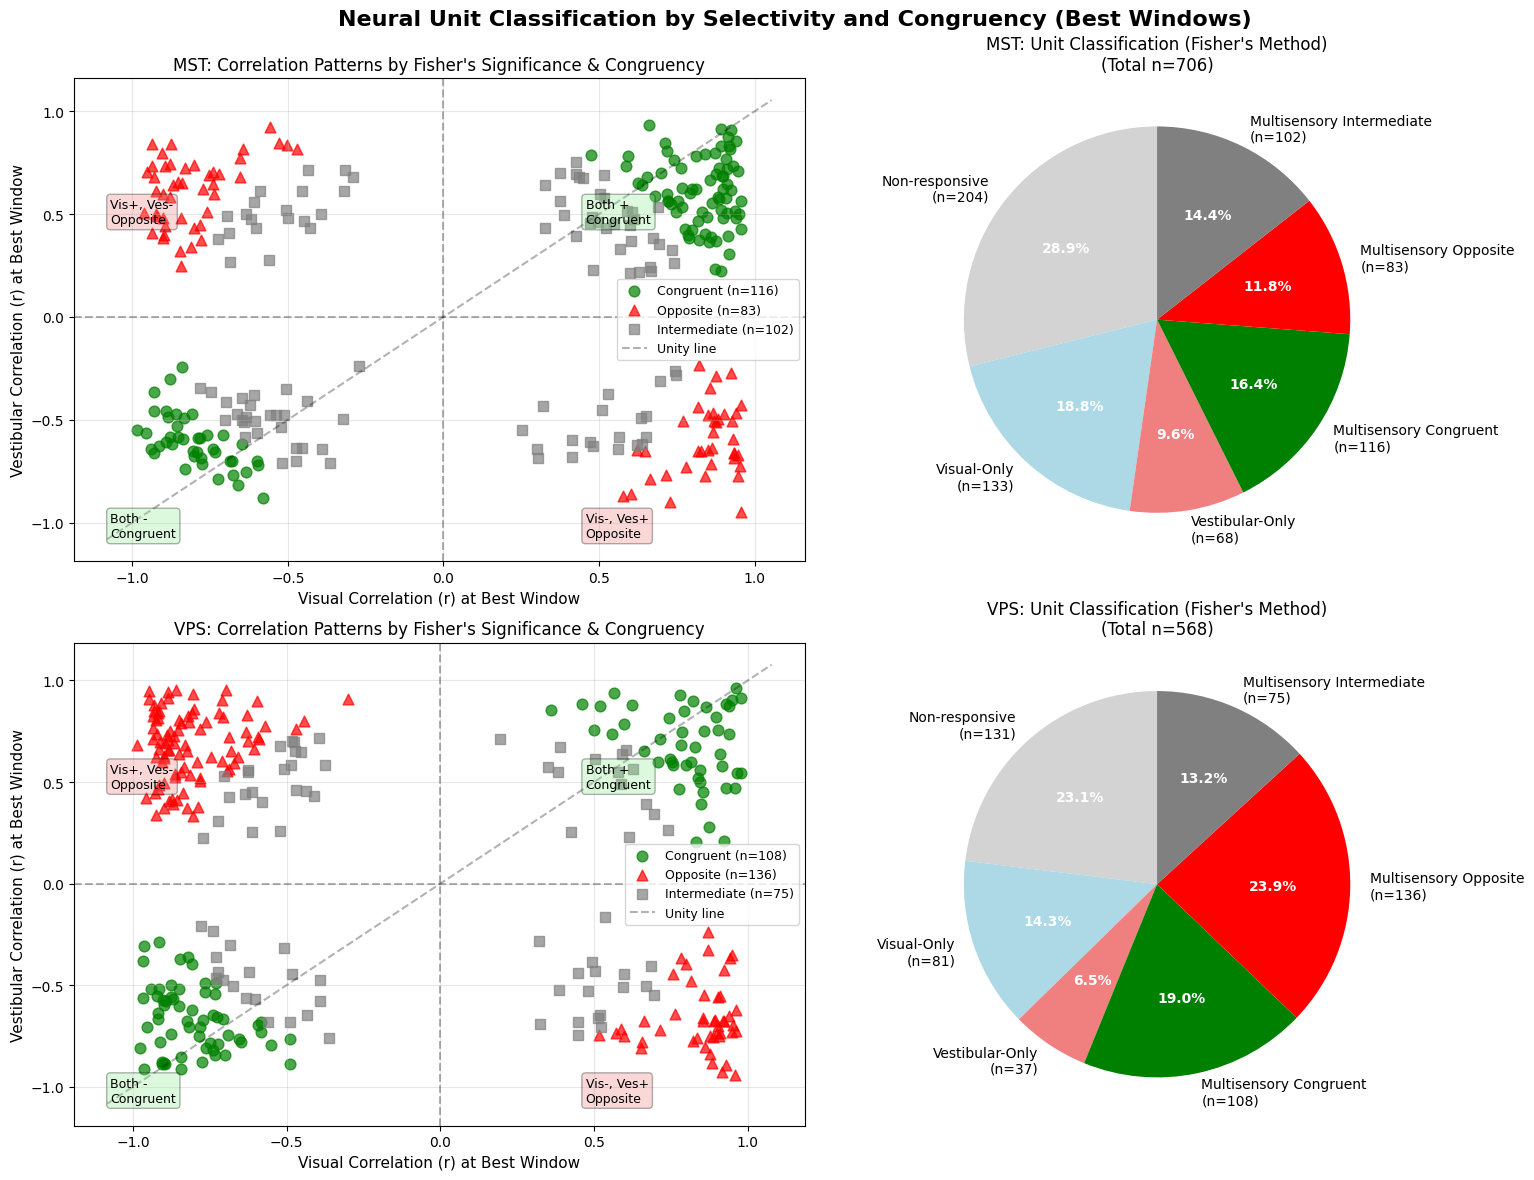


Creating Figure 3 Lower Panel: Congruency Counts Over Time...
Figure 3 Lower Panel saved as 'figure3_congruency_counts_temporal_corrected.png'


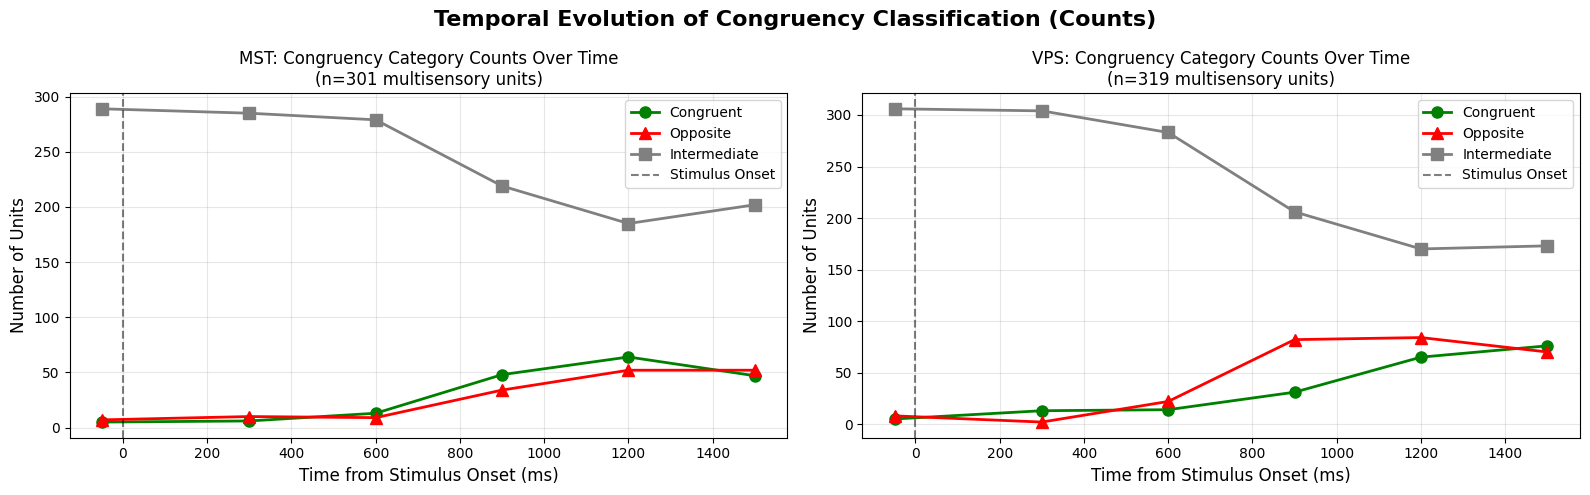


COMPARISON: Simple vs Congruency Classification

Simple Categorization (matches 3D plot):
  Non-responsive      :  383 ( 28.3%)
  Visual-Only         :  219 ( 16.2%)
  Vestibular-Only     :  114 (  8.4%)
  Combined            :  637 ( 47.1%)

Congruency Classification (Fisher's method on Combined units):
  Non-responsive                :  383 ( 28.3%)
  Visual-Only                   :  219 ( 16.2%)
  Vestibular-Only               :  114 (  8.4%)
  Multisensory Congruent        :  227 ( 16.8%)
  Multisensory Opposite         :  223 ( 16.5%)
  Multisensory Intermediate     :  187 ( 13.8%)

Analysis complete!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import chi2
import seaborn as sns
import ast
import json
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: DATA LOADING & PREPROCESSING
# ============================================================================

def parse_list_column(value):
    """Parse string representation of list to actual list"""
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    if value is None:
        return []
    try:
        if pd.isna(value):
            return []
    except (ValueError, TypeError):
        pass
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except:
            try:
                return json.loads(value)
            except:
                return []
    return []

def extract_value_at_best_window(row, metric_prefix, modality):
    """Extract metric value at best center time for given modality"""
    try:
        best_center = row[f'{metric_prefix}_{modality}_best_center_ms']
        if pd.isna(best_center):
            return np.nan
        
        centers = parse_list_column(row[f'{metric_prefix}_{modality}_centers'])
        values = parse_list_column(row[f'{metric_prefix}_{modality}_r' if metric_prefix == 'correlation' else 
                                       f'{metric_prefix}_{modality}_thresholds' if metric_prefix == 'neurometric' else
                                       f'{metric_prefix}_{modality}_F'])
        
        if len(centers) == 0 or len(values) == 0:
            return np.nan
        
        centers_array = np.array(centers)
        idx = np.argmin(np.abs(centers_array - best_center))
        
        return values[idx] if idx < len(values) else np.nan
    except:
        return np.nan

def is_selective(row, modality, alpha=0.05): 
    """Check if unit is selective for given modality"""
    try:
        p_values = parse_list_column(row[f'anova_{modality}_p'])
        if len(p_values) == 0:
            return False
        return any(not np.isnan(p) and p < alpha for p in p_values)
    except:
        return False

def categorize_simple(row):
    """
    Categorize unit based on selectivity.
    MATCHES YOUR ORIGINAL CODE: Includes comb_selective!
    """
    # CHANGED: Added "or row['comb_selective']" to match your definition
    if (row['vis_selective'] and row['ves_selective']) or row['comb_selective']:
        return 'Combined'
    elif row['vis_selective']:
        return 'Visual-Only'
    elif row['ves_selective']:
        return 'Vestibular-Only'
    else:
        return 'Non-responsive'

def classify_congruency(row):
    """
    Classify congruency using Fisher's method on best-window correlations.
    
    MULTISENSORY DEFINITION (UPDATED):
    A unit is "Multisensory" if:
      - (vis_selective AND ves_selective) OR comb_selective
    
    This includes units selective for the combined modality even if they're 
    not individually selective for vis-only or ves-only.
    """
    threshold = 0.05
    
    # Check if unit is selective for visual and/or vestibular
    vis_selective = row['vis_selective']
    ves_selective = row['ves_selective']
    comb_selective = row['comb_selective']
    
    # CHANGED: Match your original categorization
    is_multisensory = (vis_selective and ves_selective) or comb_selective
    
    if not vis_selective and not ves_selective and not comb_selective:
        return 'Non-responsive'
    
    if vis_selective and not ves_selective and not comb_selective:
        return 'Visual-Only'
    
    if ves_selective and not vis_selective and not comb_selective:
        return 'Vestibular-Only'
    
    # For multisensory units, check congruency
    if is_multisensory:
        vis_corr_r = row['vis_corr_r_best']
        ves_corr_r = row['ves_corr_r_best']
        vis_corr_p = row['vis_corr_p_best']
        ves_corr_p = row['ves_corr_p_best']
        
        # Check if both correlations exist and are valid
        if (pd.notna(vis_corr_p) and pd.notna(ves_corr_p) and 
            pd.notna(vis_corr_r) and pd.notna(ves_corr_r) and
            vis_corr_p > 0 and ves_corr_p > 0):
            
            # Fisher's method: -2 * ln(p1 * p2) follows chi-square with 4 df
            fisher_stat = -2 * (np.log(vis_corr_p) + np.log(ves_corr_p))
            combined_p = 1 - chi2.cdf(fisher_stat, df=4)
            
            # If combined significance is < 0.05
            if combined_p < 0.05:
                vis_positive = vis_corr_r > 0
                ves_positive = ves_corr_r > 0
                
                if vis_positive == ves_positive:
                    return 'Multisensory Congruent'
                else:
                    return 'Multisensory Opposite'
            else:
                return 'Multisensory Intermediate'
        else:
            return 'Multisensory Intermediate'
    
    return 'Other'

# Load the data
df = pd.read_csv(r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv')


print("\nLoading and preprocessing data...")
print(f"Total units loaded: {len(df)}")

# Parse all list columns
list_columns = [col for col in df.columns if any(x in col for x in ['centers', 'thresholds', 'r2', 'mu', 'sigma', '_F', '_p', '_r'])]
for col in list_columns:
    if col.endswith('_best_center_ms') or col == 'overall_firing_rate':
        continue
    df[col] = df[col].apply(parse_list_column)

# Extract best-window values for correlations
print("Extracting best-window correlation values...")
df['vis_corr_r_best'] = df.apply(lambda row: extract_value_at_best_window(row, 'correlation', 'vis'), axis=1)
df['ves_corr_r_best'] = df.apply(lambda row: extract_value_at_best_window(row, 'correlation', 'ves'), axis=1)

# Extract p-values at best windows
def extract_p_at_best_window(row, modality):
    try:
        best_center = row[f'correlation_{modality}_best_center_ms']
        if pd.isna(best_center):
            return np.nan
        centers = row[f'correlation_{modality}_centers']
        p_values = row[f'correlation_{modality}_p']
        if len(centers) == 0 or len(p_values) == 0:
            return np.nan
        centers_array = np.array(centers)
        idx = np.argmin(np.abs(centers_array - best_center))
        return p_values[idx] if idx < len(p_values) else np.nan
    except:
        return np.nan

df['vis_corr_p_best'] = df.apply(lambda row: extract_p_at_best_window(row, 'vis'), axis=1)
df['ves_corr_p_best'] = df.apply(lambda row: extract_p_at_best_window(row, 'ves'), axis=1)

# Apply selectivity criteria (CHANGED: alpha=0.05 to match your code)
print("Applying selectivity criteria (p < 0.05)...")
df['ves_selective'] = df.apply(lambda row: is_selective(row, 'ves', alpha=0.05), axis=1)
df['vis_selective'] = df.apply(lambda row: is_selective(row, 'vis', alpha=0.05), axis=1)
df['comb_selective'] = df.apply(lambda row: is_selective(row, 'comb', alpha=0.05), axis=1)

# Apply simple categorization
df['unit_category_simple'] = df.apply(categorize_simple, axis=1)

# Apply congruency classification
print("Applying congruency classification...")
df['unit_category_congruency'] = df.apply(classify_congruency, axis=1)

# Calculate SCI for analysis
df['SCI'] = df['vis_corr_r_best'] * df['ves_corr_r_best']

print(f"Preprocessing complete!")
print(f"\nSimple categories found:")
for cat, count in df['unit_category_simple'].value_counts().items():
    print(f"  {cat}: {count}")
print(f"\nCongruency categories found:")
for cat, count in df['unit_category_congruency'].value_counts().items():
    print(f"  {cat}: {count}")

# ============================================================================
# FIGURE 1: STATIC ANALYSIS (2x2 SCATTER + PIE)
# ============================================================================

category_colors = {
    'Non-responsive': 'lightgray',
    'Visual-Only': 'lightblue', 
    'Vestibular-Only': 'lightcoral',
    'Combined': 'orange',
    'Multisensory Congruent': 'green',
    'Multisensory Opposite': 'red',
    'Multisensory Intermediate': 'gray',
    'Other': 'darkgray'
}

print("\nCreating Figure 1: Static Analysis...")
fig1, axes = plt.subplots(2, 2, figsize=(16, 12))
fig1.suptitle('Neural Unit Classification by Selectivity and Congruency (Best Windows)', 
              fontsize=16, fontweight='bold')

areas = ['MST', 'VPS']

for i, area in enumerate(areas):
    area_data = df[df['area'] == area]
    
    # SUBPLOT 1: Scatter plot
    ax1 = axes[i, 0]
    
    corr_data = area_data.dropna(subset=['vis_corr_r_best', 'ves_corr_r_best'])
    
    if len(corr_data) > 0:
        for category in ['Multisensory Congruent', 'Multisensory Opposite', 'Multisensory Intermediate']:
            cat_data = corr_data[corr_data['unit_category_congruency'] == category]
            if len(cat_data) > 0:
                marker = 'o' if 'Congruent' in category else ('^' if 'Opposite' in category else 's')
                ax1.scatter(cat_data['vis_corr_r_best'], cat_data['ves_corr_r_best'], 
                           alpha=0.7, s=60, color=category_colors[category], 
                           marker=marker, label=f'{category.replace("Multisensory ", "")} (n={len(cat_data)})')
        
        ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        ax1.axvline(x=0, color='k', linestyle='--', alpha=0.3)
        
        lim_min = min(ax1.get_xlim()[0], ax1.get_ylim()[0])
        lim_max = max(ax1.get_xlim()[1], ax1.get_ylim()[1])
        ax1.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.3, label='Unity line')
        
        ax1.set_xlabel('Visual Correlation (r) at Best Window', fontsize=11)
        ax1.set_ylabel('Vestibular Correlation (r) at Best Window', fontsize=11)
        ax1.set_title(f'{area}: Correlation Patterns by Fisher\'s Significance & Congruency')
        ax1.legend(fontsize=9)
        ax1.grid(True, alpha=0.3)
        
        ax1.text(0.7, 0.7, 'Both +\nCongruent', transform=ax1.transAxes, 
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3), fontsize=9)
        ax1.text(0.05, 0.7, 'Vis+, Ves-\nOpposite', transform=ax1.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3), fontsize=9)
        ax1.text(0.7, 0.05, 'Vis-, Ves+\nOpposite', transform=ax1.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3), fontsize=9)
        ax1.text(0.05, 0.05, 'Both -\nCongruent', transform=ax1.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3), fontsize=9)
    else:
        ax1.text(0.5, 0.5, 'No correlation data available', ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title(f'{area}: Correlation Patterns')
    
    # SUBPLOT 2: Pie chart
    ax2 = axes[i, 1]
    
    category_counts = area_data['unit_category_congruency'].value_counts()
    
    all_categories = ['Non-responsive', 'Visual-Only', 'Vestibular-Only', 
                     'Multisensory Congruent', 'Multisensory Opposite', 'Multisensory Intermediate']
    
    counts = []
    labels = []
    colors = []
    
    for cat in all_categories:
        count = category_counts.get(cat, 0)
        if count > 0:
            counts.append(count)
            labels.append(f'{cat}\n(n={count})')
            colors.append(category_colors[cat])
    
    if len(counts) > 0:
        wedges, texts, autotexts = ax2.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
                                          startangle=90, textprops={'fontsize': 10})
        
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
    
    ax2.set_title(f'{area}: Unit Classification (Fisher\'s Method)\n(Total n={len(area_data)})')

plt.tight_layout()
plt.savefig('figure1_static_analysis_corrected.png', dpi=300, bbox_inches='tight')
print("Figure 1 saved as 'figure1_static_analysis_corrected.png'")
plt.show()

# ============================================================================
# FIGURE 3 LOWER PANEL: CONGRUENCY COUNTS OVER TIME
# ============================================================================

print("\nCreating Figure 3 Lower Panel: Congruency Counts Over Time...")

fig3, axes = plt.subplots(1, 2, figsize=(16, 5))
fig3.suptitle('Temporal Evolution of Congruency Classification (Counts)', fontsize=16, fontweight='bold')

def classify_congruency_at_window(row, window_idx):
    """Classify congruency at specific time window"""
    try:
        vis_corr_r_list = row['correlation_vis_r']
        ves_corr_r_list = row['correlation_ves_r']
        vis_corr_p_list = row['correlation_vis_p']
        ves_corr_p_list = row['correlation_ves_p']
        
        if (len(vis_corr_r_list) <= window_idx or len(ves_corr_r_list) <= window_idx or
            len(vis_corr_p_list) <= window_idx or len(ves_corr_p_list) <= window_idx):
            return 'Insufficient Data'
        
        vis_corr_r = vis_corr_r_list[window_idx]
        ves_corr_r = ves_corr_r_list[window_idx]
        vis_corr_p = vis_corr_p_list[window_idx]
        ves_corr_p = ves_corr_p_list[window_idx]
        
        if (pd.notna(vis_corr_p) and pd.notna(ves_corr_p) and 
            pd.notna(vis_corr_r) and pd.notna(ves_corr_r) and
            vis_corr_p > 0 and ves_corr_p > 0):
            
            fisher_stat = -2 * (np.log(vis_corr_p) + np.log(ves_corr_p))
            combined_p = 1 - chi2.cdf(fisher_stat, df=4)
            
            if combined_p < 0.05:
                vis_positive = vis_corr_r > 0
                ves_positive = ves_corr_r > 0
                
                if vis_positive == ves_positive:
                    return 'Congruent'
                else:
                    return 'Opposite'
            else:
                return 'Intermediate'
        else:
            return 'Insufficient Data'
    except:
        return 'Insufficient Data'

for col_idx, area in enumerate(areas):
    area_data = df[df['area'] == area]
    
    # CHANGED: Use updated definition of multisensory
    multisensory_data = area_data[area_data['unit_category_simple'] == 'Combined']
    
    if len(multisensory_data) == 0:
        axes[col_idx].text(0.5, 0.5, f'No multisensory units in {area}', 
                          ha='center', va='center', transform=axes[col_idx].transAxes)
        continue
    
    sample_row = multisensory_data.iloc[0]
    time_windows = sample_row['correlation_vis_centers']
    
    if len(time_windows) == 0:
        continue
    
    ax = axes[col_idx]
    
    congruent_counts = []
    opposite_counts = []
    intermediate_counts = []
    
    for window_idx in range(len(time_windows)):
        congruent_count = 0
        opposite_count = 0
        intermediate_count = 0
        
        for idx, row in multisensory_data.iterrows():
            classification = classify_congruency_at_window(row, window_idx)
            if classification == 'Congruent':
                congruent_count += 1
            elif classification == 'Opposite':
                opposite_count += 1
            elif classification == 'Intermediate':
                intermediate_count += 1
        
        congruent_counts.append(congruent_count)
        opposite_counts.append(opposite_count)
        intermediate_counts.append(intermediate_count)
    
    ax.plot(time_windows, congruent_counts, color=category_colors['Multisensory Congruent'], 
            marker='o', linewidth=2, markersize=8, label='Congruent')
    ax.plot(time_windows, opposite_counts, color=category_colors['Multisensory Opposite'], 
            marker='^', linewidth=2, markersize=8, label='Opposite')
    ax.plot(time_windows, intermediate_counts, color=category_colors['Multisensory Intermediate'], 
            marker='s', linewidth=2, markersize=8, label='Intermediate')
    
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5, label='Stimulus Onset')
    ax.set_xlabel('Time from Stimulus Onset (ms)', fontsize=12)
    ax.set_ylabel('Number of Units', fontsize=12)
    ax.set_title(f'{area}: Congruency Category Counts Over Time\n(n={len(multisensory_data)} multisensory units)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('figure3_congruency_counts_temporal_corrected.png', dpi=300, bbox_inches='tight')
print("Figure 3 Lower Panel saved as 'figure3_congruency_counts_temporal_corrected.png'")
plt.show()

# ============================================================================
# STATISTICS
# ============================================================================

print("\n" + "="*80)
print("COMPARISON: Simple vs Congruency Classification")
print("="*80)

print("\nSimple Categorization (matches 3D plot):")
for cat in ['Non-responsive', 'Visual-Only', 'Vestibular-Only', 'Combined']:
    count = len(df[df['unit_category_simple'] == cat])
    pct = 100 * count / len(df)
    print(f"  {cat:20s}: {count:4d} ({pct:5.1f}%)")

print("\nCongruency Classification (Fisher's method on Combined units):")
for cat in ['Non-responsive', 'Visual-Only', 'Vestibular-Only', 
            'Multisensory Congruent', 'Multisensory Opposite', 'Multisensory Intermediate']:
    count = len(df[df['unit_category_congruency'] == cat])
    pct = 100 * count / len(df)
    print(f"  {cat:30s}: {count:4d} ({pct:5.1f}%)")

print("\n" + "="*80)
print("Analysis complete!")
print("="*80)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import chi2
import seaborn as sns

# Load the data
df = pd.read_csv(r'D:\Neural-Pipeline\results\analysis_single_neurons\dots3DMPtuning_neuralfeatures\zarya_pooled_neural_features_tuning_stimOn.csv')

# First, let's check what columns are available
print("Available columns in the dataset:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nDataset shape:", df.shape)
print("\nColumn data types:")
print(df.dtypes)

Available columns in the dataset:
['unit_id', 'subject', 'date', 'alignment', 'is_tuning', 'is_tuning_RT', 'unit_idx', 'area', 'absolute_x', 'absolute_y', 'relative_x', 'relative_y', 'absolute_depth', 'relative_depth', 'neurometric_ves_centers', 'neurometric_ves_thresholds', 'neurometric_ves_r2', 'neurometric_ves_mu', 'neurometric_ves_sigma', 'neurometric_ves_best_center_ms', 'anova_ves_centers', 'anova_ves_F', 'anova_ves_p', 'anova_ves_best_center_ms', 'correlation_ves_centers', 'correlation_ves_r', 'correlation_ves_p', 'correlation_ves_best_center_ms', 'neurometric_vis_centers', 'neurometric_vis_thresholds', 'neurometric_vis_r2', 'neurometric_vis_mu', 'neurometric_vis_sigma', 'neurometric_vis_best_center_ms', 'anova_vis_centers', 'anova_vis_F', 'anova_vis_p', 'anova_vis_best_center_ms', 'correlation_vis_centers', 'correlation_vis_r', 'correlation_vis_p', 'correlation_vis_best_center_ms', 'neurometric_comb_centers', 'neurometric_comb_thresholds', 'neurometric_comb_r2', 'neurometric_co